#### NOTE: Please make sure to view the images, the notebook is in the same folder as the images as they use the local path of the image to render in the discussion part.

# Part I: From VGG to ResNet [30 pts]
Implement and compare VGG-16 (Version C) and ResNet-18 for image classification. Explore advanced techniques to improve model performance and the transition from standard deep CNNs to networks with residual connections.
The expected accuracy is above 75% for the base model and 80% for the improved model.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,confusion_matrix
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import glob
import random
import matplotlib.image as mpimg
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [2]:
seed = 42
torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
random.seed(seed)
# np.random.seed(seed)

print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


## Step 1: Data preparation

1. Load CNN dataset.

In [3]:
import zipfile
import os

# Path to the zip file
zip_path = '../Downloads/cnn_dataset.zip'
extract_dir = '../Downloads/cnn_dataset'  # Extract the dataset here

# # Extract the zip file
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)


In [5]:

#transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

#Loading the dataset
dataset_dir = "/kaggle/input/cnn-dataset" #extract_dir #'../Downloads/cnn_dataset.zip'
full_ds = datasets.ImageFolder(root=dataset_dir, transform=transform)
class_names = full_ds.classes

batch_size = 32
data_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=True)

print("Classes found:", class_names)
print("Total number of images in dataset:", len(full_ds))

Classes found: ['dogs', 'food', 'vehicles']
Total number of images in dataset: 30000


Analyze the dataset.

Classes found: ['vehicles', 'dogs', 'food']
Number of images in 'vehicles': 10000
Number of images in 'dogs': 10000
Number of images in 'food': 10000
Total number of images in the dataset: 90000


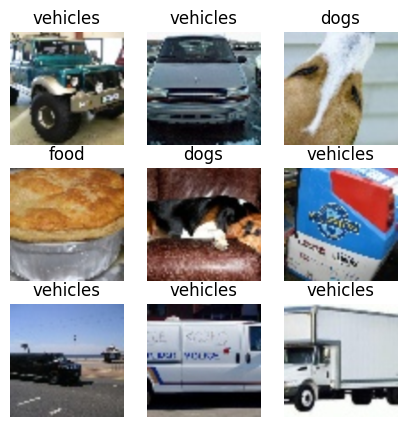

In [6]:
### ADD YOUR CODE HERE ###
#Since we need to analyze the datset

# firstly, the classes in our the dataset
classes = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
print("Classes found:", classes)

#now the number of images in each of those
for class_name in classes:
    image_paths = glob.glob(os.path.join(dataset_dir, class_name, '*'))
    print(f"Number of images in '{class_name}':", len(image_paths))

#total number of images in our dataset
dataset_count = sum([images.shape[0] for images, _ in full_ds])
print("Total number of images in the dataset:", dataset_count)

#got batch of images
data_iter = iter(data_loader)
images, labels = next(data_iter)

#sample
plt.figure(figsize=(5, 5))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))  # Convert from Tensor format
    plt.title(class_names[labels[i].item()])
    plt.axis("off")
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

The dataset used here has three disctinct classes that has images of Dogs, Food and Vechicles. The data set has images that are taken indifferenet angles, lighting and setups. Each class has 10,000 images, making it a total image count of 30000.

2.	Create at least three different visualizations to explore the dataset. Provide a short description explaining what each visualization shows.

<span style='color:green'>### YOUR ANSWER ###</span>

The three differenet visualizations we used to explore the dataset are:
- Bar chart to display the count of images and see if there is any imbalance
- Sample grid of image from each class
- Histogram to show the avaerage image brightness of each class.

### Bar Chart

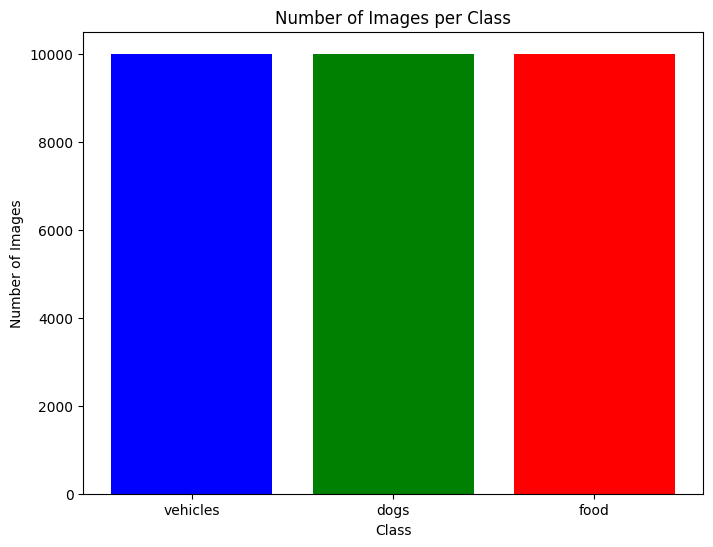

In [7]:
#counting the images in each class
image_counts = {}
for class_name in classes:
    image_paths = glob.glob(os.path.join(dataset_dir, class_name, '*'))
    image_counts[class_name] = len(image_paths)

#plot
plt.figure(figsize=(8,6))
plt.bar(image_counts.keys(), image_counts.values(), color=['blue', 'green', 'red'])
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In this barchart we can see the number of images available in each class (dogs, food, vehicles) is uniform

### Grid of Sample Images from Each Class

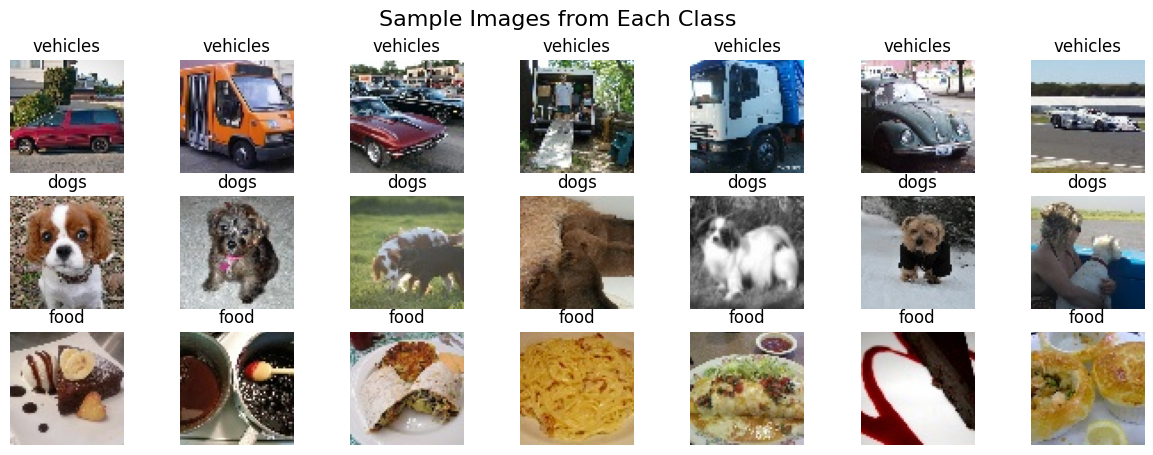

In [8]:

plt.figure(figsize=(15, 5))
num_samples = 7

for i, class_name in enumerate(classes):
    image_paths = glob.glob(os.path.join(dataset_dir, class_name, '*'))
    sample_paths = random.sample(image_paths, min(num_samples, len(image_paths)))
    for j, img_path in enumerate(sample_paths):
        plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.show()

Used this grid to display a few random images from each class, so that we can see what kind of images are present in each category.

### Histogram

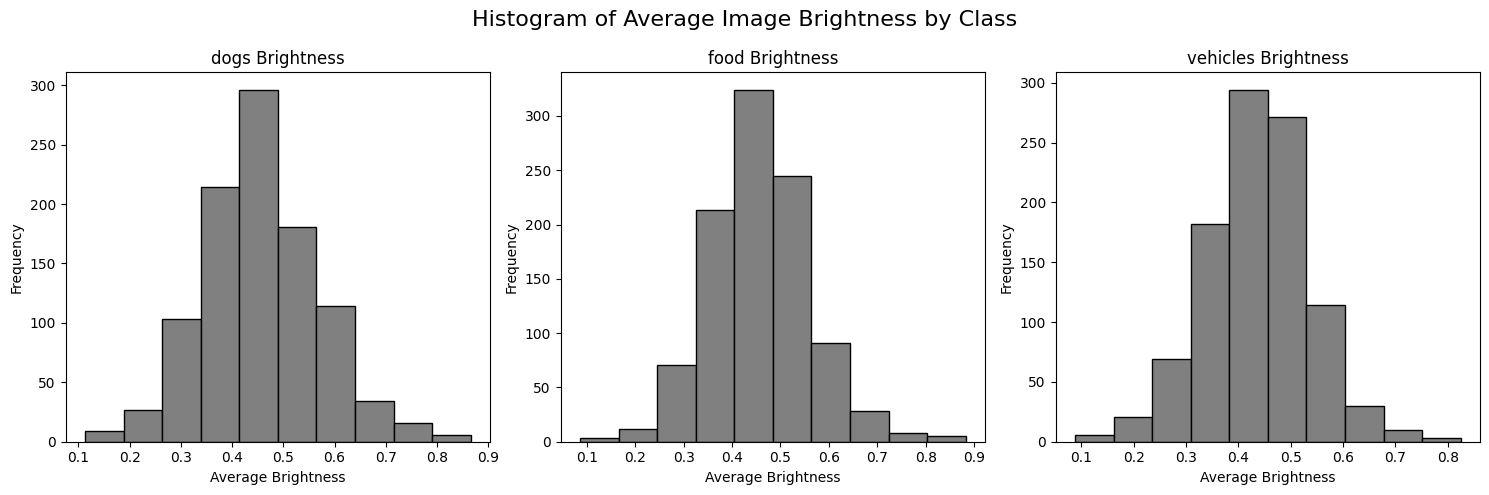

In [9]:

plt.figure(figsize=(15, 5))
num_samples = 1000  #only took 1000 for sample

for i, class_name in enumerate(class_names):
    image_paths = glob.glob(os.path.join(dataset_dir, class_name, '*'))
    sample_paths = random.sample(image_paths, min(num_samples, len(image_paths)))
    brightness_values = []

    for img_path in sample_paths:
        img = Image.open(img_path).convert("RGB")
        img = np.array(img) / 255.0  # Convert to numpy and normalize to [0,1]

        #average brightness
        brightness = np.mean(img)
        brightness_values.append(brightness)

    #plot
    plt.subplot(1, len(class_names), i + 1)
    plt.hist(brightness_values, bins=10, color='gray', edgecolor='black')
    plt.title(f"{class_name} Brightness")
    plt.xlabel("Average Brightness")
    plt.ylabel("Frequency")

plt.suptitle("Histogram of Average Image Brightness by Class", fontsize=16)
plt.tight_layout()
plt.show()

Using this visualization we compute the average brightness (that is mean pixel intensity) for a sample of images from each class and plotted histograms for them. It compares the overall lighting or contrast characteristics among classes. We can see that .45 has the highest frequency in all of them.

3. Preprocess the dataset.

Preprocessing with resizing completed.


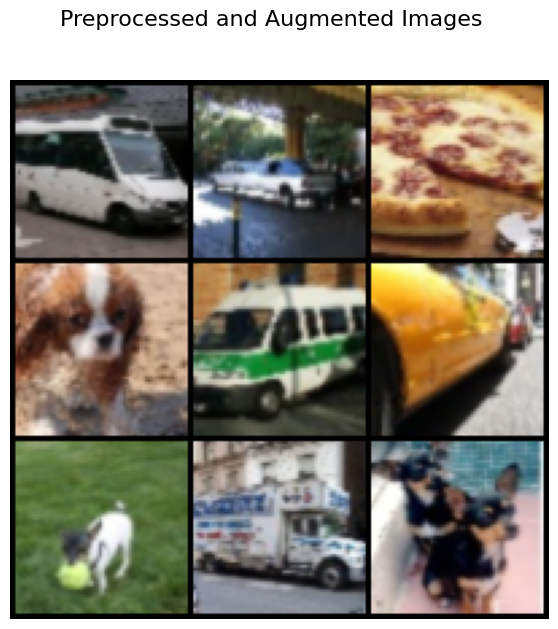

In [10]:

#defining the data augmentation and preprocessing transforms we will be using, resized to 64*64 for smoother processing
data_augmentation = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize to 64x64
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(10),
    transforms.RandomResizedCrop(64, scale=(0.9, 1.0)),
    transforms.ToTensor(),
])

#preprocessing function
def preprocess(image, label):
    # Convert Tensor to PIL Image
    image = transforms.ToPILImage()(image)
    image = data_augmentation(image)
    return image, label

#transformations
augmented_ds = [(preprocess(image, label)) for image, label in full_ds]

#creating DataLoader
augmented_loader = DataLoader(augmented_ds, batch_size=32, shuffle=True)

print("Preprocessing with resizing completed.")

#visualizing a batch here
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

data_iter = iter(augmented_loader)
images, labels = next(data_iter)

plt.figure(figsize=(7, 7))
grid_img = make_grid(images[:9], nrow=3).permute(1, 2, 0)
plt.imshow(grid_img.numpy())
plt.axis("off")
plt.suptitle("Preprocessed and Augmented Images", fontsize=16)
plt.show()

4. Split the dataset into training, testing, and validation sets.

In [11]:
### ADD YOUR CODE HERE ###

#ds size
dataset_count = len(augmented_ds)
print("Total number of images:", dataset_count)

#spliting in 7:1.5:1.5
train_size = int(0.7 * dataset_count)
val_size = int(0.15 * dataset_count)
test_size = dataset_count - train_size - val_size

print("Training examples:", train_size)
print("Validation examples:", val_size)
print("Testing examples:", test_size)

#spliting the dataset
train_ds, val_ds, test_ds = random_split(augmented_ds, [train_size, val_size, test_size])

#batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Total number of images: 30000
Training examples: 21000
Validation examples: 4500
Testing examples: 4500


## Step 2: Implementing VGG

1. Implement the VGG-16 (Version C) architecture.

In [12]:
### ADD YOUR CODE HERE ###
class VGG_CNN_Model(nn.Module):
  def __init__(self):
    super(VGG_CNN_Model, self).__init__()

    # Block 1 layers
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 2 layers
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 3 layers
    self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.conv7 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 4 layers
    self.conv8 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
    self.conv9 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 5 layers
    self.conv11 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.conv12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.conv13 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

    #FC layers
    self.fc1 = nn.Linear(512 * 4 * 4, 4096)   # for input 64x64
    self.fc2 = nn.Linear(4096, 4096)
    self.fc3 = nn.Linear(4096, 3)  # 3 is the number of classes

    # dropout as used in VGG model for regularization
    self.dropout = nn.Dropout(p=0.5)

  def forward(self, x):
    #Block 1
    x = nn.ReLU()(self.conv1(x))
    x = self.pool1(nn.ReLU()(self.conv2(x)))

    #Block 2
    x = nn.ReLU()(self.conv3(x))
    x = self.pool2(nn.ReLU()(self.conv4(x)))

    #Block 3
    x = nn.ReLU()(self.conv5(x))
    x = nn.ReLU()(self.conv6(x))
    x = self.pool3(nn.ReLU()(self.conv7(x)))

    #Block 4
    x = nn.ReLU()(self.conv8(x))
    x = nn.ReLU()(self.conv9(x))
    x = self.pool4(nn.ReLU()(self.conv10(x)))

    #Block 5
    x = nn.ReLU()(self.conv11(x))
    x = nn.ReLU()(self.conv12(x))
    x = nn.ReLU()(self.conv13(x))

    x = x.view(-1, 512 * 4 *4)

    #adding the dropout for the fc layers as in VGG paper
    x = self.dropout(nn.ReLU()(self.fc1(x)))
    x = self.dropout(nn.ReLU()(self.fc2(x)))
    x = self.fc3(x)

    return x

model = VGG_CNN_Model().to(device)
print(model)

VGG_CNN_Model(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv7): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv8): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv9): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv10): Conv2d(512

2. Use dropout and learning rate scheduler. Experiment with weight initialization strategies.

In [13]:
### ADD YOUR CODE HERE ###
def model_weight_intialization(model, init_method):
  for layer in model.modules():
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
      if init_method == 'xavier':
        nn.init.xavier_normal_(layer.weight)
        if layer.bias is not None:
          nn.init.zeros_(layer.bias)

      elif init_method == 'he':
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        if layer.bias is not None:
          nn.init.zeros_(layer.bias)



In [ ]:
model_weight_intialization(model,'xavier')

#same setup as mentioned in VGG paper
optimizer_sgd = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler_step_lr = torch.optim.lr_scheduler.StepLR(optimizer_sgd, step_size=5, gamma=0.1) #reduce by factor 10

loss_function_sgd = nn.CrossEntropyLoss()

3. Train your VGG-16 model.

Optimizer #1: SGD with Xavier intialization: \\
This setup uses Xavier weight intialization, StepLR for the learning rate scheduler since it reduces the learning rate by fixed steps and a constant factor. Leads to more stable convergence as the training progresses. Intially it will take larger steps to be able to explore the parameters more and as it convergences then it makes smaller updates.\\
Our training and validation performance below will indicate this.

In [ ]:
### ADD YOUR CODE HERE ###
# training using SGD Optimizer (used code from a0_part3_ra65)

epochs = 30

best_validation_loss_sgd = float('inf')
best_epoch_sgd = 0
train_loss_sgd = []
validation_loss_sgd = []
train_accuracy_sgd = []
validation_accuracy_sgd = []

for epoch in range(epochs):
  model.train()

  start_time = time.time()

  loop_train_loss_sgd = 0
  correct_train_length_sgd = 0
  total_train_sgd = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_sgd.zero_grad()

    outputs = model(inputs)

    loss = loss_function_sgd(outputs, labels)
    loss.backward()
    optimizer_sgd.step()

    _, predicted_sgd = torch.max(outputs, 1)
    total_train_sgd += labels.size(0)
    correct_train_length_sgd += (predicted_sgd == labels).sum().item()

    loop_train_loss_sgd += loss.item()

  scheduler_step_lr.step() #learning rate scheduler

  #training accuracy and loss
  train_accuracy_value_sgd = 100 * correct_train_length_sgd / total_train_sgd
  train_loss_sgd.append(loop_train_loss_sgd / len(train_loader))
  train_accuracy_sgd.append(train_accuracy_value_sgd)

  #Validation
  model.eval()
  loop_val_loss_sgd = 0
  correct_val_sgd = 0
  total_val_sgd = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_sgd(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_sgd = torch.max(val_outputs, 1)

      total_val_sgd += val_labels.size(0)
      correct_val_sgd += (predicted_sgd == val_labels).sum().item()

      loop_val_loss_sgd += val_loss.item()

  #validation accuracy and loss
  val_accuracy_sgd = 100 * correct_val_sgd / total_val_sgd
  validation_loss_sgd.append(loop_val_loss_sgd / len(val_loader))
  validation_accuracy_sgd.append(val_accuracy_sgd)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_sgd[-1]:.4f}, Train Accuracy: {train_accuracy_sgd[-1]:.2f}%, "
    f"Val Loss: {validation_loss_sgd[-1]:.4f}, Val Accuracy: {validation_accuracy_sgd[-1]:.2f}%")

  end_time = time.time()
  training_time_sgd = end_time - start_time
  print(f"Training Time: {training_time_sgd:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_sgd < best_validation_loss_sgd:
    best_validation_loss_sgd = loop_val_loss_sgd
    best_epoch_sgd = epoch + 1
    best_model_weight_sgd = model.state_dict()


if best_model_weight_sgd is not None:
  torch.save(best_model_weight_sgd, 'vgg_model_sgd_xavier.pt')


Epoch [1/30], Train Loss: 0.9861, Train Accuracy: 47.22%, Val Loss: 0.9808, Val Accuracy: 51.24%
Training Time: 26.27 seconds
Epoch [2/30], Train Loss: 0.6350, Train Accuracy: 73.61%, Val Loss: 0.5168, Val Accuracy: 79.89%
Training Time: 17.38 seconds
Epoch [3/30], Train Loss: 0.4976, Train Accuracy: 80.09%, Val Loss: 0.4502, Val Accuracy: 82.62%
Training Time: 17.38 seconds
Epoch [4/30], Train Loss: 0.4620, Train Accuracy: 81.75%, Val Loss: 0.4469, Val Accuracy: 83.78%
Training Time: 17.38 seconds
Epoch [5/30], Train Loss: 0.4138, Train Accuracy: 83.62%, Val Loss: 0.3696, Val Accuracy: 86.02%
Training Time: 17.25 seconds
Epoch [6/30], Train Loss: 0.3061, Train Accuracy: 88.10%, Val Loss: 0.3218, Val Accuracy: 87.93%
Training Time: 17.49 seconds
Epoch [7/30], Train Loss: 0.2901, Train Accuracy: 88.90%, Val Loss: 0.3218, Val Accuracy: 87.47%
Training Time: 17.36 seconds
Epoch [8/30], Train Loss: 0.2787, Train Accuracy: 89.26%, Val Loss: 0.3070, Val Accuracy: 88.93%
Training Time: 17.51 

In [ ]:
# Test phase
model.eval()
correct_test_length_sgd = 0
total_test_sgd = 0
y_true_sgd = []
y_pred_sgd = []

# test_loss = []
test_accuracy_sgd =[]
test_total_loss_sgd = 0.0
predicted_list_sgd = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)

    labels = labels.view(-1)
    test_total_loss_sgd += loss_function_sgd(outputs, labels).item()

    _, predicted_sgd = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_sgd += labels.size(0)
    correct_test_length_sgd += (predicted_sgd == labels).sum().item()

    y_true_sgd.extend(labels.cpu().numpy())
    y_pred_sgd.extend(predicted_sgd.cpu().numpy())
    predicted_list_sgd.extend(predicted_test_probs.cpu().numpy())


y_pred_sgd = np.array(y_pred_sgd)
y_true_sgd = np.array(y_true_sgd)
predicted_list_sgd = np.array(predicted_list_sgd)

test_accuracy_sgd = 100 * (correct_test_length_sgd / total_test_sgd)
print(f"Test Accuracy: {test_accuracy_sgd:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_sgd, y_pred_sgd, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_sgd = test_total_loss_sgd /len(test_loader)

test_accuracies_plot_sgd = [test_accuracy_sgd] * epochs
test_loss_plot_sgd = [test_loss_sgd] * epochs

Test Accuracy: 89.84%
Precision: 0.8988, Recall: 0.8984, F1: 0.8985


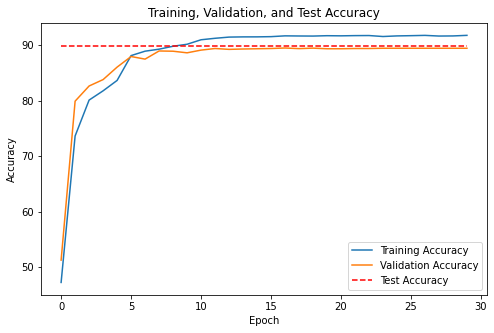

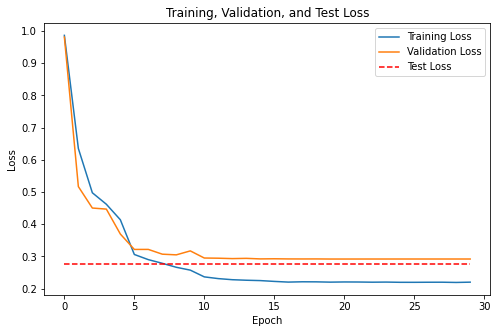

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_sgd, label='Training Accuracy')
plt.plot(validation_accuracy_sgd, label='Validation Accuracy')
plt.plot(test_accuracies_plot_sgd, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_sgd, label='Training Loss')
plt.plot(validation_loss_sgd, label='Validation Loss')
plt.plot(test_loss_plot_sgd, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

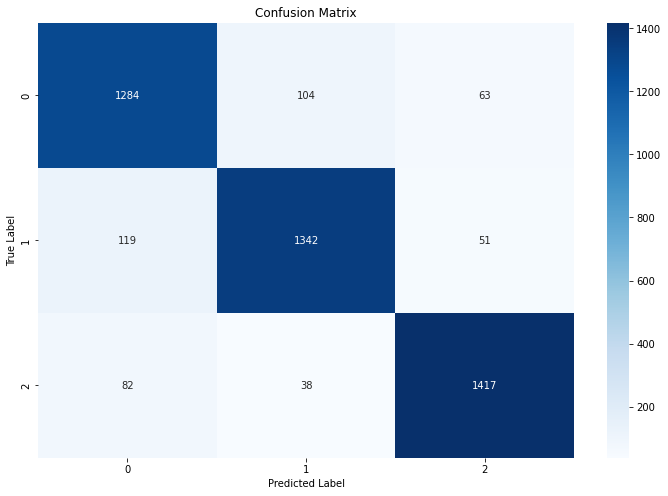

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_sgd, y_pred_sgd)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Using 'he' weight intialization with SGD: \\
This setup uses the same scheduler and optimizer and we chnage the weight intialization to he. \\
As the performance indicates below the model performed better when we changed the weight initialization to he.

In [ ]:
model_sgd_he = VGG_CNN_Model().to(device)
model_weight_intialization(model_sgd_he,'he')

optimizer_sgd_he= torch.optim.SGD(model_sgd_he.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_step_lr_sgd_he = torch.optim.lr_scheduler.StepLR(optimizer_sgd_he, step_size=5, gamma=0.1)
loss_function_sgd_he = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss_sgd_he = float('inf')
best_epoch_sgd_he = 0
train_loss_sgd_he = []
validation_loss_sgd_he = []
train_accuracy_sgd_he = []
validation_accuracy_sgd_he = []

for epoch in range(epochs):
  model_sgd_he.train()

  start_time = time.time()

  loop_train_loss_sgd_he = 0
  correct_train_length_sgd_he = 0
  total_train_sgd_he = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_sgd_he.zero_grad()

    outputs = model_sgd_he(inputs)

    loss = loss_function_sgd_he(outputs, labels)
    loss.backward()
    optimizer_sgd_he.step()

    _, predicted_sgd_he = torch.max(outputs, 1)
    total_train_sgd_he += labels.size(0)
    correct_train_length_sgd_he += (predicted_sgd_he == labels).sum().item()

    loop_train_loss_sgd_he += loss.item()

  scheduler_step_lr_sgd_he.step()

  #training accuracy and loss
  train_accuracy_value_sgd_he = 100 * correct_train_length_sgd_he / total_train_sgd_he
  train_loss_sgd_he.append(loop_train_loss_sgd_he / len(train_loader))
  train_accuracy_sgd_he.append(train_accuracy_value_sgd_he)

  #Validation
  model_sgd_he.eval()
  loop_val_loss_sgd_he = 0
  correct_val_sgd_he = 0
  total_val_sgd_he = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_sgd_he(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_sgd_he(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_sgd_he = torch.max(val_outputs, 1)

      total_val_sgd_he += val_labels.size(0)
      correct_val_sgd_he += (predicted_sgd_he == val_labels).sum().item()

      loop_val_loss_sgd_he += val_loss.item()

  #validation accuracy and loss
  val_accuracy_sgd_he = 100 * correct_val_sgd_he / total_val_sgd_he
  validation_loss_sgd_he.append(loop_val_loss_sgd_he / len(val_loader))
  validation_accuracy_sgd_he.append(val_accuracy_sgd_he)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_sgd_he[-1]:.4f}, Train Accuracy: {train_accuracy_sgd_he[-1]:.2f}%, "
    f"Val Loss: {validation_loss_sgd_he[-1]:.4f}, Val Accuracy: {validation_accuracy_sgd_he[-1]:.2f}%")

  end_time = time.time()
  training_time_sgd_he = end_time - start_time
  print(f"Training Time epoch {epoch+1}: {training_time_sgd_he:.2f} seconds")

  #Save model weights with best validation accuracy
  if loop_val_loss_sgd_he < best_validation_loss_sgd_he:
    best_validation_loss_sgd_he = loop_val_loss_sgd_he
    best_epoch_sgd_he = epoch + 1
    best_model_weight_sgd_he = model_sgd_he.state_dict()


if best_model_weight_sgd_he is not None:
  torch.save(best_model_weight_sgd_he, 'vgg_model_sgd_he.pt')
  # print(f"Best model weights saved to {save_path} from epoch {best_epoch}")


# Test phase
model_sgd_he.eval()
correct_test_length_sgd_he = 0
total_test_sgd_he = 0
y_true_sgd_he = []
y_pred_sgd_he = []

# test_loss = []
test_accuracy_sgd_he =[]
test_total_loss_sgd_he = 0.0
predicted_list_sgd_he = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_sgd_he(inputs)

    labels = labels.view(-1)
    test_total_loss_sgd_he += loss_function_sgd_he(outputs, labels).item()

    _, predicted_sgd_he = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_sgd_he += labels.size(0)
    correct_test_length_sgd_he += (predicted_sgd_he == labels).sum().item()

    y_true_sgd_he.extend(labels.cpu().numpy())
    y_pred_sgd_he.extend(predicted_sgd_he.cpu().numpy())
    predicted_list_sgd_he.extend(predicted_test_probs.cpu().numpy())


y_pred_sgd_he = np.array(y_pred_sgd_he)
y_true_sgd_he = np.array(y_true_sgd_he)
predicted_list_sgd_he = np.array(predicted_list_sgd_he)

test_accuracy_sgd_he = 100 * (correct_test_length_sgd_he / total_test_sgd_he)
print(f"Test Accuracy: {test_accuracy_sgd_he:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_sgd_he, y_pred_sgd_he, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_sgd_he = test_total_loss_sgd_he /len(test_loader)

test_accuracies_plot_sgd_he = [test_accuracy_sgd_he] * epochs
test_loss_plot_sgd_he = [test_loss_sgd_he] * epochs


/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/MPI/gcc/11.2.0/openmpi/4.1.1/pytorch/1.13.1-CUDA-11.8.0/lib/python3.9/site-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch [1/30], Train Loss: 0.8698, Train Accuracy: 56.89%, Val Loss: 0.8183, Val Accuracy: 66.33%
Training Time epoch 1: 17.39 seconds
Epoch [2/30], Train Loss: 0.5340, Train Accuracy: 78.26%, Val Loss: 0.4747, Val Accuracy: 80.67%
Training Time epoch 2: 17.58 seconds
Epoch [3/30], Train Loss: 0.4616, Train Accuracy: 81.80%, Val Loss: 0.4216, Val Accuracy: 83.84%
Training Time epoch 3: 17.51 seconds
Epoch [4/30], Train Loss: 0.4167, Train Accuracy: 83.88%, Val Loss: 0.3859, Val Accuracy: 85.58%
Training Time epoch 4: 17.67 seconds
Epoch [5/30], Train Loss: 0.3703, Train Accuracy: 85.62%, Val Loss: 0.4730, Val Accuracy: 82.33%
Training Time epoch 5: 17.40 seconds
Epoch [6/30], Train Loss: 0.2630, Train Accuracy: 89.98%, Val Loss: 0.2786, Val Accuracy: 89.89%
Training Time epoch 6: 17.55 seconds
Epoch [7/30], Train Loss: 0.2320, Train Accuracy: 91.25%, Val Loss: 0.2856, Val Accuracy: 89.40%
Training Time epoch 7: 17.56 seconds
Epoch [8/30], Train Loss: 0.2183, Train Accuracy: 91.90%, Val 

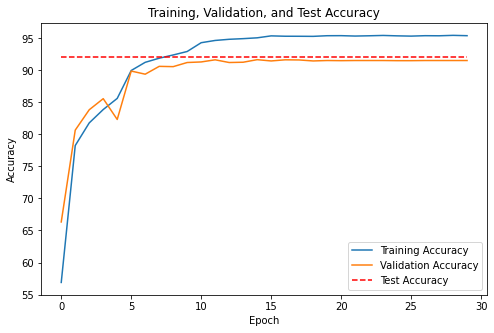

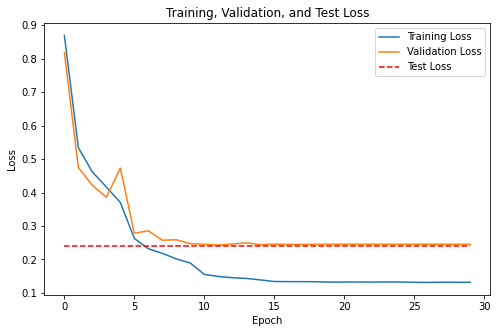

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_sgd_he, label='Training Accuracy')
plt.plot(validation_accuracy_sgd_he, label='Validation Accuracy')
plt.plot(test_accuracies_plot_sgd_he, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_sgd_he, label='Training Loss')
plt.plot(validation_loss_sgd_he, label='Validation Loss')
plt.plot(test_loss_plot_sgd_he, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

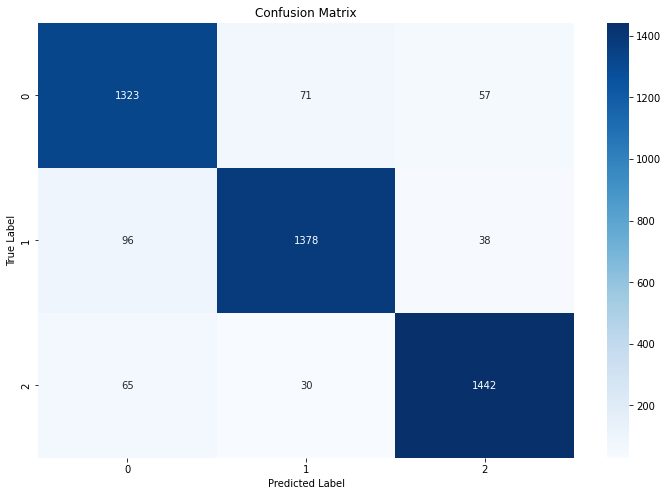

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_sgd_he, y_pred_sgd_he)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Optimizer #2: Adam with Xavier weight intialization: \\
For this setup we change the optimizer to Adam and go back to Xavier weight initialization. \\
However in this setup the model does not perform as well as the other models. Now few reasons here could be the small value for learning rate and the weight decay value used. The two small values is making it an a difficult setup for the model to learn and generalize.

In [ ]:
model_adam = VGG_CNN_Model().to(device)
model_weight_intialization(model_adam,'xavier')
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_adam = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=5, gamma=0.1)
loss_function_adam = nn.CrossEntropyLoss()


epochs = 30

best_validation_loss_adam = float('inf')
best_epoch_adam = 0
train_loss_adam = []
validation_loss_adam = []
train_accuracy_adam = []
validation_accuracy_adam = []

for epoch in range(epochs):
  model_adam.train()

  start_time = time.time()

  loop_train_loss_adam = 0
  correct_train_length_adam = 0
  total_train_adam = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adam.zero_grad()

    outputs = model_adam(inputs)

    loss = loss_function_adam(outputs, labels)
    loss.backward()
    optimizer_adam.step()

    _, predicted_adam = torch.max(outputs, 1)
    total_train_adam += labels.size(0)
    correct_train_length_adam += (predicted_adam == labels).sum().item()

    loop_train_loss_adam += loss.item()

  scheduler_step_lr_adam.step()

  #training accuracy and loss
  train_accuracy_value_adam = 100 * correct_train_length_adam / total_train_adam
  train_loss_adam.append(loop_train_loss_adam / len(train_loader))
  train_accuracy_adam.append(train_accuracy_value_adam)

  #Validation
  model_adam.eval()
  loop_val_loss_adam = 0
  correct_val_adam = 0
  total_val_adam = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adam(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adam(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adam = torch.max(val_outputs, 1)

      total_val_adam += val_labels.size(0)
      correct_val_adam += (predicted_adam == val_labels).sum().item()

      loop_val_loss_adam += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adam = 100 * correct_val_adam / total_val_adam
  validation_loss_adam.append(loop_val_loss_adam / len(val_loader))
  validation_accuracy_adam.append(val_accuracy_adam)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adam[-1]:.4f}, Train Accuracy: {train_accuracy_adam[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adam[-1]:.4f}, Val Accuracy: {validation_accuracy_adam[-1]:.2f}%")

  end_time = time.time()
  training_time_adam= end_time - start_time
  print(f"Training Time epoch {epoch+1}: {training_time_adam:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adam < best_validation_loss_adam:
      best_validation_loss_adam = loop_val_loss_adam
      best_epoch_adam = epoch + 1
      best_model_weight_adam = model_adam.state_dict()


if best_model_weight_adam is not None:
  torch.save(best_model_weight_adam, 'VGG_model_adam.pt')


# Test phase
model_adam.eval()
correct_test_length_adam = 0
total_test_adam = 0
y_true_adam = []
y_pred_adam = []

# test_loss = []
test_accuracy_adam = []
test_total_loss_adam = 0.0
predicted_list_adam = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adam(inputs)

    labels = labels.view(-1)
    test_total_loss_adam += loss_function_adam(outputs, labels).item()

    _, predicted_adam = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adam += labels.size(0)
    correct_test_length_adam += (predicted_adam == labels).sum().item()

    y_true_adam.extend(labels.cpu().numpy())
    y_pred_adam.extend(predicted_adam.cpu().numpy())
    predicted_list_adam.extend(predicted_test_probs.cpu().numpy())


y_pred_adam = np.array(y_pred_adam)
y_true_adam = np.array(y_true_adam)
predicted_list_adam = np.array(predicted_list_adam)

test_accuracy_adam = 100 * (correct_test_length_adam / total_test_adam)
print(f"Test Accuracy: {test_accuracy_adam:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adam, y_pred_adam, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adam = test_total_loss_adam /len(test_loader)

test_accuracies_plot_adam = [test_accuracy_adam] * epochs
test_loss_plot_adam = [test_loss_adam] * epochs


/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/MPI/gcc/11.2.0/openmpi/4.1.1/pytorch/1.13.1-CUDA-11.8.0/lib/python3.9/site-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch [1/30], Train Loss: 1.0988, Train Accuracy: 33.39%, Val Loss: 1.0988, Val Accuracy: 32.60%
Training Time epoch 1: 20.18 seconds
Epoch [2/30], Train Loss: 1.0987, Train Accuracy: 33.64%, Val Loss: 1.0988, Val Accuracy: 32.60%
Training Time epoch 2: 20.15 seconds
Epoch [3/30], Train Loss: 1.0986, Train Accuracy: 33.54%, Val Loss: 1.0988, Val Accuracy: 32.60%
Training Time epoch 3: 20.43 seconds
Epoch [4/30], Train Loss: 1.0986, Train Accuracy: 33.72%, Val Loss: 1.0987, Val Accuracy: 32.60%
Training Time epoch 4: 20.61 seconds
Epoch [5/30], Train Loss: 1.0986, Train Accuracy: 33.72%, Val Loss: 1.0988, Val Accuracy: 32.60%
Training Time epoch 5: 20.23 seconds
Epoch [6/30], Train Loss: 1.0986, Train Accuracy: 33.72%, Val Loss: 1.0988, Val Accuracy: 32.60%
Training Time epoch 6: 20.46 seconds
Epoch [7/30], Train Loss: 1.0986, Train Accuracy: 33.72%, Val Loss: 1.0988, Val Accuracy: 32.60%
Training Time epoch 7: 20.48 seconds
Epoch [8/30], Train Loss: 1.0986, Train Accuracy: 33.72%, Val 

/user/ra65/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


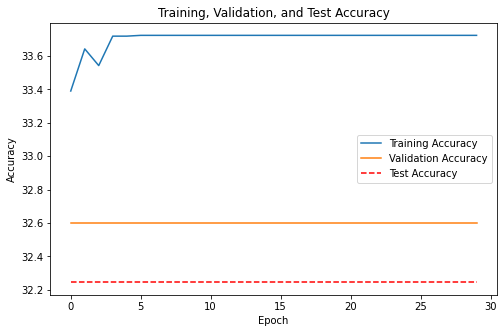

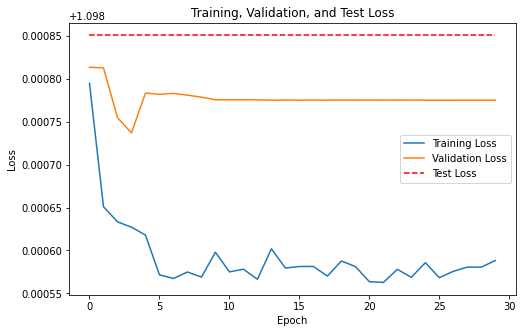

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adam, label='Training Accuracy')
plt.plot(validation_accuracy_adam, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adam, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adam, label='Training Loss')
plt.plot(validation_loss_adam, label='Validation Loss')
plt.plot(test_loss_plot_adam, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

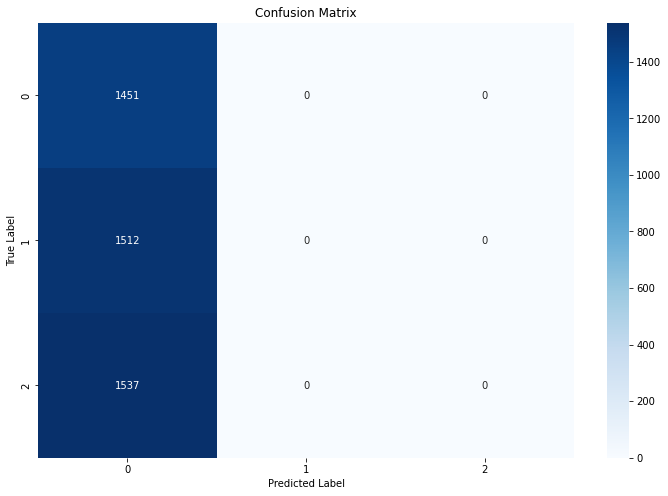

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adam, y_pred_adam)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Optimizer #2: Adam with he weight intialization: \\
Here we change the weight intialization to he and for this setup we removed the weight decay used in the optimizer and we can see that the model performed better. And we see model islearning as the validation accuracy is high but also remains stable showing its no overfitting. We notice small changes in the validation loss as it is decreasing intially but then sligtly increasing again. That might still be since the learning rate is still very small.

In [ ]:
model_adam_he = VGG_CNN_Model().to(device)
model_weight_intialization(model_adam_he,'he')
optimizer_adam_he = torch.optim.Adam(model_adam_he.parameters(), lr=0.0001)

scheduler_step_lr_adam_he = torch.optim.lr_scheduler.StepLR(optimizer_adam_he, step_size=5, gamma=0.1)
loss_function_adam_he = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss_adam_he = float('inf')
best_epoch_adam_he = 0
train_loss_adam_he = []
validation_loss_adam_he = []
train_accuracy_adam_he = []
validation_accuracy_adam_he = []

for epoch in range(epochs):
  model_adam_he.train()

  start_time = time.time()

  loop_train_loss_adam_he = 0
  correct_train_length_adam_he = 0
  total_train_adam_he = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adam_he.zero_grad()

    outputs = model_adam_he(inputs)

    loss = loss_function_adam_he(outputs, labels)
    loss.backward()
    optimizer_adam_he.step()

    _, predicted_adam_he = torch.max(outputs, 1)
    total_train_adam_he += labels.size(0)
    correct_train_length_adam_he += (predicted_adam_he == labels).sum().item()

    loop_train_loss_adam_he += loss.item()

  scheduler_step_lr_adam_he.step()

  #training accuracy and loss
  train_accuracy_value_adam_he = 100 * correct_train_length_adam_he / total_train_adam_he
  train_loss_adam_he.append(loop_train_loss_adam_he / len(train_loader))
  train_accuracy_adam_he.append(train_accuracy_value_adam_he)

  #Validation
  model_adam_he.eval()
  loop_val_loss_adam_he = 0
  correct_val_adam_he = 0
  total_val_adam_he = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adam_he(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adam_he(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adam_he = torch.max(val_outputs, 1)

      total_val_adam_he += val_labels.size(0)
      correct_val_adam_he += (predicted_adam_he == val_labels).sum().item()

      loop_val_loss_adam_he += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adam_he = 100 * correct_val_adam_he / total_val_adam_he
  validation_loss_adam_he.append(loop_val_loss_adam_he / len(val_loader))
  validation_accuracy_adam_he.append(val_accuracy_adam_he)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adam_he[-1]:.4f}, Train Accuracy: {train_accuracy_adam_he[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adam_he[-1]:.4f}, Val Accuracy: {validation_accuracy_adam_he[-1]:.2f}%")

  end_time = time.time()
  training_time_adam_he = end_time - start_time
  print(f"Training Time epoch {epoch+1}: {training_time_adam_he:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adam_he < best_validation_loss_adam_he:
      best_validation_loss_adam_he = loop_val_loss_adam_he
      best_epoch_adam_he = epoch + 1
      best_model_weight_adam_he = model_adam_he.state_dict()


if best_model_weight_adam_he is not None:
  torch.save(best_model_weight_adam_he, 'vgg_model_adam_he.pt')


# Test phase
model_adam_he.eval()
correct_test_length_adam_he = 0
total_test_adam_he = 0
y_true_adam_he = []
y_pred_adam_he = []

test_accuracy_adam_he =[]
test_total_loss_adam_he = 0.0
predicted_list_adam_he = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adam_he(inputs)

    labels = labels.view(-1)
    test_total_loss_adam_he += loss_function_adam_he(outputs, labels).item()

    _, predicted_adam_he = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adam_he += labels.size(0)
    correct_test_length_adam_he += (predicted_adam_he == labels).sum().item()

    y_true_adam_he.extend(labels.cpu().numpy())
    y_pred_adam_he.extend(predicted_adam_he.cpu().numpy())
    predicted_list_adam_he.extend(predicted_test_probs.cpu().numpy())


y_pred_adam_he = np.array(y_pred_adam_he)
y_true_adam_he = np.array(y_true_adam_he)
predicted_list_adam_he = np.array(predicted_list_adam_he)

test_accuracy_adam_he = 100 * (correct_test_length_adam_he / total_test_adam_he)
print(f"Test Accuracy: {test_accuracy_adam_he:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adam_he, y_pred_adam_he, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adam_he = test_total_loss_adam_he /len(test_loader)

test_accuracies_plot_adam_he = [test_accuracy_adam_he] * epochs
test_loss_plot_adam_he = [test_loss_adam_he] * epochs


/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/MPI/gcc/11.2.0/openmpi/4.1.1/pytorch/1.13.1-CUDA-11.8.0/lib/python3.9/site-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch [1/30], Train Loss: 0.5848, Train Accuracy: 76.12%, Val Loss: 0.4079, Val Accuracy: 84.84%
Training Time epoch 1: 19.79 seconds
Epoch [2/30], Train Loss: 0.3823, Train Accuracy: 85.42%, Val Loss: 0.3327, Val Accuracy: 87.38%
Training Time epoch 2: 19.53 seconds
Epoch [3/30], Train Loss: 0.3081, Train Accuracy: 88.31%, Val Loss: 0.2884, Val Accuracy: 89.47%
Training Time epoch 3: 19.78 seconds
Epoch [4/30], Train Loss: 0.2483, Train Accuracy: 90.76%, Val Loss: 0.2781, Val Accuracy: 89.64%
Training Time epoch 4: 19.66 seconds
Epoch [5/30], Train Loss: 0.2100, Train Accuracy: 92.26%, Val Loss: 0.2653, Val Accuracy: 90.29%
Training Time epoch 5: 19.52 seconds
Epoch [6/30], Train Loss: 0.0940, Train Accuracy: 96.82%, Val Loss: 0.2605, Val Accuracy: 91.78%
Training Time epoch 6: 19.53 seconds
Epoch [7/30], Train Loss: 0.0520, Train Accuracy: 98.34%, Val Loss: 0.3101, Val Accuracy: 91.56%
Training Time epoch 7: 19.54 seconds
Epoch [8/30], Train Loss: 0.0242, Train Accuracy: 99.30%, Val 

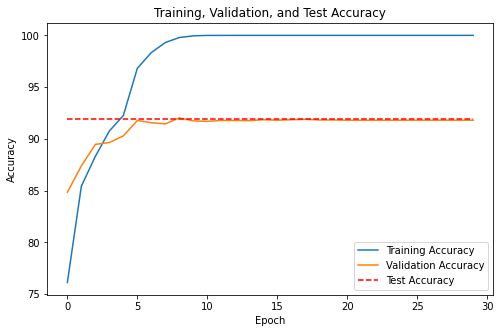

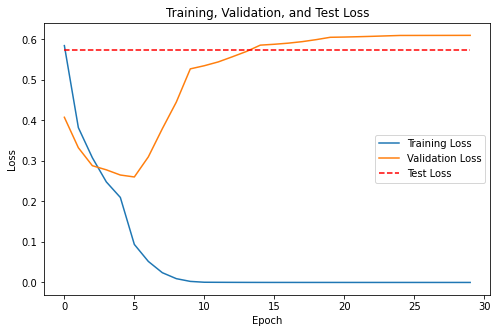

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adam_he, label='Training Accuracy')
plt.plot(validation_accuracy_adam_he, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adam_he, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adam_he, label='Training Loss')
plt.plot(validation_loss_adam_he, label='Validation Loss')
plt.plot(test_loss_plot_adam_he, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

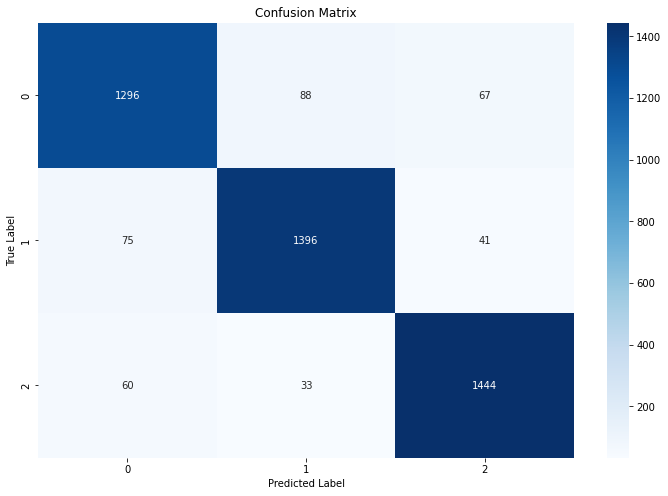

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adam_he, y_pred_adam_he)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Optimizer #3: Using AdamW with Xavier weight intialization: \\
Here we use anotherr optimizer i.e. AdamW with the xavier intialization. We go back to using the same learning rate and weight decay as used in VGG paper. We can model performs better than Adam and even better than SGD.

In [ ]:
model_adamW = VGG_CNN_Model().to(device)
model_weight_intialization(model_adamW, 'xavier')
optimizer_adamW = torch.optim.AdamW(model_adamW.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_adamW = torch.optim.lr_scheduler.StepLR(optimizer_adamW, step_size=5, gamma=0.1)
loss_function_adamW = nn.CrossEntropyLoss()



epochs = 30

best_validation_loss_adamW = float('inf')
best_epoch_adamW = 0
train_loss_adamW = []
validation_loss_adamW = []
train_accuracy_adamW = []
validation_accuracy_adamW = []

for epoch in range(epochs):
  model_adamW.train()

  start_time = time.time()

  loop_train_loss_adamW = 0
  correct_train_length_adamW = 0
  total_train_adamW = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adamW.zero_grad()

    outputs = model_adamW(inputs)

    loss = loss_function_adamW(outputs, labels)
    loss.backward()
    optimizer_adamW.step()

    _, predicted_adamW = torch.max(outputs, 1)
    total_train_adamW += labels.size(0)
    correct_train_length_adamW += (predicted_adamW == labels).sum().item()

    loop_train_loss_adamW += loss.item()

  scheduler_step_lr_adamW.step()

  #training accuracy and loss
  train_accuracy_value_adamW = 100 * correct_train_length_adamW / total_train_adamW
  train_loss_adamW.append(loop_train_loss_adamW / len(train_loader))
  train_accuracy_adamW.append(train_accuracy_value_adamW)

  #Validation
  model_adamW.eval()
  loop_val_loss_adamW = 0
  correct_val_adamW = 0
  total_val_adamW = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adamW(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adamW(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adamW = torch.max(val_outputs, 1)

      total_val_adamW += val_labels.size(0)
      correct_val_adamW += (predicted_adamW == val_labels).sum().item()

      loop_val_loss_adamW += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adamW = 100 * correct_val_adamW / total_val_adamW
  validation_loss_adamW.append(loop_val_loss_adamW / len(val_loader))
  validation_accuracy_adamW.append(val_accuracy_adamW)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adamW[-1]:.4f}, Train Accuracy: {train_accuracy_adamW[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adamW[-1]:.4f}, Val Accuracy: {validation_accuracy_adamW[-1]:.2f}%")

  end_time = time.time()
  training_time_adamW = end_time - start_time
  print(f"Training Time: {training_time_adamW:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adamW < best_validation_loss_adamW:
      best_validation_loss_adamW = loop_val_loss_adamW
      best_epoch_adamW = epoch + 1
      best_model_weight_adamW = model_adamW.state_dict()


if best_model_weight_adamW is not None:
  torch.save(best_model_weight_adamW, 'vgg_model_adamW.pt')


# Test phase
model_adamW.eval()
correct_test_length_adamW = 0
total_test_adamW = 0
y_true_adamW = []
y_pred_adamW = []

# test_loss = []
test_accuracy_adamW =[]
test_total_loss_adamW = 0.0
predicted_list_adamW = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adamW(inputs)

    labels = labels.view(-1)
    test_total_loss_adamW += loss_function_adamW(outputs, labels).item()

    _, predicted_adamW = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adamW += labels.size(0)
    correct_test_length_adamW += (predicted_adamW == labels).sum().item()

    y_true_adamW.extend(labels.cpu().numpy())
    y_pred_adamW.extend(predicted_adamW.cpu().numpy())
    predicted_list_adamW.extend(predicted_test_probs.cpu().numpy())


y_pred_adamW = np.array(y_pred_adamW)
y_true_adamW = np.array(y_true_adamW)
predicted_list_adamW = np.array(predicted_list_adamW)

test_accuracy_adamW = 100 * (correct_test_length_adamW / total_test_adamW)
print(f"Test Accuracy: {test_accuracy_adamW:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adamW, y_pred_adamW, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adamW = test_total_loss_adamW /len(test_loader)

test_accuracies_plot_adamW = [test_accuracy_adamW] * epochs
test_loss_plot_adamW = [test_loss_adamW] * epochs


/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/MPI/gcc/11.2.0/openmpi/4.1.1/pytorch/1.13.1-CUDA-11.8.0/lib/python3.9/site-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch [1/30], Train Loss: 0.6415, Train Accuracy: 71.37%, Val Loss: 0.4905, Val Accuracy: 81.47%
Training Time: 20.23 seconds
Epoch [2/30], Train Loss: 0.4248, Train Accuracy: 83.58%, Val Loss: 0.4249, Val Accuracy: 84.56%
Training Time: 19.98 seconds
Epoch [3/30], Train Loss: 0.3380, Train Accuracy: 87.45%, Val Loss: 0.4118, Val Accuracy: 83.36%
Training Time: 20.07 seconds
Epoch [4/30], Train Loss: 0.2973, Train Accuracy: 88.95%, Val Loss: 0.3063, Val Accuracy: 89.60%
Training Time: 20.14 seconds
Epoch [5/30], Train Loss: 0.2596, Train Accuracy: 90.47%, Val Loss: 0.3282, Val Accuracy: 89.36%
Training Time: 20.00 seconds
Epoch [6/30], Train Loss: 0.1787, Train Accuracy: 93.60%, Val Loss: 0.2469, Val Accuracy: 91.22%
Training Time: 20.12 seconds
Epoch [7/30], Train Loss: 0.1612, Train Accuracy: 94.15%, Val Loss: 0.2290, Val Accuracy: 91.89%
Training Time: 20.00 seconds
Epoch [8/30], Train Loss: 0.1507, Train Accuracy: 94.44%, Val Loss: 0.2388, Val Accuracy: 91.62%
Training Time: 20.14 

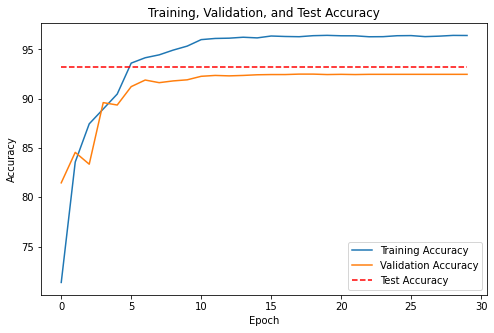

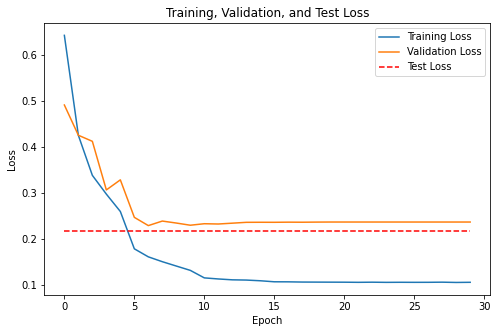

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adamW, label='Training Accuracy')
plt.plot(validation_accuracy_adamW, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adamW, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adamW, label='Training Loss')
plt.plot(validation_loss_adamW, label='Validation Loss')
plt.plot(test_loss_plot_adamW, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

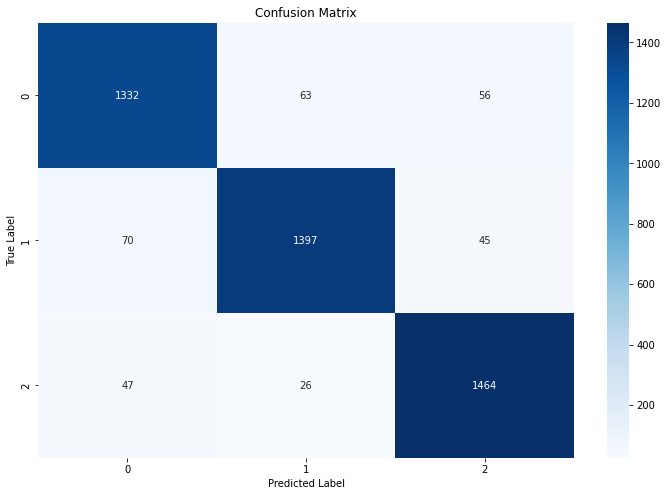

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adamW, y_pred_adamW)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Optimizer #3: Using AdamW with 'he' weight intialization: \\
Here using AdamW we change the intialization to he and we see a slight decrease in the accuracy. Now this is becuase the AdamW is an optimizer that changes and performs differnt based on the weight initalization used. He is used for Relu functions and works well. But AdamW changes/updates the learning rate. Mainly the larger weight intializationa affects the performace compared to using Xavier.

In [ ]:
model_adamW_he = VGG_CNN_Model().to(device)
model_weight_intialization(model_adamW_he,'he')
optimizer_adamW_he = torch.optim.AdamW(model_adamW_he.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_adamW_he = torch.optim.lr_scheduler.StepLR(optimizer_adamW_he, step_size=5, gamma=0.1)
loss_function_adamW_he = nn.CrossEntropyLoss()



epochs = 30

best_validation_loss_adamW_he = float('inf')
best_epoch_adamW_he = 0
train_loss_adamW_he = []
validation_loss_adamW_he = []
train_accuracy_adamW_he = []
validation_accuracy_adamW_he = []

for epoch in range(epochs):
  model_adamW_he.train()

  start_time = time.time()

  loop_train_loss_adamW_he = 0
  correct_train_length_adamW_he = 0
  total_train_adamW_he = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adamW_he.zero_grad()

    outputs = model_adamW_he(inputs)

    loss = loss_function_adamW_he(outputs, labels)
    loss.backward()
    optimizer_adamW_he.step()

    _, predicted_adamW_he = torch.max(outputs, 1)
    total_train_adamW_he += labels.size(0)
    correct_train_length_adamW_he += (predicted_adamW_he == labels).sum().item()

    loop_train_loss_adamW_he += loss.item()

  scheduler_step_lr_adamW_he.step()

  #training accuracy and loss
  train_accuracy_value_adamW_he = 100 * correct_train_length_adamW_he / total_train_adamW_he
  train_loss_adamW_he.append(loop_train_loss_adamW_he / len(train_loader))
  train_accuracy_adamW_he.append(train_accuracy_value_adamW_he)

  #Validation
  model_adamW_he.eval()
  loop_val_loss_adamW_he = 0
  correct_val_adamW_he = 0
  total_val_adamW_he = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adamW_he(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adamW_he(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adamW_he = torch.max(val_outputs, 1)

      total_val_adamW_he += val_labels.size(0)
      correct_val_adamW_he += (predicted_adamW_he == val_labels).sum().item()

      loop_val_loss_adamW_he += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adamW_he = 100 * correct_val_adamW_he / total_val_adamW_he
  validation_loss_adamW_he.append(loop_val_loss_adamW_he / len(val_loader))
  validation_accuracy_adamW_he.append(val_accuracy_adamW_he)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adamW_he[-1]:.4f}, Train Accuracy: {train_accuracy_adamW_he[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adamW_he[-1]:.4f}, Val Accuracy: {validation_accuracy_adamW_he[-1]:.2f}%")

  end_time = time.time()
  training_time_adamW_he = end_time - start_time
  print(f"Training Time {epoch+1}: {training_time_adamW_he:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adamW_he < best_validation_loss_adamW_he:
    best_validation_loss_adamW_he = loop_val_loss_adamW_he
    best_epoch_adamW_he = epoch + 1
    best_model_weight_adamW_he = model_adamW_he.state_dict()


if best_model_weight_adamW_he is not None:
  torch.save(best_model_weight_adamW_he, 'vgg_model_adamW_he.pt')


# Test phase
model_adamW_he.eval()
correct_test_length_adamW_he = 0
total_test_adamW_he = 0
y_true_adamW_he = []
y_pred_adamW_he = []

# test_loss = []
test_accuracy_adamW_he =[]
test_total_loss_adamW_he = 0.0
predicted_list_adamW_he = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adamW_he(inputs)

    labels = labels.view(-1)
    test_total_loss_adamW_he += loss_function_adamW_he(outputs, labels).item()

    _, predicted_adamW_he = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adamW_he += labels.size(0)
    correct_test_length_adamW_he += (predicted_adamW_he == labels).sum().item()

    y_true_adamW_he.extend(labels.cpu().numpy())
    y_pred_adamW_he.extend(predicted_adamW_he.cpu().numpy())
    predicted_list_adamW_he.extend(predicted_test_probs.cpu().numpy())


y_pred_adamW_he = np.array(y_pred_adamW_he)
y_true_adamW_he = np.array(y_true_adamW_he)
predicted_list_adamW_he = np.array(predicted_list_adamW_he)

test_accuracy_adamW_he = 100 * (correct_test_length_adamW_he / total_test_adamW_he)
print(f"Test Accuracy: {test_accuracy_adamW_he:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adamW_he, y_pred_adamW_he, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adamW_he = test_total_loss_adamW_he /len(test_loader)

test_accuracies_plot_adamW_he = [test_accuracy_adamW_he] * epochs
test_loss_plot_adamW_he = [test_loss_adamW_he] * epochs


/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/MPI/gcc/11.2.0/openmpi/4.1.1/pytorch/1.13.1-CUDA-11.8.0/lib/python3.9/site-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch [1/30], Train Loss: 0.5465, Train Accuracy: 77.61%, Val Loss: 0.4579, Val Accuracy: 84.02%
Training Time 1: 19.99 seconds
Epoch [2/30], Train Loss: 0.3618, Train Accuracy: 86.22%, Val Loss: 0.3208, Val Accuracy: 88.80%
Training Time 2: 20.39 seconds
Epoch [3/30], Train Loss: 0.2915, Train Accuracy: 89.29%, Val Loss: 0.2929, Val Accuracy: 89.18%
Training Time 3: 20.04 seconds
Epoch [4/30], Train Loss: 0.2363, Train Accuracy: 91.37%, Val Loss: 0.2704, Val Accuracy: 89.98%
Training Time 4: 20.11 seconds
Epoch [5/30], Train Loss: 0.1957, Train Accuracy: 92.74%, Val Loss: 0.2811, Val Accuracy: 90.38%
Training Time 5: 20.06 seconds
Epoch [6/30], Train Loss: 0.0867, Train Accuracy: 96.93%, Val Loss: 0.2612, Val Accuracy: 91.62%
Training Time 6: 19.96 seconds
Epoch [7/30], Train Loss: 0.0477, Train Accuracy: 98.59%, Val Loss: 0.2842, Val Accuracy: 92.02%
Training Time 7: 20.38 seconds
Epoch [8/30], Train Loss: 0.0209, Train Accuracy: 99.46%, Val Loss: 0.3551, Val Accuracy: 91.71%
Trainin

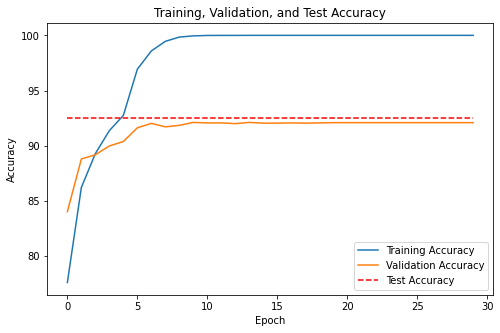

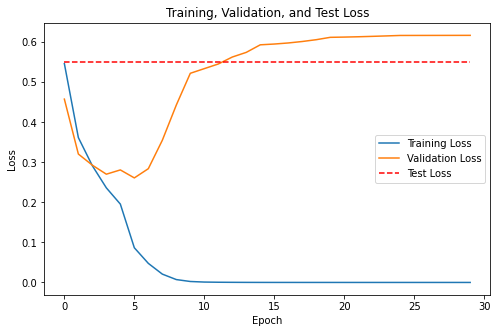

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adamW_he, label='Training Accuracy')
plt.plot(validation_accuracy_adamW_he, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adamW_he, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adamW_he, label='Training Loss')
plt.plot(validation_loss_adamW_he, label='Validation Loss')
plt.plot(test_loss_plot_adamW_he, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

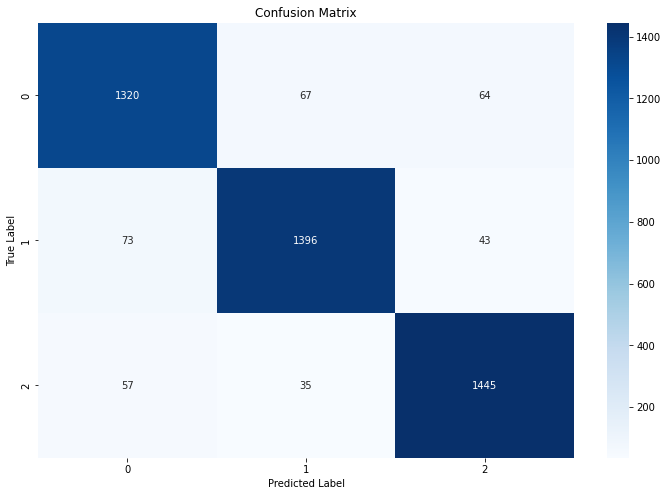

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adamW_he, y_pred_adamW_he)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Based on the models trained the best model setup, the one with AdamW optimizer and the weight initialization of 'Xavier' along with using StepLR learning rate scheduler with the batch size  used i.e. 32.**

Changing the batch size to 64 using the best model from above. Based on performace below we notice two main differnes. The first is that the accuaracy of the test data came down comapred to the best model. However then we should notice that the training time per epoch reduced compartively by atleast 4 seconds when increasing the batch size. Showing that if we are looking at time taken to train then the increase in batch size can be a good technique.

In [ ]:
#batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

model_batchsize = VGG_CNN_Model().to(device)
model_weight_intialization(model_batchsize,'he')
optimizer_batchsize = torch.optim.AdamW(model_batchsize.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_batchsize = torch.optim.lr_scheduler.StepLR(optimizer_batchsize, step_size=5, gamma=0.1)
loss_function_batchsize = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss_batchsize = float('inf')
best_epoch_batchsize = 0
train_loss_batchsize = []
validation_loss_batchsize = []
train_accuracy_batchsize = []
validation_accuracy_batchsize = []

for epoch in range(epochs):
  model_batchsize.train()

  start_time = time.time()

  loop_train_loss_batchsize = 0
  correct_train_length_batchsize = 0
  total_train_batchsize = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_batchsize.zero_grad()

    outputs = model_batchsize(inputs)

    loss = loss_function_batchsize(outputs, labels)
    loss.backward()
    optimizer_batchsize.step()

    _, predicted_batchsize = torch.max(outputs, 1)
    total_train_batchsize += labels.size(0)
    correct_train_length_batchsize += (predicted_batchsize == labels).sum().item()

    loop_train_loss_batchsize += loss.item()

  scheduler_step_lr_batchsize.step()

  #training accuracy and loss
  train_accuracy_value_batchsize = 100 * correct_train_length_batchsize / total_train_batchsize
  train_loss_batchsize.append(loop_train_loss_batchsize / len(train_loader))
  train_accuracy_batchsize.append(train_accuracy_value_batchsize)

  #Validation
  model_batchsize.eval()
  loop_val_loss_batchsize = 0
  correct_val_batchsize = 0
  total_val_batchsize = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_batchsize(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_batchsize(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_batchsize = torch.max(val_outputs, 1)

      total_val_batchsize += val_labels.size(0)
      correct_val_batchsize += (predicted_batchsize == val_labels).sum().item()

      loop_val_loss_batchsize += val_loss.item()

  #validation accuracy and loss
  val_accuracy_batchsize = 100 * correct_val_batchsize / total_val_batchsize
  validation_loss_batchsize.append(loop_val_loss_batchsize / len(val_loader))
  validation_accuracy_batchsize.append(val_accuracy_batchsize)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_batchsize[-1]:.4f}, Train Accuracy: {train_accuracy_batchsize[-1]:.2f}%, "
    f"Val Loss: {validation_loss_batchsize[-1]:.4f}, Val Accuracy: {validation_accuracy_batchsize[-1]:.2f}%")

  end_time = time.time()
  training_time_batchsize = end_time - start_time
  print(f"Training Time: {training_time_batchsize:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_batchsize < best_validation_loss_batchsize:
      best_validation_loss_batchsize = loop_val_loss_batchsize
      best_epoch_batchsize = epoch + 1
      best_model_weight_batchsize = model_batchsize.state_dict()

if best_model_weight_batchsize is not None:
  torch.save(best_model_weight_batchsize, 'vgg_model_batchsize.p')


# Test phase
model_batchsize.eval()
correct_test_length_batchsize = 0
total_test_batchsize = 0
y_true_batchsize = []
y_pred_batchsize = []

# test_loss = []
test_accuracy_batchsize =[]
test_total_loss_batchsize = 0.0
predicted_list_batchsize = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_batchsize(inputs)

    labels = labels.view(-1)
    test_total_loss_batchsize += loss_function_batchsize(outputs, labels).item()

    _, predicted_batchsize = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_batchsize += labels.size(0)
    correct_test_length_batchsize += (predicted_batchsize == labels).sum().item()

    y_true_batchsize.extend(labels.cpu().numpy())
    y_pred_batchsize.extend(predicted_batchsize.cpu().numpy())
    predicted_list_batchsize.extend(predicted_test_probs.cpu().numpy())


y_pred_batchsize = np.array(y_pred_batchsize)
y_true_batchsize = np.array(y_true_batchsize)
predicted_list_batchsize = np.array(predicted_list_batchsize)

test_accuracy_batchsize = 100 * (correct_test_length_batchsize / total_test_batchsize)
print(f"Test Accuracy: {test_accuracy_batchsize:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_batchsize, y_pred_batchsize, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_batchsize = test_total_loss_batchsize /len(test_loader)

test_accuracies_plot_batchsize = [test_accuracy_batchsize] * epochs
test_loss_plot_batchsize = [test_loss_batchsize] * epochs


Epoch [1/30], Train Loss: 0.5787, Train Accuracy: 75.86%, Val Loss: 0.4339, Val Accuracy: 83.71%
Training Time: 29.43 seconds
Epoch [2/30], Train Loss: 0.3672, Train Accuracy: 86.00%, Val Loss: 0.3388, Val Accuracy: 87.98%
Training Time: 16.07 seconds
Epoch [3/30], Train Loss: 0.2991, Train Accuracy: 88.61%, Val Loss: 0.2922, Val Accuracy: 89.80%
Training Time: 16.21 seconds
Epoch [4/30], Train Loss: 0.2589, Train Accuracy: 90.33%, Val Loss: 0.3467, Val Accuracy: 87.96%
Training Time: 16.06 seconds
Epoch [5/30], Train Loss: 0.2142, Train Accuracy: 91.93%, Val Loss: 0.2826, Val Accuracy: 90.16%
Training Time: 16.04 seconds
Epoch [6/30], Train Loss: 0.1003, Train Accuracy: 96.58%, Val Loss: 0.2638, Val Accuracy: 91.87%
Training Time: 15.92 seconds
Epoch [7/30], Train Loss: 0.0601, Train Accuracy: 98.02%, Val Loss: 0.3096, Val Accuracy: 91.71%
Training Time: 16.23 seconds
Epoch [8/30], Train Loss: 0.0324, Train Accuracy: 99.07%, Val Loss: 0.3586, Val Accuracy: 91.91%
Training Time: 16.08 

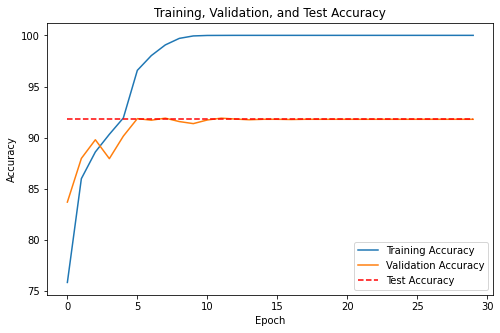

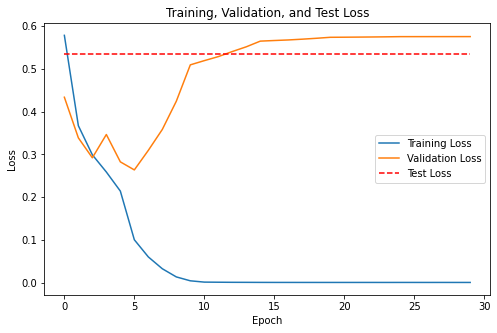

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_batchsize, label='Training Accuracy')
plt.plot(validation_accuracy_batchsize, label='Validation Accuracy')
plt.plot(test_accuracies_plot_batchsize, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_batchsize, label='Training Loss')
plt.plot(validation_loss_batchsize, label='Validation Loss')
plt.plot(test_loss_plot_batchsize, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

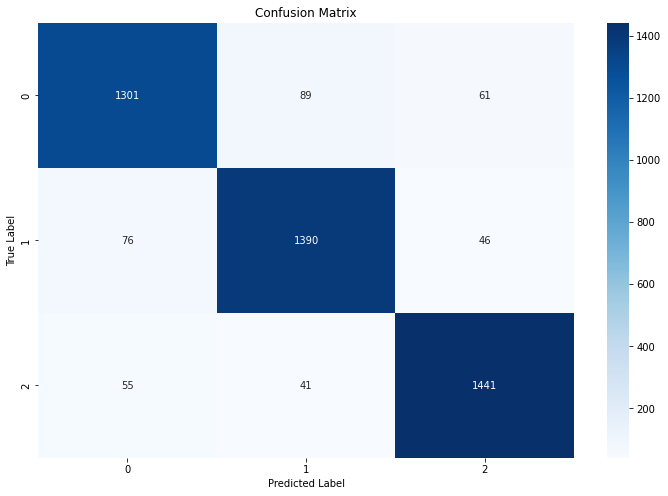

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_batchsize, y_pred_batchsize)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

4. Apply regularization and overfitting prevention techniques.

Technique #1: Early Stopping:

Using the above best model and including the new batch size to take into consideration the reduction in train time as well and we include the early stopping method. We can see from below data that the training time is still maintained lesser but we can see that the accuracy reduced a bit more compared to the batch size.

In [14]:
### ADD YOUR CODE HERE ###
#batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

model_early_stopping = VGG_CNN_Model().to(device)
model_weight_intialization(model_early_stopping,'he')
optimizer_early_stopping = torch.optim.AdamW(model_early_stopping.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_early_stopping = torch.optim.lr_scheduler.StepLR(optimizer_early_stopping, step_size=5, gamma=0.1)
loss_function_early_stopping = nn.CrossEntropyLoss()

epochs = 30
counter = 0
patience_value = 3

best_validation_loss_early_stopping = float('inf')
best_epoch_early_stopping = 0
train_loss_early_stopping = []
validation_loss_early_stopping = []
train_accuracy_early_stopping = []
validation_accuracy_early_stopping = []

for epoch in range(epochs):
  model_early_stopping.train()

  start_time = time.time()

  loop_train_loss_early_stopping = 0
  correct_train_length_early_stopping = 0
  total_train_early_stopping = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_early_stopping.zero_grad()

    outputs = model_early_stopping(inputs)

    loss = loss_function_early_stopping(outputs, labels)
    loss.backward()
    optimizer_early_stopping.step()

    _, predicted_early_stopping = torch.max(outputs, 1)
    total_train_early_stopping += labels.size(0)
    correct_train_length_early_stopping += (predicted_early_stopping == labels).sum().item()

    loop_train_loss_early_stopping += loss.item()

  scheduler_step_lr_early_stopping.step()

  #training accuracy and loss
  train_accuracy_value_early_stopping = 100 * correct_train_length_early_stopping / total_train_early_stopping
  train_loss_early_stopping.append(loop_train_loss_early_stopping / len(train_loader))
  train_accuracy_early_stopping.append(train_accuracy_value_early_stopping)

  #Validation
  model_early_stopping.eval()
  loop_val_loss_early_stopping = 0
  correct_val_early_stopping = 0
  total_val_early_stopping = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_early_stopping(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_early_stopping(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_early_stopping = torch.max(val_outputs, 1)

      total_val_early_stopping += val_labels.size(0)
      correct_val_early_stopping += (predicted_early_stopping == val_labels).sum().item()

      loop_val_loss_early_stopping += val_loss.item()

  #validation accuracy and loss
  val_accuracy_early_stopping = 100 * correct_val_early_stopping / total_val_early_stopping
  validation_loss_early_stopping.append(loop_val_loss_early_stopping / len(val_loader))
  validation_accuracy_early_stopping.append(val_accuracy_early_stopping)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_early_stopping[-1]:.4f}, Train Accuracy: {train_accuracy_early_stopping[-1]:.2f}%, "
    f"Val Loss: {validation_loss_early_stopping[-1]:.4f}, Val Accuracy: {validation_accuracy_early_stopping[-1]:.2f}%")

  end_time = time.time()
  training_time_early_stopping = end_time - start_time
  print(f"Training Time: {training_time_early_stopping:.2f} seconds")

  if loop_val_loss_early_stopping < best_validation_loss_early_stopping:
    best_validation_loss_early_stopping = loop_val_loss_early_stopping
    best_epoch_early_stopping = epoch + 1
    best_model_weight_early_stopping = model_early_stopping.state_dict()
    counter = 0
  else:
    counter += 1
    if counter >= patience_value:
        print(f"Early stopping at epoch {epoch + 1} having validation loss: {validation_loss_early_stopping[-1]:.4f}")
        break


if best_model_weight_early_stopping is not None:
    torch.save(best_model_weight_early_stopping, 'vgg_model_early_stopping.pt')

# Test phase
model_early_stopping.eval()
correct_test_length_early_stopping = 0
total_test_early_stopping = 0
y_true_early_stopping = []
y_pred_early_stopping = []

# test_loss = []
test_accuracy_early_stopping =[]
test_total_loss_early_stopping = 0.0
avg_test_accuracy_early_stopping = 0
test_epoch_accuracy_early_stopping = 0
predicted_list_early_stopping = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_early_stopping(inputs)

    labels = labels.view(-1)
    test_total_loss_early_stopping += loss_function_early_stopping(outputs, labels).item()

    _, predicted_early_stopping = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_early_stopping += labels.size(0)
    correct_test_length_early_stopping += (predicted_early_stopping == labels).sum().item()

    y_true_early_stopping.extend(labels.cpu().numpy())
    y_pred_early_stopping.extend(predicted_early_stopping.cpu().numpy())
    predicted_list_early_stopping.extend(predicted_test_probs.cpu().numpy())


y_pred_early_stopping = np.array(y_pred_early_stopping)
y_true_early_stopping = np.array(y_true_early_stopping)
predicted_list_early_stopping = np.array(predicted_list_early_stopping)

test_accuracy_early_stopping = 100 * (correct_test_length_early_stopping / total_test_early_stopping)
print(f"Test Accuracy: {test_accuracy_early_stopping:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_early_stopping, y_pred_early_stopping, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_early_stopping = test_total_loss_early_stopping /len(test_loader)

test_accuracies_plot_early_stopping = [test_accuracy_early_stopping] * epochs
test_loss_plot_early_stopping = [test_loss_early_stopping] * epochs


Epoch [1/30], Train Loss: 0.5980, Train Accuracy: 74.93%, Val Loss: 0.4010, Val Accuracy: 83.82%
Training Time: 21.59 seconds
Epoch [2/30], Train Loss: 0.3732, Train Accuracy: 85.73%, Val Loss: 0.3391, Val Accuracy: 88.27%
Training Time: 20.49 seconds
Epoch [3/30], Train Loss: 0.3097, Train Accuracy: 88.19%, Val Loss: 0.3560, Val Accuracy: 86.91%
Training Time: 20.56 seconds
Epoch [4/30], Train Loss: 0.2561, Train Accuracy: 90.58%, Val Loss: 0.3862, Val Accuracy: 87.58%
Training Time: 20.61 seconds
Epoch [5/30], Train Loss: 0.2255, Train Accuracy: 91.53%, Val Loss: 0.3067, Val Accuracy: 88.96%
Training Time: 20.69 seconds
Epoch [6/30], Train Loss: 0.1088, Train Accuracy: 96.19%, Val Loss: 0.2735, Val Accuracy: 91.49%
Training Time: 20.52 seconds
Epoch [7/30], Train Loss: 0.0657, Train Accuracy: 97.85%, Val Loss: 0.3039, Val Accuracy: 91.73%
Training Time: 20.71 seconds
Epoch [8/30], Train Loss: 0.0359, Train Accuracy: 98.95%, Val Loss: 0.3916, Val Accuracy: 91.31%
Training Time: 20.76 

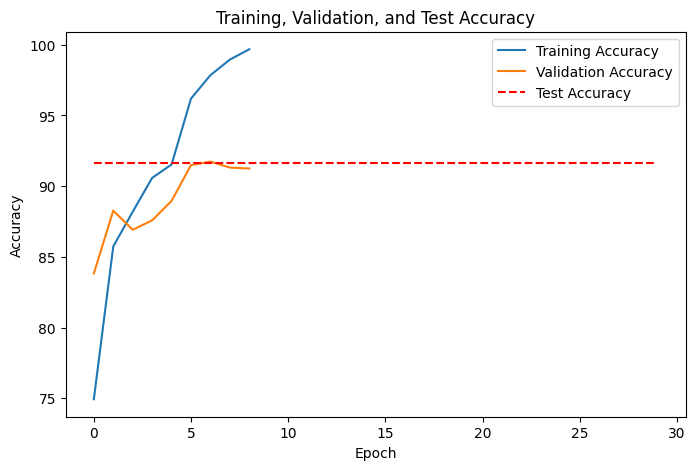

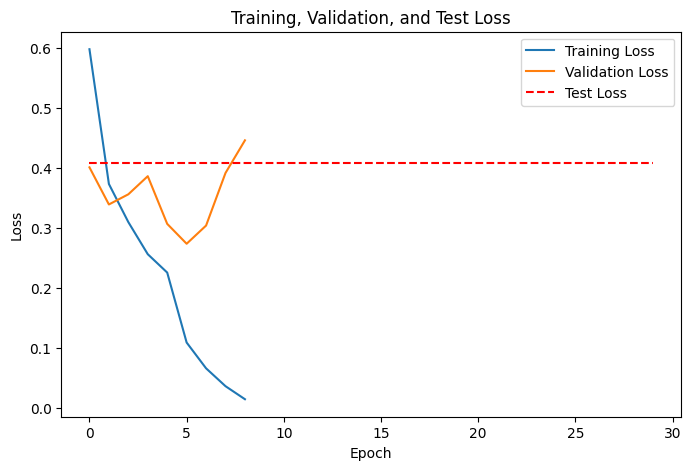

In [15]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_early_stopping, label='Training Accuracy')
plt.plot(validation_accuracy_early_stopping, label='Validation Accuracy')
plt.plot(test_accuracies_plot_early_stopping, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_early_stopping, label='Training Loss')
plt.plot(validation_loss_early_stopping, label='Validation Loss')
plt.plot(test_loss_plot_early_stopping, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

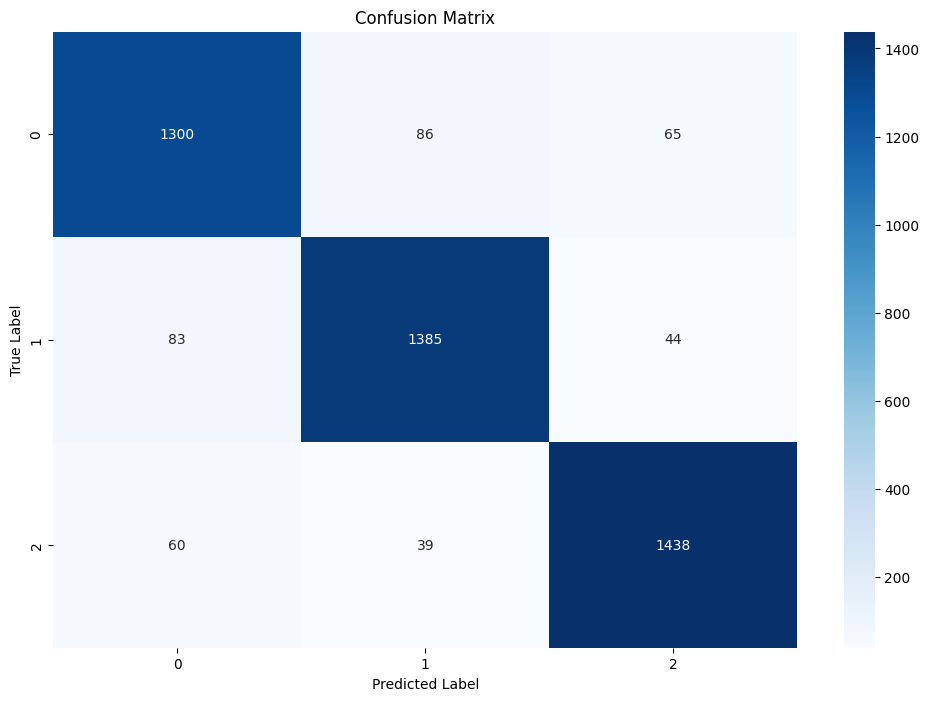

In [16]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_early_stopping, y_pred_early_stopping)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Technique #2: Changing the L2 regularization for Adam optimizer with Xavier intializaition: 

In this change we update the L2 regularization i.e. change the weight decay value from 5e-4 to 1e-4 and we can see a signifciant change with the performance with above adam optimizer model.

In [ ]:
#batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

model_adam_change = VGG_CNN_Model().to(device)
model_weight_intialization(model_adam_change,'xavier')
optimizer_adam_change = torch.optim.Adam(model_adam_change.parameters(), lr=0.0001, weight_decay=1e-5)

scheduler_step_lr_adam_change = torch.optim.lr_scheduler.StepLR(optimizer_adam_change, step_size=5, gamma=0.1)
loss_function_adam_change = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss_adam_change = float('inf')
best_epoch_adam_change = 0
train_loss_adam_change = []
validation_loss_adam_change = []
train_accuracy_adam_change = []
validation_accuracy_adam_change = []

for epoch in range(epochs):
  model_adam_change.train()

  start_time = time.time()

  loop_train_loss_adam_change = 0
  correct_train_length_adam_change = 0
  total_train_adam_change = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adam_change.zero_grad()

    outputs = model_adam_change(inputs)

    loss = loss_function_adam_change(outputs, labels)
    loss.backward()
    optimizer_adam_change.step()

    _, predicted_adam_change = torch.max(outputs, 1)
    total_train_adam_change += labels.size(0)
    correct_train_length_adam_change += (predicted_adam_change == labels).sum().item()

    loop_train_loss_adam_change += loss.item()

  scheduler_step_lr_adam_change.step()

  #training accuracy and loss
  train_accuracy_value_adam_change = 100 * correct_train_length_adam_change / total_train_adam_change
  train_loss_adam_change.append(loop_train_loss_adam_change / len(train_loader))
  train_accuracy_adam_change.append(train_accuracy_value_adam_change)

  #Validation
  model_adam_change.eval()
  loop_val_loss_adam_change = 0
  correct_val_adam_change = 0
  total_val_adam_change = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adam_change(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adam_change(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adam_change = torch.max(val_outputs, 1)

      total_val_adam_change += val_labels.size(0)
      correct_val_adam_change += (predicted_adam_change == val_labels).sum().item()

      loop_val_loss_adam_change += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adam_change = 100 * correct_val_adam_change / total_val_adam_change
  validation_loss_adam_change.append(loop_val_loss_adam_change / len(val_loader))
  validation_accuracy_adam_change.append(val_accuracy_adam_change)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adam_change[-1]:.4f}, Train Accuracy: {train_accuracy_adam_change[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adam_change[-1]:.4f}, Val Accuracy: {validation_accuracy_adam_change[-1]:.2f}%")

  end_time = time.time()
  training_time_adam_change = end_time - start_time
  print(f"Training Time: {training_time_adam_change:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adam_change < best_validation_loss_adam_change:
    best_validation_loss_adam_change = loop_val_loss_adam_change
    best_epoch_adam_change = epoch + 1
    best_model_weight_adam_change = model_adam_change.state_dict()


if best_model_weight_adam_change is not None:
    torch.save(best_model_weight_adam_change, 'vgg_model_adam_change.pt')


# Test phase
model_adam_change.eval()
correct_test_length_adam_change = 0
total_test_adam_change = 0
y_true_adam_change = []
y_pred_adam_change = []

# test_loss = []
test_accuracy_adam_change =[]
test_total_loss_adam_change = 0.0
predicted_list_adam_change = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adam_change(inputs)

    labels = labels.view(-1)
    test_total_loss_adam_change += loss_function_adam_change(outputs, labels).item()

    _, predicted_adam_change = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adam_change += labels.size(0)
    correct_test_length_adam_change += (predicted_adam_change == labels).sum().item()

    y_true_adam_change.extend(labels.cpu().numpy())
    y_pred_adam_change.extend(predicted_adam_change.cpu().numpy())
    predicted_list_adam_change.extend(predicted_test_probs.cpu().numpy())


y_pred_adam_change = np.array(y_pred_adam_change)
y_true_batchsize = np.array(y_true_adam_change)
predicted_list_adam_change = np.array(predicted_list_adam_change)

test_accuracy_adam_change = 100 * (correct_test_length_adam_change / total_test_adam_change)
print(f"Test Accuracy: {test_accuracy_adam_change:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adam_change, y_pred_adam_change, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adam_change = test_total_loss_adam_change /len(test_loader)

test_accuracies_plot_adam_change = [test_accuracy_adam_change] * epochs
test_loss_plot_adam_change = [test_loss_adam_change] * epochs


/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/MPI/gcc/11.2.0/openmpi/4.1.1/pytorch/1.13.1-CUDA-11.8.0/lib/python3.9/site-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch [1/30], Train Loss: 0.7105, Train Accuracy: 67.85%, Val Loss: 0.5614, Val Accuracy: 77.53%
Training Time: 16.32 seconds
Epoch [2/30], Train Loss: 0.4467, Train Accuracy: 82.78%, Val Loss: 0.4333, Val Accuracy: 83.40%
Training Time: 16.44 seconds
Epoch [3/30], Train Loss: 0.3660, Train Accuracy: 86.02%, Val Loss: 0.3540, Val Accuracy: 86.89%
Training Time: 16.16 seconds
Epoch [4/30], Train Loss: 0.3258, Train Accuracy: 87.95%, Val Loss: 0.3316, Val Accuracy: 87.53%
Training Time: 16.18 seconds
Epoch [5/30], Train Loss: 0.2859, Train Accuracy: 89.49%, Val Loss: 0.2940, Val Accuracy: 89.73%
Training Time: 16.37 seconds
Epoch [6/30], Train Loss: 0.2134, Train Accuracy: 92.17%, Val Loss: 0.2529, Val Accuracy: 90.98%
Training Time: 16.04 seconds
Epoch [7/30], Train Loss: 0.1998, Train Accuracy: 92.57%, Val Loss: 0.2472, Val Accuracy: 91.29%
Training Time: 16.18 seconds
Epoch [8/30], Train Loss: 0.1897, Train Accuracy: 93.02%, Val Loss: 0.2414, Val Accuracy: 91.38%
Training Time: 16.18 

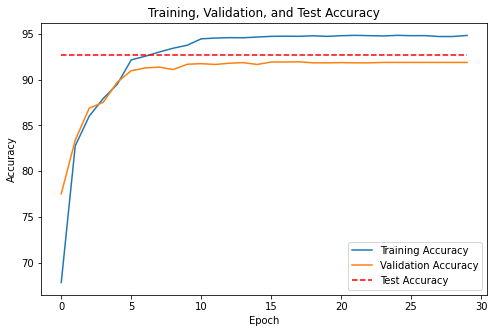

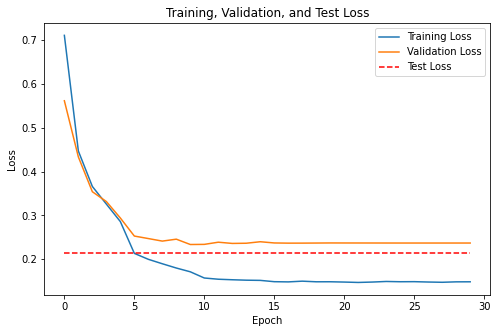

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adam_change, label='Training Accuracy')
plt.plot(validation_accuracy_adam_change, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adam_change, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adam_change, label='Training Loss')
plt.plot(validation_loss_adam_change, label='Validation Loss')
plt.plot(test_loss_plot_adam_change, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

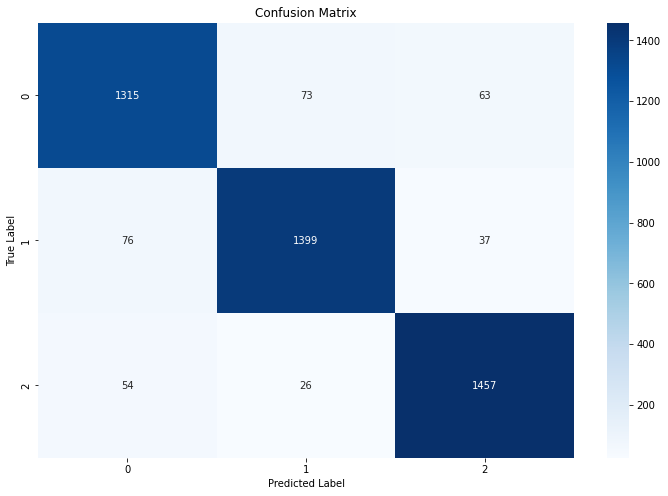

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adam_change, y_pred_adam_change)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Technique #3: Batch Normalization:

Here we add batch normalization to each layer of the VGG model created above. We continue to use batch size 64 and here we use the above model setup of Adam optimizer and along with making few changes to the learning rate value where I increase the value slightly from 0.0001 to 0.0005 and using the weight decay of 1e-5.

Based on those changes we can see that batch normatlisation yielded the best performaing model with good accuracy as well maintaing a low trianing time per epoch.

Here we can see below in the graphs that we have good trianing and vlaidation accuracies. The learning rate value of 0.0005 not that huge helps prevent/avoid fluctuations in the performance.

In [31]:
### ADD YOUR CODE HERE ###
class VGG_CNN_Model_Batch_Norm(nn.Module):
  def __init__(self):
    super(VGG_CNN_Model_Batch_Norm, self).__init__()

    # Block 1 layers
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(64)
    self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 2 layers
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)
    self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(128)
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 3 layers
    self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn5 = nn.BatchNorm2d(256)
    self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn6 = nn.BatchNorm2d(256)
    self.conv7 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn7 = nn.BatchNorm2d(256)
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 4 layers
    self.conv8 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
    self.bn8 = nn.BatchNorm2d(512)
    self.conv9 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn9 = nn.BatchNorm2d(512)
    self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn10 = nn.BatchNorm2d(512)
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 5 layers
    self.conv11 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn11 = nn.BatchNorm2d(512)
    self.conv12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn12 = nn.BatchNorm2d(512)
    self.conv13 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn13 = nn.BatchNorm2d(512)

    #FC layers
    self.fc1 = nn.Linear(512 * 4 * 4, 4096)   # for input 64x64
    self.fc2 = nn.Linear(4096, 4096)
    self.fc3 = nn.Linear(4096, 3)  # 3 is the number of classes

    # dropout as used in VGG model for regularization
    self.dropout = nn.Dropout(p=0.5)

  def forward(self, x):
    #Block 1
    x = nn.ReLU()(self.bn1(self.conv1(x)))
    x = self.pool1(nn.ReLU()(self.bn2(self.conv2(x))))

    #Block 2
    x = nn.ReLU()(self.bn3(self.conv3(x)))
    x = self.pool2(nn.ReLU()(self.bn4(self.conv4(x))))

    #Block 3
    x = nn.ReLU()(self.bn5(self.conv5(x)))
    x = nn.ReLU()(self.bn6(self.conv6(x)))
    x = self.pool3(nn.ReLU()(self.bn7(self.conv7(x))))

    #Block 4
    x = nn.ReLU()(self.bn8(self.conv8(x)))
    x = nn.ReLU()(self.bn9(self.conv9(x)))
    x = self.pool4(nn.ReLU()(self.bn10(self.conv10(x))))

    #Block 5
    x = nn.ReLU()(self.bn11(self.conv11(x)))
    x = nn.ReLU()(self.bn12(self.conv12(x)))
    x = nn.ReLU()(self.bn13(self.conv13(x)))

    x = x.view(-1, 512 * 4 *4)

    #adding the dropout for the fc layers as in VGG paper
    x = self.dropout(nn.ReLU()(self.fc1(x)))
    x = self.dropout(nn.ReLU()(self.fc2(x)))
    x = self.fc3(x)

    return x


In [32]:
#batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

model_batch_norm = VGG_CNN_Model_Batch_Norm().to(device)

model_weight_intialization(model_batch_norm,'xavier')
optimizer_batch_norm = torch.optim.Adam(model_batch_norm.parameters(), lr=0.0005, weight_decay=1e-5)

scheduler_step_lr_batch_norm = torch.optim.lr_scheduler.StepLR(optimizer_batch_norm, step_size=5, gamma=0.1)
loss_function_batch_norm = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss_batch_norm = float('inf')
best_epoch_batch_norm = 0
train_loss_batch_norm = []
validation_loss_batch_norm = []
train_accuracy_batch_norm = []
validation_accuracy_batch_norm = []

for epoch in range(epochs):
  model_batch_norm.train()

  start_time = time.time()

  loop_train_loss_batch_norm = 0
  correct_train_length_batch_norm = 0
  total_train_batch_norm = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_batch_norm.zero_grad()

    outputs = model_batch_norm(inputs)

    loss = loss_function_batch_norm(outputs, labels)
    loss.backward()
    optimizer_batch_norm.step()

    _, predicted_batch_norm = torch.max(outputs, 1)
    total_train_batch_norm += labels.size(0)
    correct_train_length_batch_norm += (predicted_batch_norm == labels).sum().item()

    loop_train_loss_batch_norm += loss.item()

  scheduler_step_lr_batch_norm.step()

  #training accuracy and loss
  train_accuracy_value_batch_norm = 100 * correct_train_length_batch_norm / total_train_batch_norm
  train_loss_batch_norm.append(loop_train_loss_batch_norm / len(train_loader))
  train_accuracy_batch_norm.append(train_accuracy_value_batch_norm)

  #Validation
  model_batch_norm.eval()
  loop_val_loss_batch_norm = 0
  correct_val_batch_norm = 0
  total_val_batch_norm = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_batch_norm(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_batch_norm(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_batch_norm = torch.max(val_outputs, 1)

      total_val_batch_norm += val_labels.size(0)
      correct_val_batch_norm += (predicted_batch_norm == val_labels).sum().item()

      loop_val_loss_batch_norm += val_loss.item()

  #validation accuracy and loss
  val_accuracy_batch_norm = 100 * correct_val_batch_norm / total_val_batch_norm
  validation_loss_batch_norm.append(loop_val_loss_batch_norm / len(val_loader))
  validation_accuracy_batch_norm.append(val_accuracy_batch_norm)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_batch_norm[-1]:.4f}, Train Accuracy: {train_accuracy_batch_norm[-1]:.2f}%, "
    f"Val Loss: {validation_loss_batch_norm[-1]:.4f}, Val Accuracy: {validation_accuracy_batch_norm[-1]:.2f}%")

  end_time = time.time()
  training_time_batch_norm = end_time - start_time
  print(f"Training Time: {training_time_batch_norm:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_batch_norm < best_validation_loss_batch_norm:
    best_validation_loss_batch_norm = loop_val_loss_batch_norm
    best_epoch_batch_norm = epoch + 1
    best_model_weight_batch_norm = model_batch_norm.state_dict()


if best_model_weight_batch_norm is not None:
    torch.save(best_model_weight_batch_norm, 'vgg_model_batch_norm.pt')


# Test phase
model_batch_norm.eval()
correct_test_length_batch_norm = 0
total_test_batch_norm = 0
y_true_batch_norm = []
y_pred_batch_norm = []

# test_loss = []
test_accuracy_batch_norm =[]
test_total_loss_batch_norm = 0.0
predicted_list_batch_norm = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_batch_norm(inputs)

    labels = labels.view(-1)
    test_total_loss_batch_norm += loss_function_batch_norm(outputs, labels).item()

    _, predicted_batch_norm = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_batch_norm += labels.size(0)
    correct_test_length_batch_norm += (predicted_batch_norm == labels).sum().item()

    y_true_batch_norm.extend(labels.cpu().numpy())
    y_pred_batch_norm.extend(predicted_batch_norm.cpu().numpy())
    predicted_list_batch_norm.extend(predicted_test_probs.cpu().numpy())


y_pred_batch_norm = np.array(y_pred_batch_norm)
y_true_batch_norm = np.array(y_true_batch_norm)
predicted_list_batch_norm = np.array(predicted_list_batch_norm)

test_accuracy_batch_norm = 100 * (correct_test_length_batch_norm / total_test_batch_norm)
print(f"Test Accuracy: {test_accuracy_batch_norm:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_batch_norm, y_pred_batch_norm, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_batch_norm = test_total_loss_batch_norm /len(test_loader)

test_accuracies_plot_batch_norm = [test_accuracy_batch_norm] * epochs
test_loss_plot_batch_norm = [test_loss_batch_norm] * epochs


Epoch [1/30], Train Loss: 0.8979, Train Accuracy: 67.18%, Val Loss: 0.8026, Val Accuracy: 67.60%
Training Time: 21.54 seconds
Epoch [2/30], Train Loss: 0.4448, Train Accuracy: 84.15%, Val Loss: 0.7405, Val Accuracy: 81.84%
Training Time: 21.51 seconds
Epoch [3/30], Train Loss: 0.4809, Train Accuracy: 83.96%, Val Loss: 0.3374, Val Accuracy: 87.29%
Training Time: 21.50 seconds
Epoch [4/30], Train Loss: 0.3335, Train Accuracy: 88.15%, Val Loss: 0.4419, Val Accuracy: 85.29%
Training Time: 21.53 seconds
Epoch [5/30], Train Loss: 0.4146, Train Accuracy: 87.66%, Val Loss: 0.2866, Val Accuracy: 89.58%
Training Time: 21.54 seconds
Epoch [6/30], Train Loss: 0.2519, Train Accuracy: 91.17%, Val Loss: 0.2240, Val Accuracy: 92.18%
Training Time: 21.53 seconds
Epoch [7/30], Train Loss: 0.2185, Train Accuracy: 91.93%, Val Loss: 0.2117, Val Accuracy: 91.96%
Training Time: 21.54 seconds
Epoch [8/30], Train Loss: 0.2594, Train Accuracy: 92.36%, Val Loss: 0.2058, Val Accuracy: 93.18%
Training Time: 21.56 

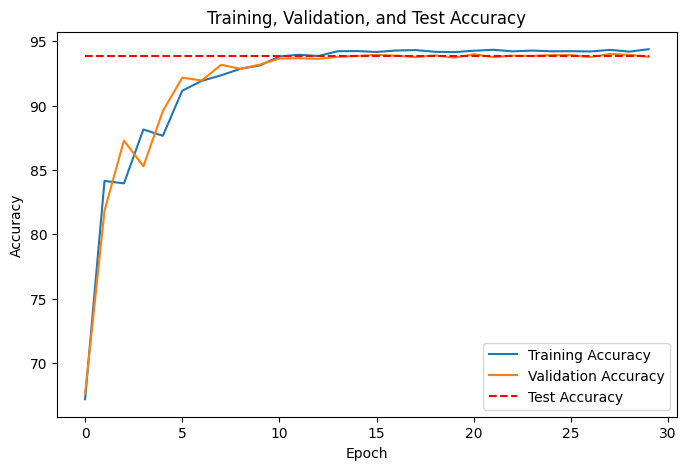

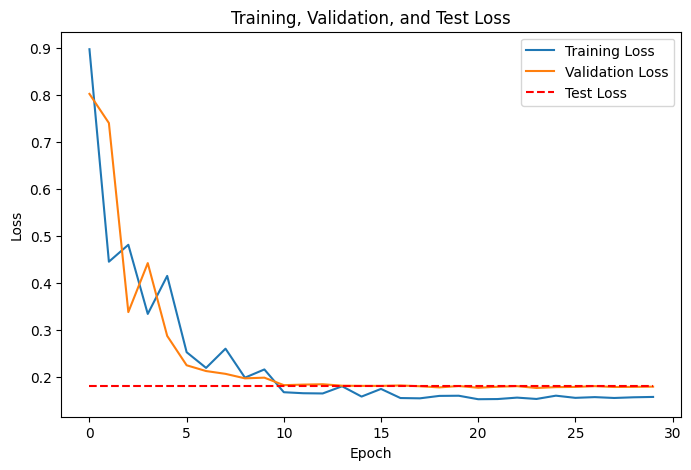

In [33]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_batch_norm, label='Training Accuracy')
plt.plot(validation_accuracy_batch_norm, label='Validation Accuracy')
plt.plot(test_accuracies_plot_batch_norm, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_batch_norm, label='Training Loss')
plt.plot(validation_loss_batch_norm, label='Validation Loss')
plt.plot(test_loss_plot_batch_norm, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

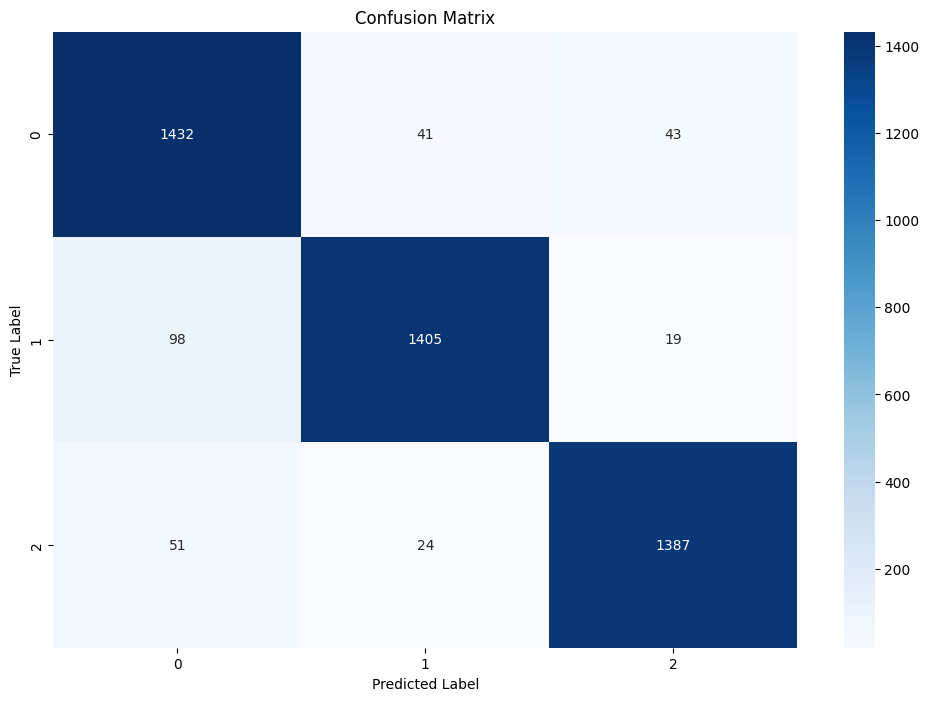

In [34]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_batch_norm, y_pred_batch_norm)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

5. Evaluation and analysis.

In [ ]:
### ADD YOUR CODE HERE ###

# COMPLETED FOR EACH MODEL ABOVE

6. Save the weights of the trained network.

In [ ]:
### ADD YOUR CODE HERE ###

# SAVED FOR EACH MODEL

# UPLOADING ONLY THE BEST MODEL

**The most improved model is the VGG model with batch normalization that uses a batchsize of 64 along with StepLR learning rate scheduler and uses Xavier weight intialization and Adam optimizer**

## Step 3: Implementing ResNet

Data Loading

In [18]:
#transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

#Loading the dataset
dataset_dir = "/kaggle/input/cnn-dataset" #extract_dir
full_ds = datasets.ImageFolder(root=dataset_dir, transform=transform)
class_names = full_ds.classes

batch_size = 32
data_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=True)


PreProcessing

In [19]:
#defining the data augmentation and preprocessing transforms we will be using, resized to 64*64 for smoother processing
data_augmentation = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize to 64x64
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(10),
    transforms.RandomResizedCrop(64, scale=(0.9, 1.0)),
    transforms.ToTensor(),
])

#preprocessing function
def preprocess(image, label):
    # Convert Tensor to PIL Image
    image = transforms.ToPILImage()(image)
    image = data_augmentation(image)
    return image, label

#transformations
augmented_ds = [(preprocess(image, label)) for image, label in full_ds]

#creating DataLoader
augmented_loader = DataLoader(augmented_ds, batch_size=32, shuffle=True)

print("Preprocessing with resizing completed.")

Preprocessing with resizing completed.


Splitting

In [20]:
#ds size
dataset_count = len(augmented_ds)
print("Total number of images:", dataset_count)

#spliting in 7:1.5:1.5
train_size = int(0.7 * dataset_count)
val_size = int(0.15 * dataset_count)
test_size = dataset_count - train_size - val_size

print("Training examples:", train_size)
print("Validation examples:", val_size)
print("Testing examples:", test_size)

#spliting the dataset
train_ds, val_ds, test_ds = random_split(augmented_ds, [train_size, val_size, test_size])

#batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Total number of images: 30000
Training examples: 21000
Validation examples: 4500
Testing examples: 4500


1. Implement residual blocks of ResNet.

In [21]:
### ADD YOUR CODE HERE ###
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out


2. Assemble the ResNet-18 architecture.

In [22]:
### ADD YOUR CODE HERE ###
class ResNet18(nn.Module):
    def __init__(self, num_classes=1000):
        super(ResNet18, self).__init__()
        self.in_channels = 64

        #initial convolution, batch norm, activation, and max pooling
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        #built residual layers using the ResidualBlock
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        #adaptive average pooling and fully connected layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Classification head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [ ]:
#initializing the ResNet 18 model
model = ResNet18(num_classes=3).to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=

2. Use dropout and learning rate scheduler. Experiment with weight initialization strategies.

In [23]:
### ADD YOUR CODE HERE ###
def model_weight_intialization(model, init_method):
  for layer in model.modules():
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
      if init_method == 'xavier':
        nn.init.xavier_normal_(layer.weight)
        if layer.bias is not None:
          nn.init.zeros_(layer.bias)

      elif init_method == 'he':
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        if layer.bias is not None:
          nn.init.zeros_(layer.bias)

In [ ]:
model_weight_intialization(model,'xavier')

#same setup as mentioned in VGG model above
optimizer_sgd_resnet = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler_step_lr_sgd_resnet = torch.optim.lr_scheduler.StepLR(optimizer_sgd_resnet, step_size=5, gamma=0.1) #reduce by factor 10

loss_function_sgd_resnet = nn.CrossEntropyLoss()

3. Train the ResNet-18 model.

Optimizer #1: SGD with Xavier intialization

In [ ]:
### ADD YOUR CODE HERE ###
# training using SGD Optimizer (used code from a0_part3_ra65)

epochs = 30

best_validation_loss_sgd_resnet = float('inf')
best_epoch_sgd_resnet = 0
train_loss_sgd_resnet = []
validation_loss_sgd_resnet = []
train_accuracy_sgd_resnet = []
validation_accuracy_sgd_resnet = []

for epoch in range(epochs):
  model.train()

  start_time = time.time()

  loop_train_loss_sgd_resnet = 0
  correct_train_length_sgd_resnet = 0
  total_train_sgd_resnet = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_sgd_resnet.zero_grad()

    outputs = model(inputs)

    loss = loss_function_sgd_resnet(outputs, labels)
    loss.backward()
    optimizer_sgd_resnet.step()

    _, predicted_sgd_resnet = torch.max(outputs, 1)
    total_train_sgd_resnet += labels.size(0)
    correct_train_length_sgd_resnet += (predicted_sgd_resnet == labels).sum().item()

    loop_train_loss_sgd_resnet += loss.item()

  scheduler_step_lr_sgd_resnet.step() #learning rate scheduler

  #training accuracy and loss
  train_accuracy_value_sgd_resnet = 100 * correct_train_length_sgd_resnet / total_train_sgd_resnet
  train_loss_sgd_resnet.append(loop_train_loss_sgd_resnet / len(train_loader))
  train_accuracy_sgd_resnet.append(train_accuracy_value_sgd_resnet)

  #Validation
  model.eval()
  loop_val_loss_sgd_resnet = 0
  correct_val_sgd_resnet = 0
  total_val_sgd_resnet = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_sgd_resnet(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_sgd_resnet = torch.max(val_outputs, 1)

      total_val_sgd_resnet += val_labels.size(0)
      correct_val_sgd_resnet += (predicted_sgd_resnet == val_labels).sum().item()

      loop_val_loss_sgd_resnet += val_loss.item()

  #validation accuracy and loss
  val_accuracy_sgd_resnet = 100 * correct_val_sgd_resnet / total_val_sgd_resnet
  validation_loss_sgd_resnet.append(loop_val_loss_sgd_resnet / len(val_loader))
  validation_accuracy_sgd_resnet.append(val_accuracy_sgd_resnet)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_sgd_resnet[-1]:.4f}, Train Accuracy: {train_accuracy_sgd_resnet[-1]:.2f}%, "
    f"Val Loss: {validation_loss_sgd_resnet[-1]:.4f}, Val Accuracy: {validation_accuracy_sgd_resnet[-1]:.2f}%")

  end_time = time.time()
  training_time_sgd_resnet = end_time - start_time
  print(f"Training Time: {training_time_sgd_resnet:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_sgd_resnet < best_validation_loss_sgd_resnet:
    best_validation_loss_sgd_resnet = loop_val_loss_sgd_resnet
    best_epoch_sgd_resnet = epoch + 1
    best_model_weight_sgd_resnet = model.state_dict()


if best_model_weight_sgd_resnet is not None:
    torch.save(best_model_weight_sgd_resnet, 'resnet_model_sgd_resnet_xavier.pt')


Epoch [1/30], Train Loss: 0.4748, Train Accuracy: 81.42%, Val Loss: 0.3827, Val Accuracy: 85.20%
Training Time: 8.21 seconds
Epoch [2/30], Train Loss: 0.3306, Train Accuracy: 87.30%, Val Loss: 0.3433, Val Accuracy: 86.00%
Training Time: 8.17 seconds
Epoch [3/30], Train Loss: 0.2752, Train Accuracy: 89.55%, Val Loss: 1.1343, Val Accuracy: 64.69%
Training Time: 8.19 seconds
Epoch [4/30], Train Loss: 0.2311, Train Accuracy: 91.32%, Val Loss: 0.3284, Val Accuracy: 87.64%
Training Time: 8.19 seconds
Epoch [5/30], Train Loss: 0.1852, Train Accuracy: 93.00%, Val Loss: 0.3149, Val Accuracy: 87.69%
Training Time: 8.18 seconds
Epoch [6/30], Train Loss: 0.0796, Train Accuracy: 97.39%, Val Loss: 0.2379, Val Accuracy: 91.16%
Training Time: 8.18 seconds
Epoch [7/30], Train Loss: 0.0392, Train Accuracy: 98.80%, Val Loss: 0.2706, Val Accuracy: 91.18%
Training Time: 8.20 seconds
Epoch [8/30], Train Loss: 0.0209, Train Accuracy: 99.55%, Val Loss: 0.2944, Val Accuracy: 91.07%
Training Time: 8.18 seconds


In [ ]:
# Test phase
model.eval()
correct_test_length_sgd_resnet = 0
total_test_sgd_resnet = 0
y_true_sgd_resnet = []
y_pred_sgd_resnet = []

# test_loss = []
test_accuracy_sgd_resnet =[]
test_total_loss_sgd_resnet = 0.0
predicted_list_sgd_resnet = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)

    labels = labels.view(-1)
    test_total_loss_sgd_resnet += loss_function_sgd_resnet(outputs, labels).item()

    _, predicted_sgd_resnet = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_sgd_resnet += labels.size(0)
    correct_test_length_sgd_resnet += (predicted_sgd_resnet == labels).sum().item()

    y_true_sgd_resnet.extend(labels.cpu().numpy())
    y_pred_sgd_resnet.extend(predicted_sgd_resnet.cpu().numpy())
    predicted_list_sgd_resnet.extend(predicted_test_probs.cpu().numpy())


y_pred_sgd_resnet = np.array(y_pred_sgd_resnet)
y_true_sgd_resnet = np.array(y_true_sgd_resnet)
predicted_list_sgd_resnet = np.array(predicted_list_sgd_resnet)

test_accuracy_sgd_resnet = 100 * (correct_test_length_sgd_resnet / total_test_sgd_resnet)
print(f"Test Accuracy: {test_accuracy_sgd_resnet:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_sgd_resnet, y_pred_sgd_resnet, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_sgd_resnet = test_total_loss_sgd_resnet /len(test_loader)

test_accuracies_plot_sgd_resnet = [test_accuracy_sgd_resnet] * epochs
test_loss_plot_sgd_resnet = [test_loss_sgd_resnet] * epochs

Test Accuracy: 91.31%
Precision: 0.9139, Recall: 0.9131, F1: 0.9131


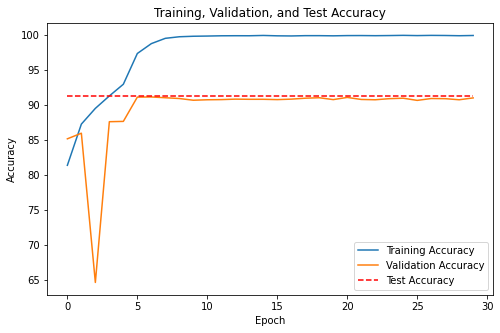

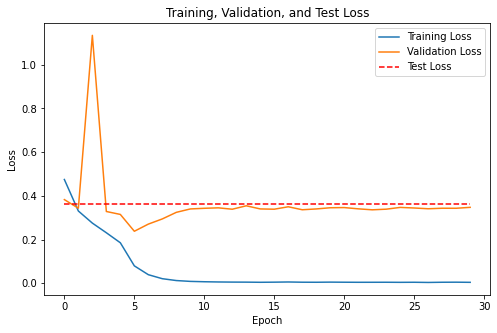

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_sgd_resnet, label='Training Accuracy')
plt.plot(validation_accuracy_sgd_resnet, label='Validation Accuracy')
plt.plot(test_accuracies_plot_sgd_resnet, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_sgd_resnet, label='Training Loss')
plt.plot(validation_loss_sgd_resnet, label='Validation Loss')
plt.plot(test_loss_plot_sgd_resnet, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

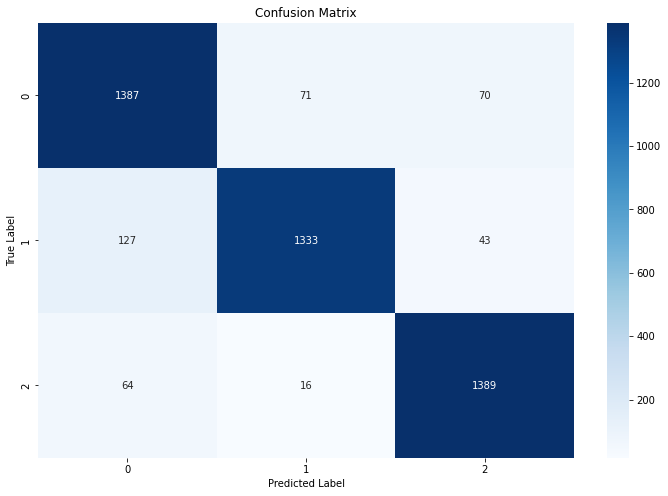

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_sgd_resnet, y_pred_sgd_resnet)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Using 'he' weight intialization with SGD

In [ ]:
model__sgd_he_resnet = ResNet18(num_classes=3).to(device)
model_weight_intialization(model__sgd_he_resnet,'he')

optimizer__sgd_he_resnet= torch.optim.SGD(model__sgd_he_resnet.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_step_lr__sgd_he_resnet = torch.optim.lr_scheduler.StepLR(optimizer__sgd_he_resnet, step_size=5, gamma=0.1)
loss_function__sgd_he_resnet = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss__sgd_he_resnet = float('inf')
best_epoch__sgd_he_resnet = 0
train_loss__sgd_he_resnet = []
validation_loss__sgd_he_resnet = []
train_accuracy__sgd_he_resnet = []
validation_accuracy__sgd_he_resnet = []

for epoch in range(epochs):
  model__sgd_he_resnet.train()

  start_time = time.time()

  loop_train_loss__sgd_he_resnet = 0
  correct_train_length__sgd_he_resnet = 0
  total_train__sgd_he_resnet = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer__sgd_he_resnet.zero_grad()

    outputs = model__sgd_he_resnet(inputs)

    loss = loss_function__sgd_he_resnet(outputs, labels)
    loss.backward()
    optimizer__sgd_he_resnet.step()

    _, predicted__sgd_he_resnet = torch.max(outputs, 1)
    total_train__sgd_he_resnet += labels.size(0)
    correct_train_length__sgd_he_resnet += (predicted__sgd_he_resnet == labels).sum().item()

    loop_train_loss__sgd_he_resnet += loss.item()

  scheduler_step_lr__sgd_he_resnet.step()

  #training accuracy and loss
  train_accuracy_value__sgd_he_resnet = 100 * correct_train_length__sgd_he_resnet / total_train__sgd_he_resnet
  train_loss__sgd_he_resnet.append(loop_train_loss__sgd_he_resnet / len(train_loader))
  train_accuracy__sgd_he_resnet.append(train_accuracy_value__sgd_he_resnet)

  #Validation
  model__sgd_he_resnet.eval()
  loop_val_loss__sgd_he_resnet = 0
  correct_val__sgd_he_resnet = 0
  total_val__sgd_he_resnet = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model__sgd_he_resnet(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function__sgd_he_resnet(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted__sgd_he_resnet = torch.max(val_outputs, 1)

      total_val__sgd_he_resnet += val_labels.size(0)
      correct_val__sgd_he_resnet += (predicted__sgd_he_resnet == val_labels).sum().item()

      loop_val_loss__sgd_he_resnet += val_loss.item()

  #validation accuracy and loss
  val_accuracy__sgd_he_resnet = 100 * correct_val__sgd_he_resnet / total_val__sgd_he_resnet
  validation_loss__sgd_he_resnet.append(loop_val_loss__sgd_he_resnet / len(val_loader))
  validation_accuracy__sgd_he_resnet.append(val_accuracy__sgd_he_resnet)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss__sgd_he_resnet[-1]:.4f}, Train Accuracy: {train_accuracy__sgd_he_resnet[-1]:.2f}%, "
    f"Val Loss: {validation_loss__sgd_he_resnet[-1]:.4f}, Val Accuracy: {validation_accuracy__sgd_he_resnet[-1]:.2f}%")

  end_time = time.time()
  training_time__sgd_he_resnet = end_time - start_time
  print(f"Training Time epoch {epoch+1}: {training_time__sgd_he_resnet:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss__sgd_he_resnet < best_validation_loss__sgd_he_resnet:
    best_validation_loss__sgd_he_resnet = loop_val_loss__sgd_he_resnet
    best_epoch__sgd_he_resnet = epoch + 1
    best_model_weight__sgd_he_resnet = model__sgd_he_resnet.state_dict()


if best_model_weight__sgd_he_resnet is not None:
  torch.save(best_model_weight__sgd_he_resnet, 'resnet_model__sgd_he_resnet.pt')



# Test phase
model__sgd_he_resnet.eval()
correct_test_length__sgd_he_resnet = 0
total_test__sgd_he_resnet = 0
y_true__sgd_he_resnet = []
y_pred__sgd_he_resnet = []

# test_loss = []
test_accuracy__sgd_he_resnet =[]
test_total_loss__sgd_he_resnet = 0.0
predicted_list__sgd_he_resnet = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model__sgd_he_resnet(inputs)

    labels = labels.view(-1)
    test_total_loss__sgd_he_resnet += loss_function__sgd_he_resnet(outputs, labels).item()

    _, predicted__sgd_he_resnet = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test__sgd_he_resnet += labels.size(0)
    correct_test_length__sgd_he_resnet += (predicted__sgd_he_resnet == labels).sum().item()

    y_true__sgd_he_resnet.extend(labels.cpu().numpy())
    y_pred__sgd_he_resnet.extend(predicted__sgd_he_resnet.cpu().numpy())
    predicted_list__sgd_he_resnet.extend(predicted_test_probs.cpu().numpy())


y_pred__sgd_he_resnet = np.array(y_pred__sgd_he_resnet)
y_true__sgd_he_resnet = np.array(y_true__sgd_he_resnet)
predicted_list__sgd_he_resnet = np.array(predicted_list__sgd_he_resnet)

test_accuracy__sgd_he_resnet = 100 * (correct_test_length__sgd_he_resnet / total_test__sgd_he_resnet)
print(f"Test Accuracy: {test_accuracy__sgd_he_resnet:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true__sgd_he_resnet, y_pred__sgd_he_resnet, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss__sgd_he_resnet = test_total_loss__sgd_he_resnet /len(test_loader)

test_accuracies_plot__sgd_he_resnet = [test_accuracy__sgd_he_resnet] * epochs
test_loss_plot__sgd_he_resnet = [test_loss__sgd_he_resnet] * epochs


Epoch [1/30], Train Loss: 0.4928, Train Accuracy: 81.41%, Val Loss: 0.3744, Val Accuracy: 85.71%
Training Time epoch 1: 8.22 seconds
Epoch [2/30], Train Loss: 0.3280, Train Accuracy: 87.73%, Val Loss: 0.4838, Val Accuracy: 82.22%
Training Time epoch 2: 8.23 seconds
Epoch [3/30], Train Loss: 0.2746, Train Accuracy: 89.70%, Val Loss: 0.3571, Val Accuracy: 85.69%
Training Time epoch 3: 8.25 seconds
Epoch [4/30], Train Loss: 0.2232, Train Accuracy: 91.48%, Val Loss: 0.3421, Val Accuracy: 87.22%
Training Time epoch 4: 8.25 seconds
Epoch [5/30], Train Loss: 0.1882, Train Accuracy: 92.93%, Val Loss: 0.3329, Val Accuracy: 88.02%
Training Time epoch 5: 8.25 seconds
Epoch [6/30], Train Loss: 0.0808, Train Accuracy: 97.28%, Val Loss: 0.2598, Val Accuracy: 90.78%
Training Time epoch 6: 8.25 seconds
Epoch [7/30], Train Loss: 0.0414, Train Accuracy: 98.74%, Val Loss: 0.2891, Val Accuracy: 90.82%
Training Time epoch 7: 8.25 seconds
Epoch [8/30], Train Loss: 0.0260, Train Accuracy: 99.31%, Val Loss: 0

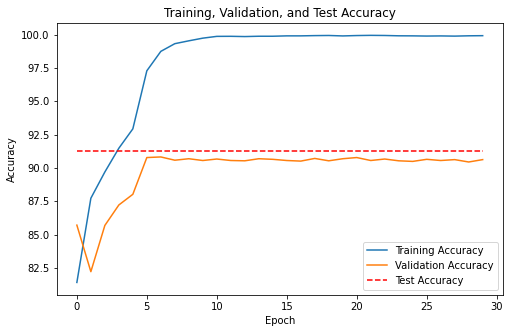

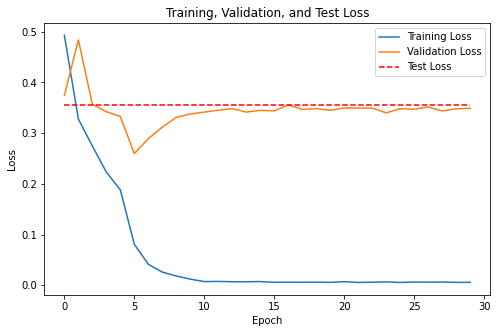

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy__sgd_he_resnet, label='Training Accuracy')
plt.plot(validation_accuracy__sgd_he_resnet, label='Validation Accuracy')
plt.plot(test_accuracies_plot__sgd_he_resnet, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss__sgd_he_resnet, label='Training Loss')
plt.plot(validation_loss__sgd_he_resnet, label='Validation Loss')
plt.plot(test_loss_plot__sgd_he_resnet, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

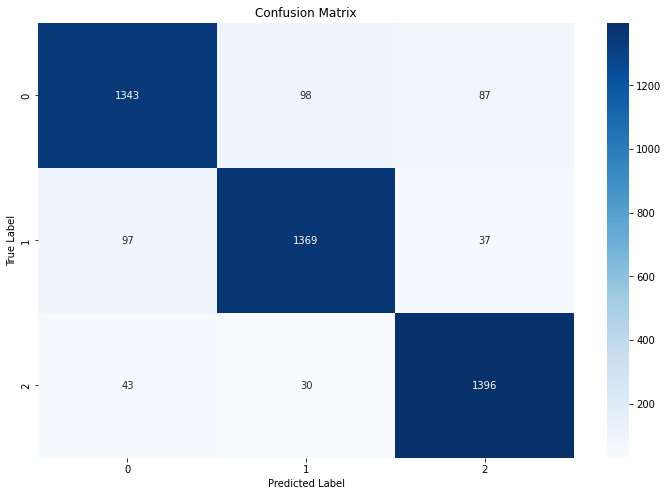

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true__sgd_he_resnet, y_pred__sgd_he_resnet)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Optimizer #2: Adam with Xavier weight intialization

In [24]:
model_adam_resnet_xavier = ResNet18(num_classes=3).to(device)
model_weight_intialization(model_adam_resnet_xavier,'xavier')
optimizer_adam_resnet_xavier = torch.optim.Adam(model_adam_resnet_xavier.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_adam_resnet_xavier = torch.optim.lr_scheduler.StepLR(optimizer_adam_resnet_xavier, step_size=5, gamma=0.1)
loss_function_adam_resnet_xavier = nn.CrossEntropyLoss()


epochs = 30

best_validation_loss_adam_resnet_xavier = float('inf')
best_epoch_adam_resnet_xavier = 0
train_loss_adam_resnet_xavier = []
validation_loss_adam_resnet_xavier = []
train_accuracy_adam_resnet_xavier = []
validation_accuracy_adam_resnet_xavier = []

for epoch in range(epochs):
  model_adam_resnet_xavier.train()

  start_time = time.time()

  loop_train_loss_adam_resnet_xavier = 0
  correct_train_length_adam_resnet_xavier = 0
  total_train_adam_resnet_xavier = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adam_resnet_xavier.zero_grad()

    outputs = model_adam_resnet_xavier(inputs)

    loss = loss_function_adam_resnet_xavier(outputs, labels)
    loss.backward()
    optimizer_adam_resnet_xavier.step()

    _, predicted_adam_resnet_xavier = torch.max(outputs, 1)
    total_train_adam_resnet_xavier += labels.size(0)
    correct_train_length_adam_resnet_xavier += (predicted_adam_resnet_xavier == labels).sum().item()

    loop_train_loss_adam_resnet_xavier += loss.item()

  scheduler_step_lr_adam_resnet_xavier.step()

  #training accuracy and loss
  train_accuracy_value_adam_resnet_xavier = 100 * correct_train_length_adam_resnet_xavier / total_train_adam_resnet_xavier
  train_loss_adam_resnet_xavier.append(loop_train_loss_adam_resnet_xavier / len(train_loader))
  train_accuracy_adam_resnet_xavier.append(train_accuracy_value_adam_resnet_xavier)

  #Validation
  model_adam_resnet_xavier.eval()
  loop_val_loss_adam_resnet_xavier = 0
  correct_val_adam_resnet_xavier = 0
  total_val_adam_resnet_xavier = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adam_resnet_xavier(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adam_resnet_xavier(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adam_resnet_xavier = torch.max(val_outputs, 1)

      total_val_adam_resnet_xavier += val_labels.size(0)
      correct_val_adam_resnet_xavier += (predicted_adam_resnet_xavier == val_labels).sum().item()

      loop_val_loss_adam_resnet_xavier += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adam_resnet_xavier = 100 * correct_val_adam_resnet_xavier / total_val_adam_resnet_xavier
  validation_loss_adam_resnet_xavier.append(loop_val_loss_adam_resnet_xavier / len(val_loader))
  validation_accuracy_adam_resnet_xavier.append(val_accuracy_adam_resnet_xavier)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adam_resnet_xavier[-1]:.4f}, Train Accuracy: {train_accuracy_adam_resnet_xavier[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adam_resnet_xavier[-1]:.4f}, Val Accuracy: {validation_accuracy_adam_resnet_xavier[-1]:.2f}%")

  end_time = time.time()
  training_time_adam_resnet_xavier = end_time - start_time
  print(f"Training Time epoch {epoch+1}: {training_time_adam_resnet_xavier:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adam_resnet_xavier < best_validation_loss_adam_resnet_xavier:
      best_validation_loss_adam_resnet_xavier = loop_val_loss_adam_resnet_xavier
      best_epoch_adam_resnet_xavier = epoch + 1
      best_model_weight_adam_resnet_xavier = model_adam_resnet_xavier.state_dict()


if best_model_weight_adam_resnet_xavier is not None:
    torch.save(best_model_weight_adam_resnet_xavier, 'resnet_model_adam_xavier.pt')


# Test phase
model_adam_resnet_xavier.eval()
correct_test_length_adam_resnet_xavier = 0
total_test_adam_resnet_xavier = 0
y_true_adam_resnet_xavier = []
y_pred_adam_resnet_xavier = []

# test_loss = []
test_accuracy_adam_resnet_xavier = []
test_total_loss_adam_resnet_xavier = 0.0
predicted_list_adam_resnet_xavier = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adam_resnet_xavier(inputs)

    labels = labels.view(-1)
    test_total_loss_adam_resnet_xavier += loss_function_adam_resnet_xavier(outputs, labels).item()

    _, predicted_adam_resnet_xavier = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adam_resnet_xavier += labels.size(0)
    correct_test_length_adam_resnet_xavier += (predicted_adam_resnet_xavier == labels).sum().item()

    y_true_adam_resnet_xavier.extend(labels.cpu().numpy())
    y_pred_adam_resnet_xavier.extend(predicted_adam_resnet_xavier.cpu().numpy())
    predicted_list_adam_resnet_xavier.extend(predicted_test_probs.cpu().numpy())


y_pred_adam_resnet_xavier = np.array(y_pred_adam_resnet_xavier)
y_true_adam_resnet_xavier = np.array(y_true_adam_resnet_xavier)
predicted_list_adam_resnet_xavier = np.array(predicted_list_adam_resnet_xavier)

test_accuracy_adam_resnet_xavier = 100 * (correct_test_length_adam_resnet_xavier / total_test_adam_resnet_xavier)
print(f"Test Accuracy: {test_accuracy_adam_resnet_xavier:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adam_resnet_xavier, y_pred_adam_resnet_xavier, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adam_resnet_xavier = test_total_loss_adam_resnet_xavier /len(test_loader)

test_accuracies_plot_adam_resnet_xavier = [test_accuracy_adam_resnet_xavier] * epochs
test_loss_plot_adam_resnet_xavier = [test_loss_adam_resnet_xavier] * epochs


Epoch [1/30], Train Loss: 0.5017, Train Accuracy: 80.17%, Val Loss: 0.4733, Val Accuracy: 80.76%
Training Time epoch 1: 17.26 seconds
Epoch [2/30], Train Loss: 0.3382, Train Accuracy: 87.01%, Val Loss: 0.3522, Val Accuracy: 86.29%
Training Time epoch 2: 17.04 seconds
Epoch [3/30], Train Loss: 0.2499, Train Accuracy: 90.46%, Val Loss: 0.3246, Val Accuracy: 87.93%
Training Time epoch 3: 17.02 seconds
Epoch [4/30], Train Loss: 0.1773, Train Accuracy: 93.40%, Val Loss: 0.3746, Val Accuracy: 86.96%
Training Time epoch 4: 17.07 seconds
Epoch [5/30], Train Loss: 0.1287, Train Accuracy: 95.14%, Val Loss: 0.3987, Val Accuracy: 87.80%
Training Time epoch 5: 17.07 seconds
Epoch [6/30], Train Loss: 0.0465, Train Accuracy: 98.47%, Val Loss: 0.3744, Val Accuracy: 88.84%
Training Time epoch 6: 17.03 seconds
Epoch [7/30], Train Loss: 0.0173, Train Accuracy: 99.64%, Val Loss: 0.4129, Val Accuracy: 89.13%
Training Time epoch 7: 17.06 seconds
Epoch [8/30], Train Loss: 0.0128, Train Accuracy: 99.80%, Val 

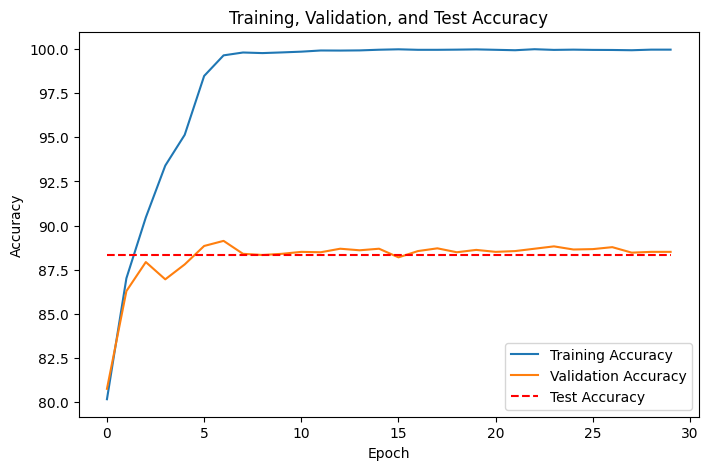

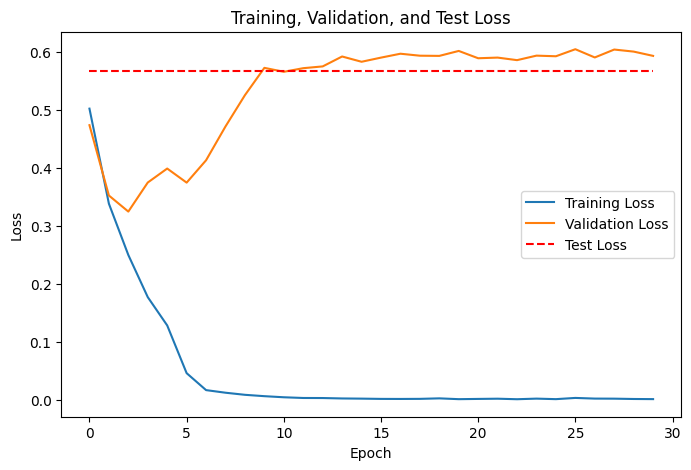

In [25]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adam_resnet_xavier, label='Training Accuracy')
plt.plot(validation_accuracy_adam_resnet_xavier, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adam_resnet_xavier, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adam_resnet_xavier, label='Training Loss')
plt.plot(validation_loss_adam_resnet_xavier, label='Validation Loss')
plt.plot(test_loss_plot_adam_resnet_xavier, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

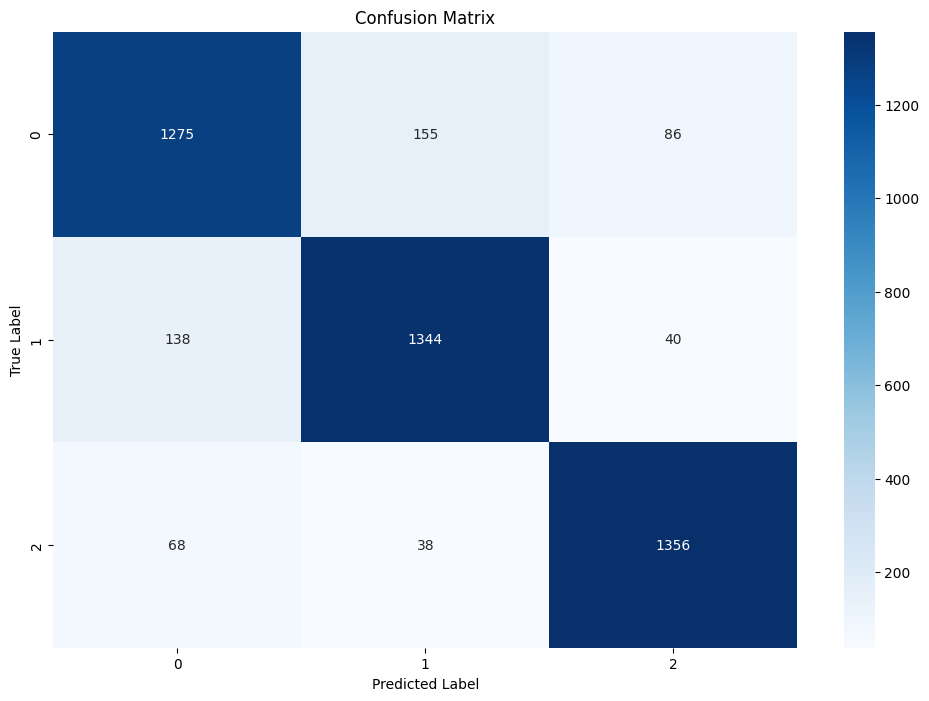

In [26]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adam_resnet_xavier, y_pred_adam_resnet_xavier)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Optimizer #2: Adam with he weight intialization

In [ ]:
model_adam_he = ResNet18(num_classes=3).to(device)
model_weight_intialization(model_adam_he,'he')
optimizer_adam_he = torch.optim.Adam(model_adam_he.parameters(), lr=0.0001)

scheduler_step_lr_adam_he = torch.optim.lr_scheduler.StepLR(optimizer_adam_he, step_size=5, gamma=0.1)
loss_function_adam_he = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss_adam_he = float('inf')
best_epoch_adam_he = 0
train_loss_adam_he = []
validation_loss_adam_he = []
train_accuracy_adam_he = []
validation_accuracy_adam_he = []

for epoch in range(epochs):
  model_adam_he.train()

  start_time = time.time()

  loop_train_loss_adam_he = 0
  correct_train_length_adam_he = 0
  total_train_adam_he = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adam_he.zero_grad()

    outputs = model_adam_he(inputs)

    loss = loss_function_adam_he(outputs, labels)
    loss.backward()
    optimizer_adam_he.step()

    _, predicted_adam_he = torch.max(outputs, 1)
    total_train_adam_he += labels.size(0)
    correct_train_length_adam_he += (predicted_adam_he == labels).sum().item()

    loop_train_loss_adam_he += loss.item()

  scheduler_step_lr_adam_he.step()

  #training accuracy and loss
  train_accuracy_value_adam_he = 100 * correct_train_length_adam_he / total_train_adam_he
  train_loss_adam_he.append(loop_train_loss_adam_he / len(train_loader))
  train_accuracy_adam_he.append(train_accuracy_value_adam_he)

  #Validation
  model_adam_he.eval()
  loop_val_loss_adam_he = 0
  correct_val_adam_he = 0
  total_val_adam_he = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adam_he(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adam_he(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adam_he = torch.max(val_outputs, 1)

      total_val_adam_he += val_labels.size(0)
      correct_val_adam_he += (predicted_adam_he == val_labels).sum().item()

      loop_val_loss_adam_he += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adam_he = 100 * correct_val_adam_he / total_val_adam_he
  validation_loss_adam_he.append(loop_val_loss_adam_he / len(val_loader))
  validation_accuracy_adam_he.append(val_accuracy_adam_he)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adam_he[-1]:.4f}, Train Accuracy: {train_accuracy_adam_he[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adam_he[-1]:.4f}, Val Accuracy: {validation_accuracy_adam_he[-1]:.2f}%")

  end_time = time.time()
  training_time_adam_he = end_time - start_time
  print(f"Training Time epoch {epoch+1}: {training_time_adam_he:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adam_he < best_validation_loss_adam_he:
    best_validation_loss_adam_he = loop_val_loss_adam_he
    best_epoch_adam_he = epoch + 1
    best_model_weight_adam_he = model_adam_he.state_dict()


if best_model_weight_adam_he is not None:
    torch.save(best_model_weight_adam_he, 'resnet_model_adam_he.pt')


# Test phase
model_adam_he.eval()
correct_test_length_adam_he = 0
total_test_adam_he = 0
y_true_adam_he = []
y_pred_adam_he = []

test_accuracy_adam_he =[]
test_total_loss_adam_he = 0.0
predicted_list_adam_he = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adam_he(inputs)

    labels = labels.view(-1)
    test_total_loss_adam_he += loss_function_adam_he(outputs, labels).item()

    _, predicted_adam_he = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adam_he += labels.size(0)
    correct_test_length_adam_he += (predicted_adam_he == labels).sum().item()

    y_true_adam_he.extend(labels.cpu().numpy())
    y_pred_adam_he.extend(predicted_adam_he.cpu().numpy())
    predicted_list_adam_he.extend(predicted_test_probs.cpu().numpy())


y_pred_adam_he = np.array(y_pred_adam_he)
y_true_adam_he = np.array(y_true_adam_he)
predicted_list_adam_he = np.array(predicted_list_adam_he)

test_accuracy_adam_he = 100 * (correct_test_length_adam_he / total_test_adam_he)
print(f"Test Accuracy: {test_accuracy_adam_he:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adam_he, y_pred_adam_he, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adam_he = test_total_loss_adam_he /len(test_loader)

test_accuracies_plot_adam_he = [test_accuracy_adam_he] * epochs
test_loss_plot_adam_he = [test_loss_adam_he] * epochs


Epoch [1/30], Train Loss: 0.5242, Train Accuracy: 79.05%, Val Loss: 0.4251, Val Accuracy: 83.56%
Training Time epoch 1: 9.97 seconds
Epoch [2/30], Train Loss: 0.3063, Train Accuracy: 88.32%, Val Loss: 0.3799, Val Accuracy: 85.47%
Training Time epoch 2: 9.96 seconds
Epoch [3/30], Train Loss: 0.2016, Train Accuracy: 92.60%, Val Loss: 0.4126, Val Accuracy: 84.78%
Training Time epoch 3: 10.25 seconds
Epoch [4/30], Train Loss: 0.1216, Train Accuracy: 95.52%, Val Loss: 0.4658, Val Accuracy: 85.18%
Training Time epoch 4: 10.00 seconds
Epoch [5/30], Train Loss: 0.0902, Train Accuracy: 96.52%, Val Loss: 0.5231, Val Accuracy: 85.11%
Training Time epoch 5: 10.02 seconds
Epoch [6/30], Train Loss: 0.0387, Train Accuracy: 98.76%, Val Loss: 0.4708, Val Accuracy: 87.04%
Training Time epoch 6: 9.98 seconds
Epoch [7/30], Train Loss: 0.0160, Train Accuracy: 99.62%, Val Loss: 0.5092, Val Accuracy: 87.00%
Training Time epoch 7: 9.99 seconds
Epoch [8/30], Train Loss: 0.0105, Train Accuracy: 99.75%, Val Loss

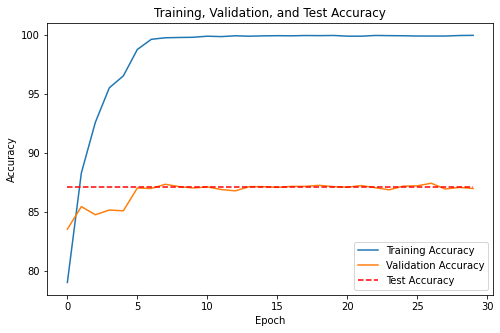

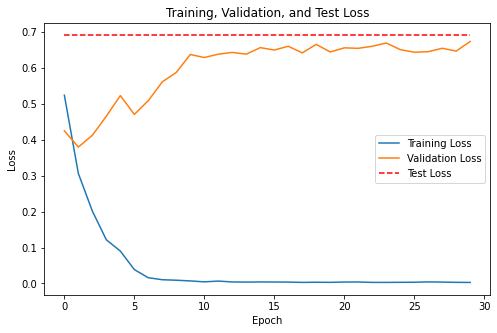

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adam_he, label='Training Accuracy')
plt.plot(validation_accuracy_adam_he, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adam_he, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adam_he, label='Training Loss')
plt.plot(validation_loss_adam_he, label='Validation Loss')
plt.plot(test_loss_plot_adam_he, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

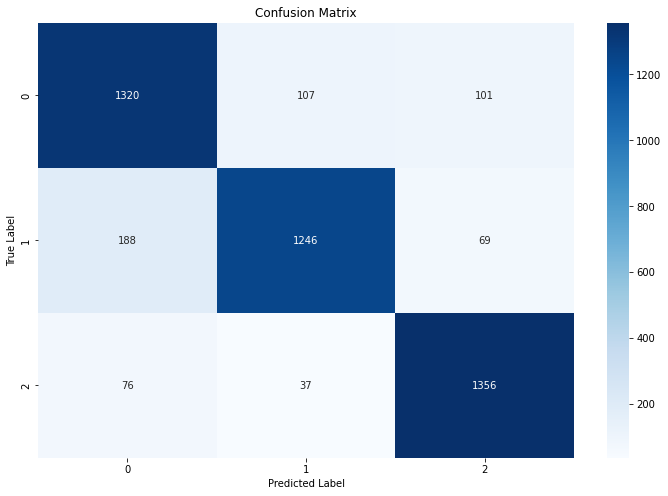

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adam_he, y_pred_adam_he)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Optimizer #3: Using AdamW with Xavier weight intialization

In [ ]:
model_adamW = ResNet18(num_classes=3).to(device)
model_weight_intialization(model_adamW, 'xavier')
optimizer_adamW = torch.optim.AdamW(model_adamW.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_adamW = torch.optim.lr_scheduler.StepLR(optimizer_adamW, step_size=5, gamma=0.1)
loss_function_adamW = nn.CrossEntropyLoss()


epochs = 30

best_validation_loss_adamW = float('inf')
best_epoch_adamW = 0
train_loss_adamW = []
validation_loss_adamW = []
train_accuracy_adamW = []
validation_accuracy_adamW = []

for epoch in range(epochs):
  model_adamW.train()

  start_time = time.time()

  loop_train_loss_adamW = 0
  correct_train_length_adamW = 0
  total_train_adamW = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adamW.zero_grad()

    outputs = model_adamW(inputs)

    loss = loss_function_adamW(outputs, labels)
    loss.backward()
    optimizer_adamW.step()

    _, predicted_adamW = torch.max(outputs, 1)
    total_train_adamW += labels.size(0)
    correct_train_length_adamW += (predicted_adamW == labels).sum().item()

    loop_train_loss_adamW += loss.item()

  scheduler_step_lr_adamW.step()

  #training accuracy and loss
  train_accuracy_value_adamW = 100 * correct_train_length_adamW / total_train_adamW
  train_loss_adamW.append(loop_train_loss_adamW / len(train_loader))
  train_accuracy_adamW.append(train_accuracy_value_adamW)

  #Validation
  model_adamW.eval()
  loop_val_loss_adamW = 0
  correct_val_adamW = 0
  total_val_adamW = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adamW(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adamW(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adamW = torch.max(val_outputs, 1)

      total_val_adamW += val_labels.size(0)
      correct_val_adamW += (predicted_adamW == val_labels).sum().item()

      loop_val_loss_adamW += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adamW = 100 * correct_val_adamW / total_val_adamW
  validation_loss_adamW.append(loop_val_loss_adamW / len(val_loader))
  validation_accuracy_adamW.append(val_accuracy_adamW)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adamW[-1]:.4f}, Train Accuracy: {train_accuracy_adamW[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adamW[-1]:.4f}, Val Accuracy: {validation_accuracy_adamW[-1]:.2f}%")

  end_time = time.time()
  training_time_adamW = end_time - start_time
  print(f"Training Time: {training_time_adamW:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adamW < best_validation_loss_adamW:
    best_validation_loss_adamW = loop_val_loss_adamW
    best_epoch_adamW = epoch + 1
    best_model_weight_adamW = model_adamW.state_dict()


if best_model_weight_adamW is not None:
  torch.save(best_model_weight_adamW, 'resnet_model_adamW.pt')


# Test phase
model_adamW.eval()
correct_test_length_adamW = 0
total_test_adamW = 0
y_true_adamW = []
y_pred_adamW = []

# test_loss = []
test_accuracy_adamW =[]
test_total_loss_adamW = 0.0
predicted_list_adamW = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adamW(inputs)

    labels = labels.view(-1)
    test_total_loss_adamW += loss_function_adamW(outputs, labels).item()

    _, predicted_adamW = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adamW += labels.size(0)
    correct_test_length_adamW += (predicted_adamW == labels).sum().item()

    y_true_adamW.extend(labels.cpu().numpy())
    y_pred_adamW.extend(predicted_adamW.cpu().numpy())
    predicted_list_adamW.extend(predicted_test_probs.cpu().numpy())


y_pred_adamW = np.array(y_pred_adamW)
y_true_adamW = np.array(y_true_adamW)
predicted_list_adamW = np.array(predicted_list_adamW)

test_accuracy_adamW = 100 * (correct_test_length_adamW / total_test_adamW)
print(f"Test Accuracy: {test_accuracy_adamW:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adamW, y_pred_adamW, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adamW = test_total_loss_adamW /len(test_loader)

test_accuracies_plot_adamW = [test_accuracy_adamW] * epochs
test_loss_plot_adamW = [test_loss_adamW] * epochs


Epoch [1/30], Train Loss: 0.4935, Train Accuracy: 80.32%, Val Loss: 0.3923, Val Accuracy: 84.89%
Training Time: 10.22 seconds
Epoch [2/30], Train Loss: 0.3174, Train Accuracy: 87.80%, Val Loss: 0.5035, Val Accuracy: 82.36%
Training Time: 10.27 seconds
Epoch [3/30], Train Loss: 0.2462, Train Accuracy: 90.48%, Val Loss: 0.3830, Val Accuracy: 85.76%
Training Time: 10.29 seconds
Epoch [4/30], Train Loss: 0.1734, Train Accuracy: 93.50%, Val Loss: 0.6007, Val Accuracy: 81.84%
Training Time: 10.31 seconds
Epoch [5/30], Train Loss: 0.1227, Train Accuracy: 95.40%, Val Loss: 0.5433, Val Accuracy: 84.00%
Training Time: 10.30 seconds
Epoch [6/30], Train Loss: 0.0410, Train Accuracy: 98.75%, Val Loss: 0.3847, Val Accuracy: 88.27%
Training Time: 10.30 seconds
Epoch [7/30], Train Loss: 0.0204, Train Accuracy: 99.52%, Val Loss: 0.4220, Val Accuracy: 88.29%
Training Time: 10.29 seconds
Epoch [8/30], Train Loss: 0.0121, Train Accuracy: 99.75%, Val Loss: 0.4684, Val Accuracy: 88.13%
Training Time: 10.25 

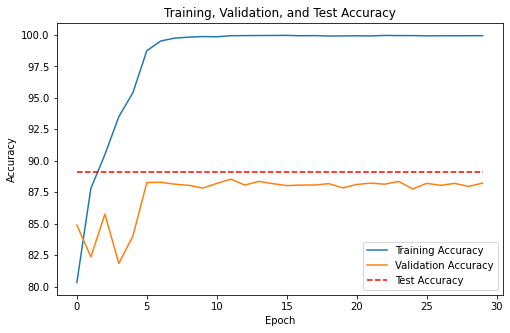

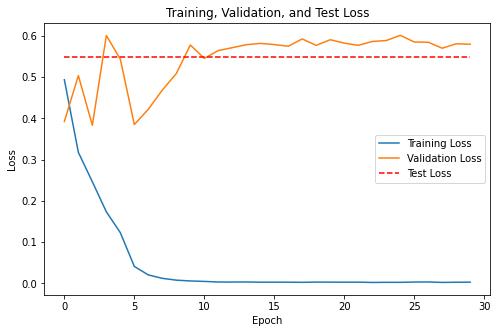

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adamW, label='Training Accuracy')
plt.plot(validation_accuracy_adamW, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adamW, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adamW, label='Training Loss')
plt.plot(validation_loss_adamW, label='Validation Loss')
plt.plot(test_loss_plot_adamW, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

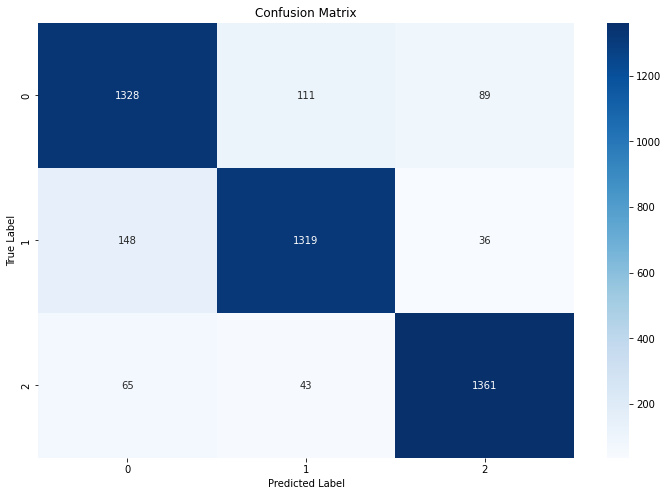

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adamW, y_pred_adamW)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Optimizer #3: Using AdamW with 'he' weight intialization

In [ ]:
model_adamW_he = ResNet18(num_classes=3).to(device)
model_weight_intialization(model_adamW_he,'he')
optimizer_adamW_he = torch.optim.AdamW(model_adamW_he.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_adamW_he = torch.optim.lr_scheduler.StepLR(optimizer_adamW_he, step_size=5, gamma=0.1)
loss_function_adamW_he = nn.CrossEntropyLoss()



epochs = 30

best_validation_loss_adamW_he = float('inf')
best_epoch_adamW_he = 0
train_loss_adamW_he = []
validation_loss_adamW_he = []
train_accuracy_adamW_he = []
validation_accuracy_adamW_he = []

for epoch in range(epochs):
  model_adamW_he.train()

  start_time = time.time()

  loop_train_loss_adamW_he = 0
  correct_train_length_adamW_he = 0
  total_train_adamW_he = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adamW_he.zero_grad()

    outputs = model_adamW_he(inputs)

    loss = loss_function_adamW_he(outputs, labels)
    loss.backward()
    optimizer_adamW_he.step()

    _, predicted_adamW_he = torch.max(outputs, 1)
    total_train_adamW_he += labels.size(0)
    correct_train_length_adamW_he += (predicted_adamW_he == labels).sum().item()

    loop_train_loss_adamW_he += loss.item()

  scheduler_step_lr_adamW_he.step()

  #training accuracy and loss
  train_accuracy_value_adamW_he = 100 * correct_train_length_adamW_he / total_train_adamW_he
  train_loss_adamW_he.append(loop_train_loss_adamW_he / len(train_loader))
  train_accuracy_adamW_he.append(train_accuracy_value_adamW_he)

  #Validation
  model_adamW_he.eval()
  loop_val_loss_adamW_he = 0
  correct_val_adamW_he = 0
  total_val_adamW_he = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_adamW_he(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_adamW_he(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_adamW_he = torch.max(val_outputs, 1)

      total_val_adamW_he += val_labels.size(0)
      correct_val_adamW_he += (predicted_adamW_he == val_labels).sum().item()

      loop_val_loss_adamW_he += val_loss.item()

  #validation accuracy and loss
  val_accuracy_adamW_he = 100 * correct_val_adamW_he / total_val_adamW_he
  validation_loss_adamW_he.append(loop_val_loss_adamW_he / len(val_loader))
  validation_accuracy_adamW_he.append(val_accuracy_adamW_he)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adamW_he[-1]:.4f}, Train Accuracy: {train_accuracy_adamW_he[-1]:.2f}%, "
    f"Val Loss: {validation_loss_adamW_he[-1]:.4f}, Val Accuracy: {validation_accuracy_adamW_he[-1]:.2f}%")

  end_time = time.time()
  training_time_adamW_he = end_time - start_time
  print(f"Training Time {epoch+1}: {training_time_adamW_he:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_adamW_he < best_validation_loss_adamW_he:
    best_validation_loss_adamW_he = loop_val_loss_adamW_he
    best_epoch_adamW_he = epoch + 1
    best_model_weight_adamW_he = model_adamW_he.state_dict()


if best_model_weight_adamW_he is not None:
    torch.save(best_model_weight_adamW_he, 'resnet_model_adamW_he.pt')


# Test phase
model_adamW_he.eval()
correct_test_length_adamW_he = 0
total_test_adamW_he = 0
y_true_adamW_he = []
y_pred_adamW_he = []

# test_loss = []
test_accuracy_adamW_he =[]
test_total_loss_adamW_he = 0.0
predicted_list_adamW_he = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_adamW_he(inputs)

    labels = labels.view(-1)
    test_total_loss_adamW_he += loss_function_adamW_he(outputs, labels).item()

    _, predicted_adamW_he = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_adamW_he += labels.size(0)
    correct_test_length_adamW_he += (predicted_adamW_he == labels).sum().item()

    y_true_adamW_he.extend(labels.cpu().numpy())
    y_pred_adamW_he.extend(predicted_adamW_he.cpu().numpy())
    predicted_list_adamW_he.extend(predicted_test_probs.cpu().numpy())


y_pred_adamW_he = np.array(y_pred_adamW_he)
y_true_adamW_he = np.array(y_true_adamW_he)
predicted_list_adamW_he = np.array(predicted_list_adamW_he)

test_accuracy_adamW_he = 100 * (correct_test_length_adamW_he / total_test_adamW_he)
print(f"Test Accuracy: {test_accuracy_adamW_he:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_adamW_he, y_pred_adamW_he, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_adamW_he = test_total_loss_adamW_he /len(test_loader)

test_accuracies_plot_adamW_he = [test_accuracy_adamW_he] * epochs
test_loss_plot_adamW_he = [test_loss_adamW_he] * epochs


Epoch [1/30], Train Loss: 0.5147, Train Accuracy: 79.58%, Val Loss: 0.4115, Val Accuracy: 83.71%
Training Time 1: 10.25 seconds
Epoch [2/30], Train Loss: 0.3065, Train Accuracy: 88.14%, Val Loss: 0.4042, Val Accuracy: 84.13%
Training Time 2: 10.59 seconds
Epoch [3/30], Train Loss: 0.1978, Train Accuracy: 92.51%, Val Loss: 0.4100, Val Accuracy: 84.98%
Training Time 3: 10.27 seconds
Epoch [4/30], Train Loss: 0.1285, Train Accuracy: 95.32%, Val Loss: 0.4529, Val Accuracy: 85.47%
Training Time 4: 10.28 seconds
Epoch [5/30], Train Loss: 0.0922, Train Accuracy: 96.68%, Val Loss: 0.5232, Val Accuracy: 85.07%
Training Time 5: 10.27 seconds
Epoch [6/30], Train Loss: 0.0378, Train Accuracy: 98.82%, Val Loss: 0.5056, Val Accuracy: 86.02%
Training Time 6: 10.27 seconds
Epoch [7/30], Train Loss: 0.0173, Train Accuracy: 99.52%, Val Loss: 0.5280, Val Accuracy: 86.42%
Training Time 7: 10.27 seconds
Epoch [8/30], Train Loss: 0.0105, Train Accuracy: 99.78%, Val Loss: 0.5934, Val Accuracy: 86.40%
Trainin

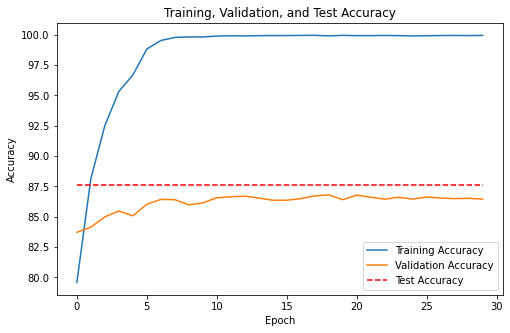

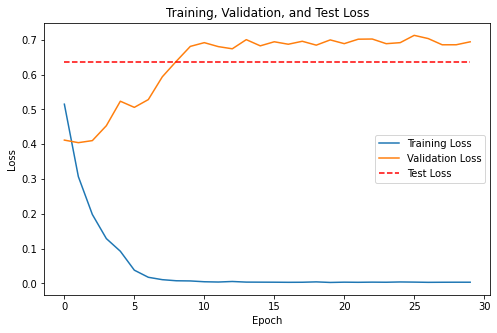

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_adamW_he, label='Training Accuracy')
plt.plot(validation_accuracy_adamW_he, label='Validation Accuracy')
plt.plot(test_accuracies_plot_adamW_he, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_adamW_he, label='Training Loss')
plt.plot(validation_loss_adamW_he, label='Validation Loss')
plt.plot(test_loss_plot_adamW_he, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

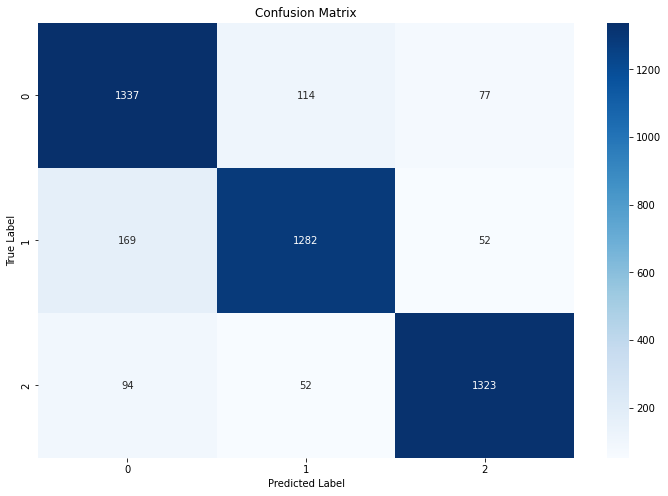

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_adamW_he, y_pred_adamW_he)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**For Resnet architecture based on the models trained the best model so far is the one with SGD optimizer with 'Xavier' along with using StepLR learning rate scheduler and uses batch size of 32.Changing the batch size to 64 using the best model from above. Here again we see that accuracy goes down but the training time decreases**

In [ ]:
#batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

model_batchsize_resnet = ResNet18(num_classes=3).to(device)

model_weight_intialization(model_batchsize_resnet,'xavier')
optimizer_batchsize_resnet = torch.optim.SGD(model_batchsize_resnet.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler_step_lr_batchsize_resnet = torch.optim.lr_scheduler.StepLR(optimizer_batchsize_resnet, step_size=5, gamma=0.1)
loss_function_batchsize_resnet = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss_batchsize_resnet = float('inf')
best_epoch_batchsize_resnet = 0
train_loss_batchsize_resnet = []
validation_loss_batchsize_resnet = []
train_accuracy_batchsize_resnet = []
validation_accuracy_batchsize_resnet = []

for epoch in range(epochs):
  model_batchsize_resnet.train()

  start_time = time.time()

  loop_train_loss_batchsize_resnet = 0
  correct_train_length_batchsize_resnet = 0
  total_train_batchsize_resnet = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_batchsize_resnet.zero_grad()

    outputs = model_batchsize_resnet(inputs)

    loss = loss_function_batchsize_resnet(outputs, labels)
    loss.backward()
    optimizer_batchsize_resnet.step()

    _, predicted_batchsize_resnet = torch.max(outputs, 1)
    total_train_batchsize_resnet += labels.size(0)
    correct_train_length_batchsize_resnet += (predicted_batchsize_resnet == labels).sum().item()

    loop_train_loss_batchsize_resnet += loss.item()

  scheduler_step_lr_batchsize_resnet.step()

  #training accuracy and loss
  train_accuracy_value_batchsize_resnet = 100 * correct_train_length_batchsize_resnet / total_train_batchsize_resnet
  train_loss_batchsize_resnet.append(loop_train_loss_batchsize_resnet / len(train_loader))
  train_accuracy_batchsize_resnet.append(train_accuracy_value_batchsize_resnet)

  #Validation
  model_batchsize_resnet.eval()
  loop_val_loss_batchsize_resnet = 0
  correct_val_batchsize_resnet = 0
  total_val_batchsize_resnet = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_batchsize_resnet(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_batchsize_resnet(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_batchsize_resnet = torch.max(val_outputs, 1)

      total_val_batchsize_resnet += val_labels.size(0)
      correct_val_batchsize_resnet += (predicted_batchsize_resnet == val_labels).sum().item()

      loop_val_loss_batchsize_resnet += val_loss.item()

  #validation accuracy and loss
  val_accuracy_batchsize_resnet = 100 * correct_val_batchsize_resnet / total_val_batchsize_resnet
  validation_loss_batchsize_resnet.append(loop_val_loss_batchsize_resnet / len(val_loader))
  validation_accuracy_batchsize_resnet.append(val_accuracy_batchsize_resnet)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_batchsize_resnet[-1]:.4f}, Train Accuracy: {train_accuracy_batchsize_resnet[-1]:.2f}%, "
    f"Val Loss: {validation_loss_batchsize_resnet[-1]:.4f}, Val Accuracy: {validation_accuracy_batchsize_resnet[-1]:.2f}%")

  end_time = time.time()
  training_time_batchsize_resnet = end_time - start_time
  print(f"Training Time: {training_time_batchsize_resnet:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_batchsize_resnet < best_validation_loss_batchsize_resnet:
    best_validation_loss_batchsize_resnet = loop_val_loss_batchsize_resnet
    best_epoch_batchsize_resnet = epoch + 1
    best_model_weight_batchsize_resnet = model_batchsize_resnet.state_dict()


if best_model_weight_batchsize_resnet is not None:
  torch.save(best_model_weight_batchsize_resnet, 'resnet_model_batchsize_resnet.pt')


# Test phase
model_batchsize_resnet.eval()
correct_test_length_batchsize_resnet = 0
total_test_batchsize_resnet = 0
y_true_batchsize_resnet = []
y_pred_batchsize_resnet = []

# test_loss = []
test_accuracy_batchsize_resnet =[]
test_total_loss_batchsize_resnet = 0.0
predicted_list_batchsize_resnet = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_batchsize_resnet(inputs)

    labels = labels.view(-1)
    test_total_loss_batchsize_resnet += loss_function_batchsize_resnet(outputs, labels).item()

    _, predicted_batchsize_resnet = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_batchsize_resnet += labels.size(0)
    correct_test_length_batchsize_resnet += (predicted_batchsize_resnet == labels).sum().item()

    y_true_batchsize_resnet.extend(labels.cpu().numpy())
    y_pred_batchsize_resnet.extend(predicted_batchsize_resnet.cpu().numpy())
    predicted_list_batchsize_resnet.extend(predicted_test_probs.cpu().numpy())


y_pred_batchsize_resnet = np.array(y_pred_batchsize_resnet)
y_true_batchsize_resnet = np.array(y_true_batchsize_resnet)
predicted_list_batchsize_resnet = np.array(predicted_list_batchsize_resnet)

test_accuracy_batchsize_resnet = 100 * (correct_test_length_batchsize_resnet / total_test_batchsize_resnet)
print(f"Test Accuracy: {test_accuracy_batchsize_resnet:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_batchsize_resnet, y_pred_batchsize_resnet, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_batchsize_resnet = test_total_loss_batchsize_resnet /len(test_loader)

test_accuracies_plot_batchsize_resnet = [test_accuracy_batchsize_resnet] * epochs
test_loss_plot_batchsize_resnet = [test_loss_batchsize_resnet] * epochs

Epoch [1/30], Train Loss: 0.5181, Train Accuracy: 80.60%, Val Loss: 0.3670, Val Accuracy: 86.18%
Training Time: 5.46 seconds
Epoch [2/30], Train Loss: 0.3449, Train Accuracy: 86.95%, Val Loss: 0.3694, Val Accuracy: 86.18%
Training Time: 5.00 seconds
Epoch [3/30], Train Loss: 0.2929, Train Accuracy: 88.78%, Val Loss: 0.2863, Val Accuracy: 89.47%
Training Time: 4.95 seconds
Epoch [4/30], Train Loss: 0.2382, Train Accuracy: 90.93%, Val Loss: 0.3458, Val Accuracy: 87.11%
Training Time: 4.96 seconds
Epoch [5/30], Train Loss: 0.1936, Train Accuracy: 92.72%, Val Loss: 0.9552, Val Accuracy: 70.82%
Training Time: 4.98 seconds
Epoch [6/30], Train Loss: 0.0909, Train Accuracy: 96.88%, Val Loss: 0.2652, Val Accuracy: 90.73%
Training Time: 4.99 seconds
Epoch [7/30], Train Loss: 0.0503, Train Accuracy: 98.43%, Val Loss: 0.3057, Val Accuracy: 90.47%
Training Time: 4.97 seconds
Epoch [8/30], Train Loss: 0.0292, Train Accuracy: 99.23%, Val Loss: 0.3255, Val Accuracy: 90.04%
Training Time: 4.97 seconds


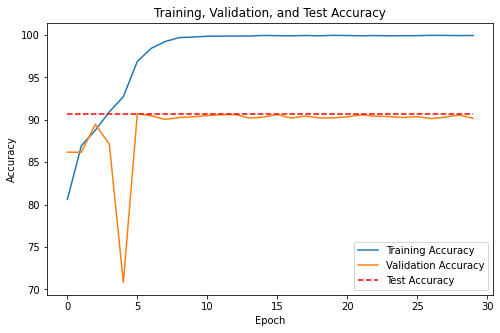

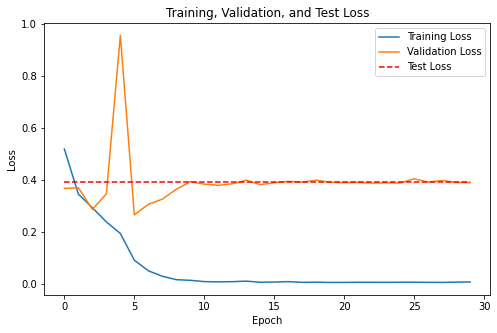

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_batchsize_resnet, label='Training Accuracy')
plt.plot(validation_accuracy_batchsize_resnet, label='Validation Accuracy')
plt.plot(test_accuracies_plot_batchsize_resnet, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_batchsize_resnet, label='Training Loss')
plt.plot(validation_loss_batchsize_resnet, label='Validation Loss')
plt.plot(test_loss_plot_batchsize_resnet, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

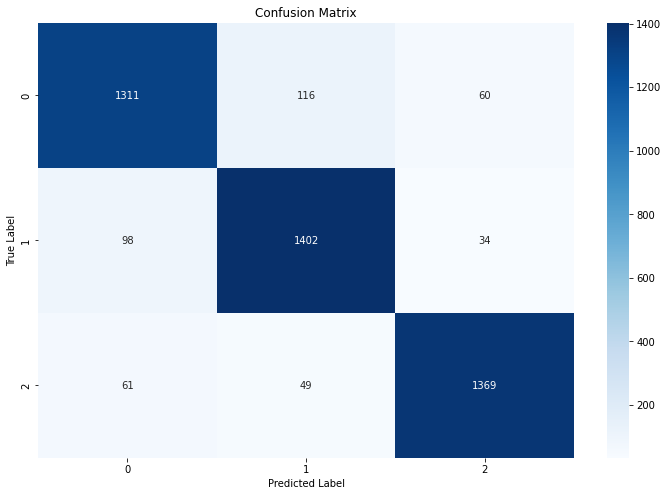

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_batchsize_resnet, y_pred_batchsize_resnet)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

4. Apply regularization techniques.

Technique #1: Early Stopping

In [27]:
### ADD YOUR CODE HERE ###
#batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

model_early_stopping_resnet = ResNet18(num_classes=3).to(device)

model_weight_intialization(model_early_stopping_resnet,'xavier')
optimizer_early_stopping_resnet = torch.optim.SGD(model_early_stopping_resnet.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler_step_lr_early_stopping_resnet = torch.optim.lr_scheduler.StepLR(optimizer_early_stopping_resnet, step_size=5, gamma=0.1)
loss_function_early_stopping_resnet = nn.CrossEntropyLoss()

epochs = 30
counter = 0
patience_value = 3

best_validation_loss_early_stopping_resnet = float('inf')
best_epoch_early_stopping_resnet = 0
train_loss_early_stopping_resnet = []
validation_loss_early_stopping_resnet = []
train_accuracy_early_stopping_resnet = []
validation_accuracy_early_stopping_resnet = []

for epoch in range(epochs):
  model_early_stopping_resnet.train()

  start_time = time.time()

  loop_train_loss_early_stopping_resnet = 0
  correct_train_length_early_stopping_resnet = 0
  total_train_early_stopping_resnet = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_early_stopping_resnet.zero_grad()

    outputs = model_early_stopping_resnet(inputs)

    loss = loss_function_early_stopping_resnet(outputs, labels)
    loss.backward()
    optimizer_early_stopping_resnet.step()

    _, predicted_early_stopping_resnet = torch.max(outputs, 1)
    total_train_early_stopping_resnet += labels.size(0)
    correct_train_length_early_stopping_resnet += (predicted_early_stopping_resnet == labels).sum().item()

    loop_train_loss_early_stopping_resnet += loss.item()

  scheduler_step_lr_early_stopping_resnet.step()

  #training accuracy and loss
  train_accuracy_value_early_stopping_resnet = 100 * correct_train_length_early_stopping_resnet / total_train_early_stopping_resnet
  train_loss_early_stopping_resnet.append(loop_train_loss_early_stopping_resnet / len(train_loader))
  train_accuracy_early_stopping_resnet.append(train_accuracy_value_early_stopping_resnet)

  #Validation
  model_early_stopping_resnet.eval()
  loop_val_loss_early_stopping_resnet = 0
  correct_val_early_stopping_resnet = 0
  total_val_early_stopping_resnet = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_early_stopping_resnet(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_early_stopping_resnet(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_early_stopping_resnet = torch.max(val_outputs, 1)

      total_val_early_stopping_resnet += val_labels.size(0)
      correct_val_early_stopping_resnet += (predicted_early_stopping_resnet == val_labels).sum().item()

      loop_val_loss_early_stopping_resnet += val_loss.item()

  #validation accuracy and loss
  val_accuracy_early_stopping_resnet = 100 * correct_val_early_stopping_resnet / total_val_early_stopping_resnet
  validation_loss_early_stopping_resnet.append(loop_val_loss_early_stopping_resnet / len(val_loader))
  validation_accuracy_early_stopping_resnet.append(val_accuracy_early_stopping_resnet)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_early_stopping_resnet[-1]:.4f}, Train Accuracy: {train_accuracy_early_stopping_resnet[-1]:.2f}%, "
    f"Val Loss: {validation_loss_early_stopping_resnet[-1]:.4f}, Val Accuracy: {validation_accuracy_early_stopping_resnet[-1]:.2f}%")

  end_time = time.time()
  training_time_early_stopping_resnet = end_time - start_time
  print(f"Training Time: {training_time_early_stopping_resnet:.2f} seconds")

  if loop_val_loss_early_stopping_resnet < best_validation_loss_early_stopping_resnet:
    best_validation_loss_early_stopping_resnet = loop_val_loss_early_stopping_resnet
    best_epoch_early_stopping_resnet = epoch + 1
    best_model_weight_early_stopping_resnet = model_early_stopping_resnet.state_dict()
    counter = 0
  else:
      counter += 1
      if counter >= patience_value:
          print(f"Early stopping at epoch {epoch + 1} having validation loss: {validation_loss_early_stopping_resnet[-1]:.4f}")
          break


if best_model_weight_early_stopping_resnet is not None:
  torch.save(best_model_weight_early_stopping_resnet, 'resnet_model_early_stopping_resnet.pt')


# Test phase
model_early_stopping_resnet.eval()
correct_test_length_early_stopping_resnet = 0
total_test_early_stopping_resnet = 0
y_true_early_stopping_resnet = []
y_pred_early_stopping_resnet = []

# test_loss = []
test_accuracy_early_stopping_resnet =[]
test_total_loss_early_stopping_resnet = 0.0
avg_test_accuracy_early_stopping_resnet = 0
test_epoch_accuracy_early_stopping_resnet = 0
predicted_list_early_stopping_resnet = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_early_stopping_resnet(inputs)

    labels = labels.view(-1)
    test_total_loss_early_stopping_resnet += loss_function_early_stopping_resnet(outputs, labels).item()

    _, predicted_early_stopping_resnet = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_early_stopping_resnet += labels.size(0)
    correct_test_length_early_stopping_resnet += (predicted_early_stopping_resnet == labels).sum().item()

    y_true_early_stopping_resnet.extend(labels.cpu().numpy())
    y_pred_early_stopping_resnet.extend(predicted_early_stopping_resnet.cpu().numpy())
    predicted_list_early_stopping_resnet.extend(predicted_test_probs.cpu().numpy())


y_pred_early_stopping_resnet = np.array(y_pred_early_stopping_resnet)
y_true_early_stopping_resnet = np.array(y_true_early_stopping_resnet)
predicted_list_early_stopping_resnet = np.array(predicted_list_early_stopping_resnet)

test_accuracy_early_stopping_resnet = 100 * (correct_test_length_early_stopping_resnet / total_test_early_stopping_resnet)
print(f"Test Accuracy: {test_accuracy_early_stopping_resnet:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_early_stopping_resnet, y_pred_early_stopping_resnet, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_early_stopping_resnet = test_total_loss_early_stopping_resnet /len(test_loader)

test_accuracies_plot_early_stopping_resnet = [test_accuracy_early_stopping_resnet] * epochs
test_loss_plot_early_stopping_resnet = [test_loss_early_stopping_resnet] * epochs


Epoch [1/30], Train Loss: 0.5114, Train Accuracy: 80.25%, Val Loss: 0.6466, Val Accuracy: 77.00%
Training Time: 7.88 seconds
Epoch [2/30], Train Loss: 0.3536, Train Accuracy: 86.31%, Val Loss: 0.3448, Val Accuracy: 87.16%
Training Time: 7.87 seconds
Epoch [3/30], Train Loss: 0.3025, Train Accuracy: 88.52%, Val Loss: 0.4233, Val Accuracy: 83.27%
Training Time: 7.86 seconds
Epoch [4/30], Train Loss: 0.2568, Train Accuracy: 90.16%, Val Loss: 0.2921, Val Accuracy: 88.89%
Training Time: 7.84 seconds
Epoch [5/30], Train Loss: 0.2106, Train Accuracy: 91.95%, Val Loss: 0.4306, Val Accuracy: 84.78%
Training Time: 7.83 seconds
Epoch [6/30], Train Loss: 0.0951, Train Accuracy: 96.73%, Val Loss: 0.2682, Val Accuracy: 91.07%
Training Time: 7.85 seconds
Epoch [7/30], Train Loss: 0.0531, Train Accuracy: 98.52%, Val Loss: 0.2876, Val Accuracy: 90.96%
Training Time: 7.87 seconds
Epoch [8/30], Train Loss: 0.0346, Train Accuracy: 99.00%, Val Loss: 0.3223, Val Accuracy: 90.60%
Training Time: 7.84 seconds


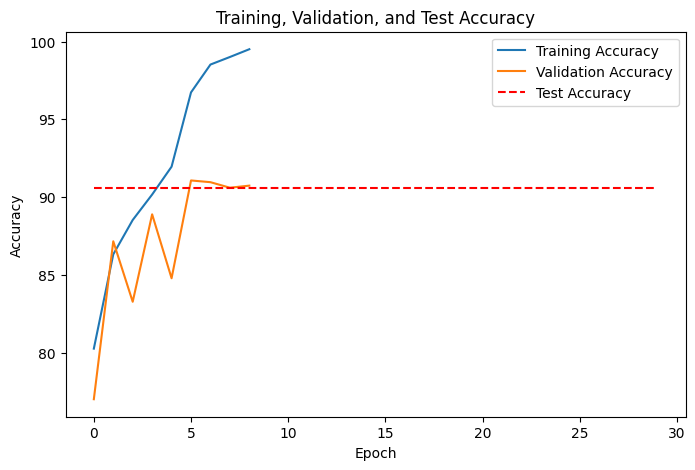

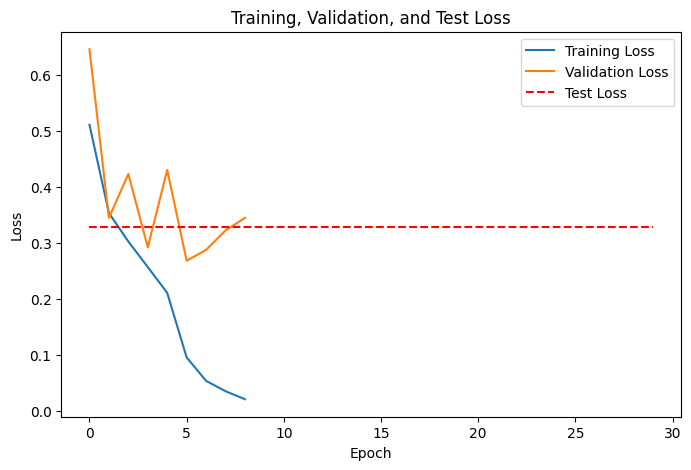

In [28]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_early_stopping_resnet, label='Training Accuracy')
plt.plot(validation_accuracy_early_stopping_resnet, label='Validation Accuracy')
plt.plot(test_accuracies_plot_early_stopping_resnet, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_early_stopping_resnet, label='Training Loss')
plt.plot(validation_loss_early_stopping_resnet, label='Validation Loss')
plt.plot(test_loss_plot_early_stopping_resnet, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

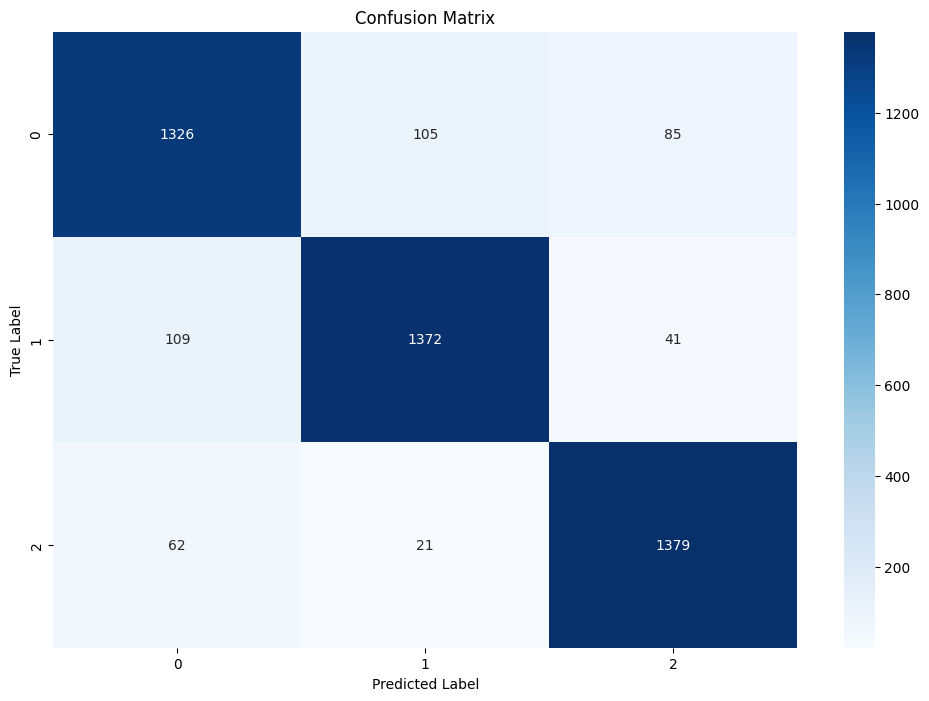

In [29]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_early_stopping_resnet, y_pred_early_stopping_resnet)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Technique #2: Changing the L2 regularization for SGD optimizer with Xavier intializaition

In [ ]:

# #batch size
# batch_size = 64

# # Create DataLoaders
# train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
# val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
# test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

model_L2 = ResNet18(num_classes=3).to(device)
model_weight_intialization(model_L2,'xavier')
optimizer_L2 = torch.optim.SGD(model_L2.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler_step_lr_L2 = torch.optim.lr_scheduler.StepLR(optimizer_L2, step_size=5, gamma=0.1)
loss_function_L2 = nn.CrossEntropyLoss()

epochs = 30

best_validation_loss_L2 = float('inf')
best_epoch_L2 = 0
train_loss_L2 = []
validation_loss_L2 = []
train_accuracy_L2 = []
validation_accuracy_L2 = []

for epoch in range(epochs):
  model_L2.train()

  start_time = time.time()

  loop_train_loss_L2 = 0
  correct_train_length_L2 = 0
  total_train_L2 = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_L2.zero_grad()

    outputs = model_L2(inputs)

    loss = loss_function_L2(outputs, labels)
    loss.backward()
    optimizer_L2.step()

    _, predicted_L2 = torch.max(outputs, 1)
    total_train_L2 += labels.size(0)
    correct_train_length_L2 += (predicted_L2 == labels).sum().item()

    loop_train_loss_L2 += loss.item()

  scheduler_step_lr_L2.step()

  #training accuracy and loss
  train_accuracy_value_L2 = 100 * correct_train_length_L2 / total_train_L2
  train_loss_L2.append(loop_train_loss_L2 / len(train_loader))
  train_accuracy_L2.append(train_accuracy_value_L2)

  #Validation
  model_L2.eval()
  loop_val_loss_L2 = 0
  correct_val_L2 = 0
  total_val_L2 = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_L2(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_L2(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_L2 = torch.max(val_outputs, 1)

      total_val_L2 += val_labels.size(0)
      correct_val_L2 += (predicted_L2 == val_labels).sum().item()

      loop_val_loss_L2 += val_loss.item()

  #validation accuracy and loss
  val_accuracy_L2 = 100 * correct_val_L2 / total_val_L2
  validation_loss_L2.append(loop_val_loss_L2 / len(val_loader))
  validation_accuracy_L2.append(val_accuracy_L2)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_L2[-1]:.4f}, Train Accuracy: {train_accuracy_L2[-1]:.2f}%, "
    f"Val Loss: {validation_loss_L2[-1]:.4f}, Val Accuracy: {validation_accuracy_L2[-1]:.2f}%")

  end_time = time.time()
  training_time_L2 = end_time - start_time
  print(f"Training Time: {training_time_L2:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_L2 < best_validation_loss_L2:
      best_validation_loss_L2 = loop_val_loss_L2
      best_epoch_L2 = epoch + 1
      best_model_weight_L2 = model_L2.state_dict()


if best_model_weight_L2 is not None:
    torch.save(best_model_weight_L2, 'resnet_model_L2.pt')


# Test phase
model_L2.eval()
correct_test_length_L2 = 0
total_test_L2 = 0
y_true_L2 = []
y_pred_L2 = []

# test_loss = []
test_accuracy_L2 =[]
test_total_loss_L2 = 0.0
predicted_list_L2 = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_L2(inputs)

    labels = labels.view(-1)
    test_total_loss_L2 += loss_function_L2(outputs, labels).item()

    _, predicted_L2 = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_L2 += labels.size(0)
    correct_test_length_L2 += (predicted_L2 == labels).sum().item()

    y_true_L2.extend(labels.cpu().numpy())
    y_pred_L2.extend(predicted_L2.cpu().numpy())
    predicted_list_L2.extend(predicted_test_probs.cpu().numpy())


y_pred_L2 = np.array(y_pred_L2)
y_true_batchsize = np.array(y_true_L2)
predicted_list_L2 = np.array(predicted_list_L2)

test_accuracy_L2 = 100 * (correct_test_length_L2 / total_test_L2)
print(f"Test Accuracy: {test_accuracy_L2:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_L2, y_pred_L2, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_L2 = test_total_loss_L2 /len(test_loader)

test_accuracies_plot_L2 = [test_accuracy_L2] * epochs
test_loss_plot_L2 = [test_loss_L2] * epochs


Epoch [1/30], Train Loss: 0.5221, Train Accuracy: 79.93%, Val Loss: 0.4288, Val Accuracy: 84.40%
Training Time: 4.99 seconds
Epoch [2/30], Train Loss: 0.3533, Train Accuracy: 86.40%, Val Loss: 0.4705, Val Accuracy: 80.49%
Training Time: 4.96 seconds
Epoch [3/30], Train Loss: 0.2935, Train Accuracy: 88.47%, Val Loss: 0.2941, Val Accuracy: 88.80%
Training Time: 4.95 seconds
Epoch [4/30], Train Loss: 0.2420, Train Accuracy: 90.82%, Val Loss: 0.7356, Val Accuracy: 77.93%
Training Time: 4.95 seconds
Epoch [5/30], Train Loss: 0.2025, Train Accuracy: 92.38%, Val Loss: 0.4174, Val Accuracy: 86.98%
Training Time: 4.96 seconds
Epoch [6/30], Train Loss: 0.0999, Train Accuracy: 96.56%, Val Loss: 0.2632, Val Accuracy: 90.80%
Training Time: 4.97 seconds
Epoch [7/30], Train Loss: 0.0540, Train Accuracy: 98.34%, Val Loss: 0.2820, Val Accuracy: 90.62%
Training Time: 4.97 seconds
Epoch [8/30], Train Loss: 0.0324, Train Accuracy: 99.15%, Val Loss: 0.3126, Val Accuracy: 90.62%
Training Time: 4.99 seconds


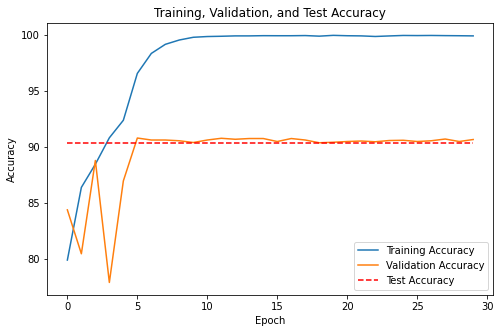

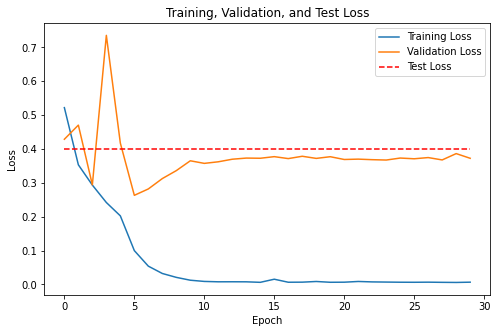

In [ ]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_L2, label='Training Accuracy')
plt.plot(validation_accuracy_L2, label='Validation Accuracy')
plt.plot(test_accuracies_plot_L2, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_L2, label='Training Loss')
plt.plot(validation_loss_L2, label='Validation Loss')
plt.plot(test_loss_plot_L2, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

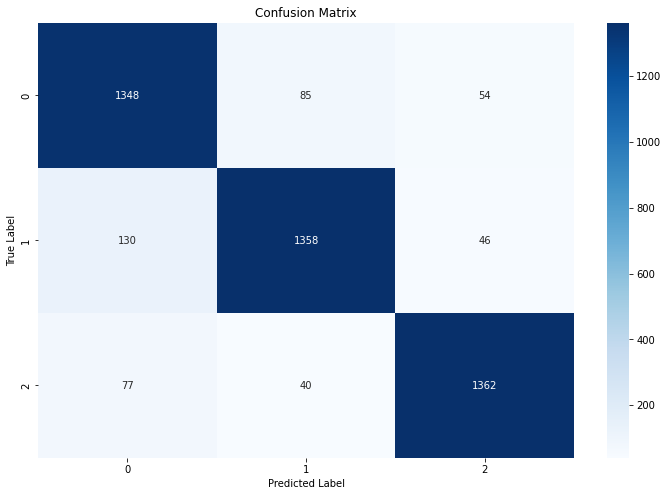

In [ ]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_L2, y_pred_L2)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

5. Evaluation and analysis.

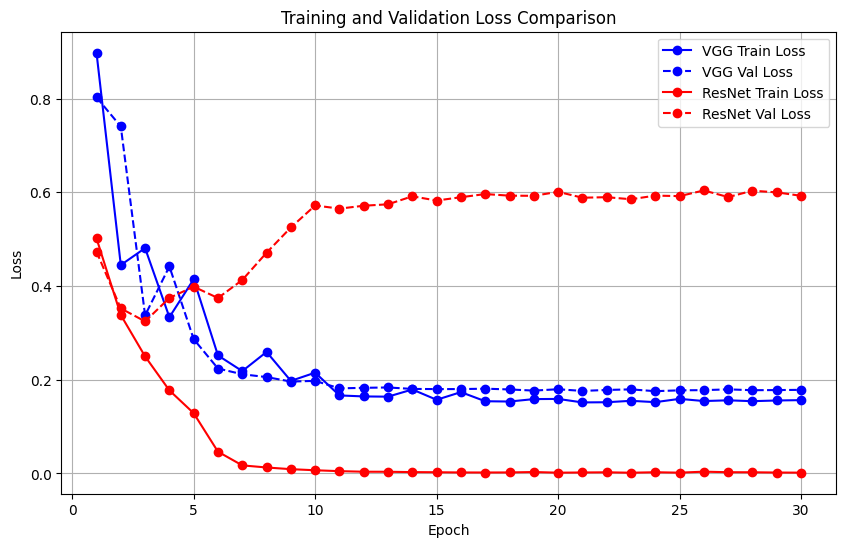

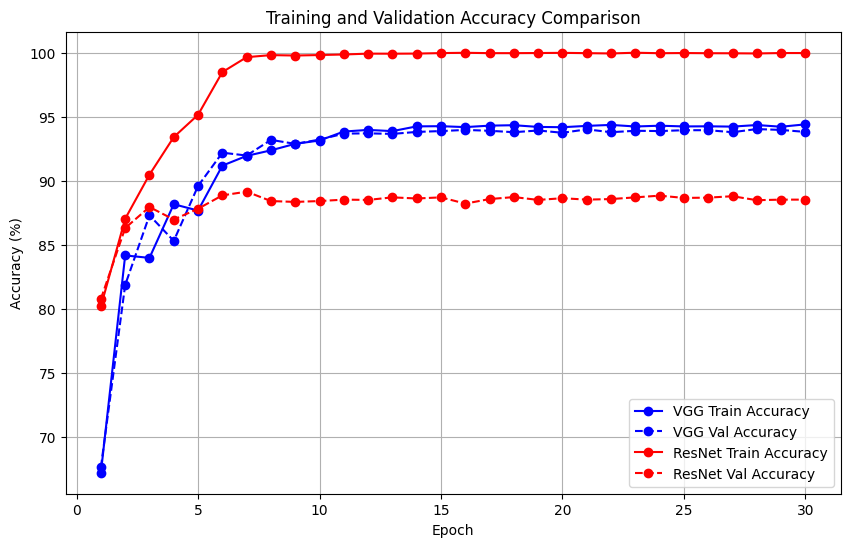

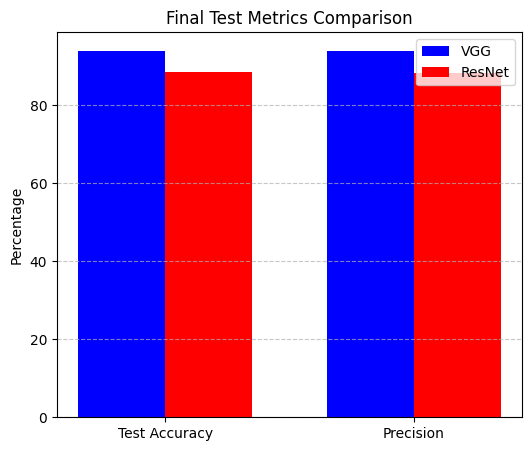

In [43]:
### ADD CODE HERE ###
import matplotlib.pyplot as plt
import numpy as np

# Define epochs
epochs = np.arange(1, 31)

# Plotting Loss Comparison
plt.figure(figsize=(10, 6))
# VGG curves in blue
plt.plot(epochs, train_loss_batch_norm, 'bo-', label="VGG Train Loss") 
plt.plot(epochs, validation_loss_batch_norm, 'b--o', label="VGG Val Loss")
# ResNet curves in red
plt.plot(epochs, train_loss_adam_resnet_xavier, 'ro-', label="ResNet Train Loss")
plt.plot(epochs, validation_loss_adam_resnet_xavier, 'r--o', label="ResNet Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy Comparison 
plt.figure(figsize=(10, 6))
# VGG curves in blue
plt.plot(epochs, train_accuracy_batch_norm, 'bo-', label="VGG Train Accuracy")
plt.plot(epochs, validation_accuracy_batch_norm, 'b--o', label="VGG Val Accuracy")
# ResNet curves in red
plt.plot(epochs, train_accuracy_adam_resnet_xavier, 'ro-', label="ResNet Train Accuracy")
plt.plot(epochs, validation_accuracy_adam_resnet_xavier, 'r--o', label="ResNet Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()


# Plotting Final Test Metrics 
# Convert precision to percentages for comparison.
vgg_precision, recall, f1, _ = precision_recall_fscore_support(y_true_batch_norm, y_pred_batch_norm, average='weighted')
resnet_precision, recall, f1, _ = precision_recall_fscore_support(y_true_adam_resnet_xavier, y_pred_adam_resnet_xavier, average='weighted')

metrics = ['Test Accuracy', 'Precision']
vgg_final =  [test_accuracy_batch_norm, vgg_precision * 100]
resnet_final = [test_accuracy_adam_resnet_xavier , resnet_precision * 100]

x = np.arange(len(metrics))
width = 0.35


plt.figure(figsize=(6, 5))
plt.bar(x - width/2, vgg_final, width, label='VGG', color='blue')
plt.bar(x + width/2, resnet_final, width, label='ResNet', color='red')
plt.xticks(x, metrics)
plt.ylabel("Percentage")
plt.title("Final Test Metrics Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


6. Save the weights of the trained network.

Done above for each model. Will upload the best one.

## Step 4: Discussion and conclusion

## <span style='color:#528aae'> 1. Explain the theoretical concepts behind VGG and ResNet. </span>

<span style='color:green'>### YOUR ANSWER ###</span>

### VGG
**Small Convolutional Filters**

In VGG we use multiple 3 x 3 convolutional filters instead of using larger ones. We can say that follwing are the results of this approach:
1. **Reducing Parameters:** Smaller filters use fewer parameters compared to larger filters 7x7, which helps in reducing the computational burden.(Since we use more filters as mentioned above this is helpful)
2. **Increasing Non-linearity:** Stacking several 3 x 3 layers introduces more non-linearities using the activation functions into the network, and this enables it to learn more complex features.
3. **Depth through Layer Stacking:** As mentioned above by stacking many of these small filters, VGG effectively increases the network’s depth. This gradual increase in the receptive field allows the network to capture intricate and abstract patterns in the data.

### ResNet
**Vanishing/Exploding Gradients in Deep Networks**

**Problem**

The problem of vanishing/exploding gradients in very deep networks is that as networks become very deep, gradients during backpropagation can become extremely small (which we call vanishing) or large (that is exploding), making training unstable or slow.

**How Residual Connections address this issue**
1. **Shortcut Paths:** ResNet introduces shortcut connections that allow the gradient to flow more directly from later layers back to the earlier ones. This removes the vanishing gradient problem.
2. **Learning Residuals:** Here, instead of learning a direct mapping H(x), the network learns a residual function F(x) = H(x) - x. This formulation makes it easier for the network to learn identity mappings when it is required.

**Identity Mapping**

**Concept:** The identity mapping is the operation where the input is directly passed to the output without any modification. In ResNet, if the residual function F(x) is zero, the output is just x (which we call an identity mapping).
By doing this we make sure that even if the additional layers don’t learn anything useful, they won’t harm our performance, and this allows the network to be very deep without degradation in training quality.


## <span style='color:#528aae'>2. Discuss the impact of regularization and optimization techniques.</span>

<span style='color:green'>### YOUR ANSWER ###</span>

### Optimizers
We have used three optimizers for this assignment with 'Xavier' and 'he' initialization for each
Xavier keeps the variance of activations consistent across layers whereas 'He' ensures proper variance propagation in deep networks.

1.**SGD (Stochastic Gradient Descent)**  
This one is a classic optimization method that updates parameters using gradients computed from mini-batches. It has the following properties:
_Sensitivity:_ as this requires careful tuning of the learning rate and momentum.  
_Behavior:_ it tends to converge slower than adaptive methods, but can yield robust results with proper scheduling.

**Initialization Impact:**

*Xavier/He:* With either Xavier  or He , SGD's convergence is stable and above 88 which is good but may need more epochs to reach higher performance. Both took similar train time per epoch averaging 17sec

Xavier![Xavier](SGD_X.png)  He![He](SGD_H.png)


2.**Adam (Adaptive Moment Estimation)**  
Adam is an adaptive optimizer that computes individual learning rates for different parameters based on estimates of first and second moments of gradients. This has following characteristics:  
*Adaptivity:* it often converges faster than SGD due to adaptive learning rate adjustments.  
*Sensitivity:* can be sensitive to its hyperparameters and may sometimes overfit if not regulated.(we got pitiful accuracy with xavier because of that)

**Initialization Impact:**  

*Xavier/He:* Works well with 'he' initializations; however, careful tuning is required to ensure stable convergence, especially as we can see with xavier we are getting around 32% which is very low. Training time wise Adam took 3 secs more on average than sgd but both accuracies remained below that of xavier.

Xavier ![Xavier](Adam_X.png) He![He](Adam_H.png)


3.**AdamW (Adam with Decoupled Weight Decay)**  
AdamW is a variant of Adam that decouples weight decay from the gradient update, leading to more effective regularization. It has foolowing characteristics:
*Regularization:* It better handles weight decay, which improves generalization in deep networks.  
*Performance:* it often provides faster convergence and improved performance over standard Adam, particularly in conjunction with normalization techniques like batch normalization.(Which gave us the best result later)

**Initialization Impact**

*Xavier/He:* With both initialization methods, AdamW leverages resulting in the best overall performance—especially notable with VGG-16 when paired with batch normalization. Training time was same as Adam but the accuracies was better

Xavier ![Xavier](AdamW_X.png)  He![He](AdamW_H.png)

Since AdamW with Xavier performed best, we tried it with batch 64 too but the accuracies dropped just a bit but training time also decreased to 4 sec less per epoch.

AdamW with Batch size 64![AdamW with Batch size 64](Adamw_with64batch.png)


**With Resnet**
*PS: Due to a post on Piazza we have implemented all the optimizers for Resnet too instead of just the best one.*
We Noticed that SGD suprisingly had the best results and Adam worked fine with both xavier and he, even though the accuracy lagged behind vgg.

Comparing Resnet with Adam and Xavier initialization performance with that of VGGs', its a bit lagging. But the training time was halved with a tradeoff of 3% accuracy, if time is an important figure Resnet would be a good option.

Resnet_Adam_Xavier![Resnet_Adam_Xavier](resnet_adam_xavier.png)

<span style='color:#1e3f66'> In our experiments, we applied three key techniques—early stopping, L2 regularization, and batch normalization—to both the VGG and ResNet models, and we observed notable impacts on performance:

1.**Early Stopping:**  
It was meant to help us prevent overfitting by halting training when the validation loss ceased to improve but since we only ran for 30 epochs as our base model so it still ran but further we go, it will help us. The Test accuracy was pretty close to validation one

Early Stopping metrics
![Early Stopping](early_stopping_vgg.png)

![early_Stoping_acc](early_stopping_acc.png)

2.**L2 Regularization:**  
By adding a penalty on the magnitude of weights, L2 regularization encourages simpler models that generalize better.
As we can see comparatively both tyest and val accuracies are higher and closer to that of train.

AdamW with L2 Regularization  
![Adam_L2](AdamW_L2.png)
![L2_acc](L2_acc.png)

3.**Batch Normalization:**  
This stabilized and accelerated training by normalizing layer inputs also this technique had the most significant positive impact. The training curves with batch normalization showed faster convergence and lower final loss values. Both models benefited, but the improvements were most pronounced in VGG when combined with Adam and Xavier initialization. The accuracy is the highest here.

AdamW with Batch Norm
![Adam_BatchNorm](adam_batch_norm.png)
![batch_acc.png](adam_batch_norm_acc.png)



***Overall Best Performing Configuration***  
**VGG with Adam Optimizer and Xavier Initialization (with Batch Normalization)**  
This configuration, particularly when combined with batch normalization, outperformed the others. Our metrics (e.g., accuracy and loss) and the plotted training/validation curves clearly indicate that this setup led to the best performance.

![Adam_BatchNorm](adam_batch_norm.png) 
![VGG_best_Loss](vgg_best_loss.png)

*Reason:* The synergy between the optimizer, initialization, and normalization techniques allowed the VGG model to learn more robust features while maintaining stable gradients throughout the training process.

In summary, while early stopping and L2 regularization provided valuable improvements in controlling overfitting and ensuring smoother learning, batch normalization emerged as the most impactful regularization technique. This was especially true for the VGG model with the Adam optimizer and Xavier initialization, which achieved superior results across our experimental metrics and plots. </span>

## <span style='color:#528aae'>3. Analyze the results, including all required graphs and metrics.</span>

<span style='color:green'>### YOUR ANSWER ###</span>

Based on our experimental analysis—supported by graphs of training/validation accuracy and loss, as well as metrics like peak accuracy and convergence speed—we observed that overall, *VGG-16 outperformed ResNet-18* under most optimization configurations. Here’s a detailed breakdown of our findings:

1.**Graph and Metric Overview**

**Training/Validation Loss Curves:**  

VGG-16 generally exhibited faster convergence and a lower final validation loss when using most optimization techniques with Adam combined with batch normalization and Xavier initialization.

VGG  ![VGG_best_Loss](VGG_best_Loss.png)

Resnet ![Resnet_best-loss](Resnet_best-loss.png)

**Accuracy Curves:**  

The accuracy plots showed that VGG-16 achieved higher and more stable validation accuracy compared to ResNet-18. In almost all cases (except a couple of configurations), VGG-16's performance was consistently superior.

VGG   ![VGG_best_accuracy](VGG_best_accuracy.png)

Resnet  ![Resnet_best_acc](Resnet_best_acc.png)

**Other Metrics:**  

Additional metrics, such as F1-score and precision/recall (if applicable), also confirmed that VGG-16 maintained a performance edge over ResNet-18.

VGG ![AdamW_BatchNorm](AdamW_BatchNorm.png)

Resnet ![Resnet_AdamW_Xavier](Resnet_AdamW_Xavier.png)


2.**Impact of Optimization Techniques**

**Effective Combinations:**  

When using optimizers like AdamW (with Xavier initialization) along with batch normalization, VGG-16 not only converged faster but also reached higher performance metrics. Batch normalization, in particular, had the best effect by stabilizing the training process.
VGG ![AdamW_BatchNorm](AdamW_BatchNorm.png)

**Underperforming Settings:**  

The notable exception was the configurations with Adam (with Xavier initialization), where VGG-16's performance dipped significantly sdue to factors like low value of weight decay that made it difficult to learn  and hence it did not perform as well.
VGG Adam & Xavier![Adam_X](Adam_X.png)

**ResNet-18 Observations:**  

While ResNet-18’s residual connections were intended to mitigate issues like vanishing gradients, our experiments indicated that these benefits did not translate into higher overall accuracy compared to VGG-16 under the tested conditions but halved the training time(if training time was main factor or atleat a very important one this tradeoff could have been an option)
Resnet with AdamW & Xavier![Resnet_AdamW_Xavier](Resnet_AdamW_Xavier.png)


3.**Why VGG-16 Performed Better:**

**Architectural Synergy with Optimizations**  

VGG-16’s simpler, straightforward architecture appears to have been more compatible with the optimizations we employed (especially AdamW and batch normalization). This synergy likely allowed for more effective feature extraction and generalization.

**Optimization Sensitivity**  

The slight complexity introduced by residual connections in ResNet-18 may require more fine-tuning or alternative hyperparameter settings to match VGG-16’s performance. In our tests, aside from the few suboptimal configurations (SGD with Xavier and Adam with Xavier), the other optimizers worked better on VGG-16.

**Generalization Performance**  

Across our experimental plots, VGG-16 not only achieved higher peak accuracy but also maintained more stable learning curves, indicating better generalization to the validation data.

**Conclusion:**  

Other than the specific cases of SGD with Xavier and Adam with Xavier (which particularly hurt VGG-16’s performance), all other optimization strategies favored VGG-16 over ResNet-18. The combination of AdamW with Xavier initialization and batch normalization proved to be the best configuration, allowing VGG-16 to achieve superior performance by ensuring fast convergence, low validation loss, and high accuracy. This suggests that, under our experimental conditions, VGG-16’s architecture was better suited to the task at hand compared to ResNet-18.

Below is a summary visualization of the key metrics from our experiments:

Compare the Loss 
![compare_loss](compare_loss.png)

Compare the Training and Validation Accuracy 
![compare_accuracy](compare_accuracy.png)

Compare the Test Accuracy 
![compare_test](compare_test.png)

This graph clearly illustrates the performance edge of VGG-16 over ResNet-18 in our tests.

## <span style='color:#528aae'>4. Summarize your findings and discuss the advantages of residual connections.</span>

<span style='color:green'>### YOUR ANSWER ###</span>

**Summary of Findings:**

1.**Key Differences:**  
**VGG-16:**  
*Architecture:* Utilizes a straightforward, sequential design with stacked 3 x 3 convolutional layers.
*Performance:* Demonstrated faster convergence, lower validation loss, and higher accuracy under most optimization configurations (especially with our best optimizer AdamW and batch normalization).
**ResNet-18:**  
*Architecture:* Incorporates residual connections that allow the network to learn residual mappings, which can mitigate vanishing gradients in deeper networks.
*Performance:* Although the residual connections are advantageous for training very deep networks, in our experiments the benefits did not translate into superior performance compared to VGG-16.

2.**Advantages of Residual Connections:**  
*Gradient Flow:* Residual connections facilitate smoother gradient flow by providing shortcut paths for backpropagation. This is particularly beneficial in extremely deep networks where vanishing gradients can be a major issue.
*Identity Mapping:* As we mentioned in the first question they enable the network to bypass certain layers if needed, effectively learning an identity function when additional transformation is unnecessary.
*Experimental Insight:* Despite these advantages, the residual architecture in ResNet-18 did not outperform VGG-16 in our setting—likely because the task and network depths did not fully leverage the potential of residual learning.

3.**Recommendation:**  
*Preferred Model:* **VGG-16**  
**Reason**  
1. Under the majority of configurations (with the exception of SGD with Xavier and Adam with Xavier), VGG-16 achieved better overall performance in terms of convergence speed, validation loss, and accuracy.
2. The combination of AdamW, Xavier initialization, and batch normalization synergized well with the VGG-16 architecture, leading to more robust learning and generalization.
3. Although ResNet-18’s residual connections are conceptually beneficial for very deep networks, in this particular task the simpler VGG-16 model provided superior results.

In conclusion, for this task, we recommend **VGG-16** is due to its consistent performance improvements and stable training behavior when paired with the effective optimization techniques applied in our experiments.

## <span style='color:#528aae'>5. References.</span>

<span style='color:green'>### YOUR ANSWER ###</span>

- Assignment 0 CSE564 ML: a0_part3_ra65
- Resnet Paper https://arxiv.org/pdf/1512.03385
- https://www.analyticsvidhya.com/blog/2021/06/build-resnet-from-scratch-with-python/

- https://www.geeksforgeeks.org/residual-networks-resnet-deep-learning/
- https://debuggercafe.com/implementing-resnet18-in-pytorch-from-scratch/
- https://www.geeksforgeeks.org/resnet18-from-scratch-using-pytorch/
- https://arxiv.org/pdf/1512.03385


- Vgg Paper: https://arxiv.org/pdf/1409.1556
- https://medium.com/@sajals1146/vgg-net-architecture-880df59c37ea
- https://www.kaggle.com/code/datastrophy/vgg16-pytorch-implementation#For-more-info-check-https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
-


Contribution:


| Team Member | Assignment Part | Contribution (%) |
|---|---|-------------|
| Himanshu Singh   | Part 1         | 50%                | 
| Rebecca Abraham  | Part 1         | 50%                |